In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **CLEAN DATA**

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print(" CONTRASTIVE LEARNING")
print("="*80)

def is_missing(value):
    if pd.isna(value):
        return True
    s = str(value).strip().lower()
    return s in ['--', '---', '', 'not reported', 'unknown', "'--", 'na', 'n/a', 'nan', 'none', 'sample9']

def clean_stage_label(stage_str):
    if is_missing(stage_str):
        return np.nan
    s = str(stage_str).upper().strip().replace('STAGE', '').replace('_', '').strip()
    if s in ['', 'X', 'NOT REPORTED'] or 'IV' in s or s.startswith('4') or s in ['0', '0A', '0IS', 'IS']:
        return np.nan
    if 'III' in s or s.startswith('3'):
        return 'Stage III'
    elif 'II' in s or s.startswith('2'):
        return 'Stage II'
    elif 'I' in s or s.startswith('1'):
        return 'Stage I'
    else:
        return np.nan

print("\n[STEP 1] Loading data...")

file_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Preprocess_Data_for_4_Experiments.csv'
df = pd.read_csv(file_path)

df['stage_clean'] = df['diagnoses.ajcc_pathologic_stage'].apply(clean_stage_label)
df_valid = df[df['stage_clean'].notna()].copy()

methylation_cols = [col for col in df_valid.columns if col.startswith('latent_')]
clinical_cols = [
    'demographic.gender', 'demographic.vital_status', 'samples.sample_type',
    'cases.disease_type', 'samples.tissue_type', 'diagnoses.primary_diagnosis',
    'diagnoses.tissue_or_organ_of_origin', 'diagnoses.morphology',
    'diagnoses.age_at_diagnosis', 'diagnoses.prior_treatment',
    'diagnoses.prior_malignancy', 'demographic.race', 'demographic.ethnicity'
]

keep_cols = ['stage_clean'] + methylation_cols + clinical_cols
df_subset = df_valid[keep_cols].copy()

# Remove duplicate columns
df_subset = df_subset.loc[:, ~df_subset.columns.duplicated()]

# Remove rows with missing value indicators (including sample9)
missing_indicators = ['--', '---', '', 'not reported', 'unknown', "'--",
                     'na', 'n/a', 'nan', 'none', 'Not Reported',
                     'Unknown', 'NA', 'N/A', 'NaN', 'sample9', 'Sample9']

keep_mask = pd.Series([True] * len(df_subset), index=df_subset.index)

for col in clinical_cols:
    if col in df_subset.columns:
        has_missing = df_subset[col].astype(str).isin(missing_indicators)
        keep_mask = keep_mask & ~has_missing

df_subset = df_subset[keep_mask]
df_clean = df_subset.dropna()

samples_before_filter = len(df_clean)

print(f"\n   Initial clean data: {df_clean.shape}")
print(f"   Stage I: {(df_clean['stage_clean']=='Stage I').sum()}")
print(f"   Stage II: {(df_clean['stage_clean']=='Stage II').sum()}")
print(f"   Stage III: {(df_clean['stage_clean']=='Stage III').sum()}")

# ============================================================================
# FILTER CANCER TYPES (BEFORE TRAINING)
# ============================================================================
print("\n" + "="*80)
print(" [STEP 1.5] FILTERING CANCER TYPES (≥10 samples)")
print("="*80)

cancer_type_col = 'diagnoses.tissue_or_organ_of_origin'
cancer_counts_before = df_clean[cancer_type_col].value_counts()

print(f"\n📊 BEFORE FILTERING:")
print(f"   Total samples: {len(df_clean)}")
print(f"   Unique cancer types: {len(cancer_counts_before)}")

# Find cancer types with >= 10 samples
valid_cancers = cancer_counts_before[cancer_counts_before >= 238].index.tolist()

print(f"\n   Cancer types with ≥10 samples: {len(valid_cancers)}")
print(f"   Cancer types with <10 samples (removing): {len(cancer_counts_before) - len(valid_cancers)}")

# Filter dataframe
df_filtered = df_clean[df_clean[cancer_type_col].isin(valid_cancers)].copy()

# Calculate removed samples
removed_sample_count = len(df_clean) - len(df_filtered)

# Show removed cancer types
removed_cancers = cancer_counts_before[cancer_counts_before < 310].sort_values(ascending=False)
if len(removed_cancers) > 0:
    print(f"\n   ❌ REMOVED CANCER TYPES (n={len(removed_cancers)}):")
    print("   " + "-" * 70)
    for cancer, count in removed_cancers.items():
        print(f"      {cancer:<55} {count:>3} samples")

# Show kept cancer types
kept_cancers = cancer_counts_before[cancer_counts_before >=238].sort_values(ascending=False)
print(f"\n   ✅ KEPT CANCER TYPES (n={len(kept_cancers)}):")
print("   " + "-" * 70)
for cancer, count in kept_cancers.items():
    print(f"      {cancer:<55} {count:>3} samples")

# Use filtered dataframe
df_clean = df_filtered

print(f"\n📊 AFTER FILTERING:")
print(f"   Total samples: {len(df_clean)} (removed {removed_sample_count})")
print(f"   Unique cancer types: {len(np.unique(df_clean[cancer_type_col]))}")
print(f"   Dataset shape: {df_clean.shape}")
print(f"\n   Stage distribution:")
print(f"      Stage I:   {(df_clean['stage_clean']=='Stage I').sum()} ({(df_clean['stage_clean']=='Stage I').sum()/len(df_clean)*100:.1f}%)")
print(f"      Stage II:  {(df_clean['stage_clean']=='Stage II').sum()} ({(df_clean['stage_clean']=='Stage II').sum()/len(df_clean)*100:.1f}%)")
print(f"      Stage III: {(df_clean['stage_clean']=='Stage III').sum()} ({(df_clean['stage_clean']=='Stage III').sum()/len(df_clean)*100:.1f}%)")

print("\n" + "="*80)



 CONTRASTIVE LEARNING

[STEP 1] Loading data...

   Initial clean data: (2625, 164)
   Stage I: 930
   Stage II: 978
   Stage III: 717

 [STEP 1.5] FILTERING CANCER TYPES (≥10 samples)

📊 BEFORE FILTERING:
   Total samples: 2625
   Unique cancer types: 66

   Cancer types with ≥10 samples: 4
   Cancer types with <10 samples (removing): 62

   ❌ REMOVED CANCER TYPES (n=65):
   ----------------------------------------------------------------------
      Thyroid gland                                           309 samples
      Kidney, NOS                                             284 samples
      Upper lobe, lung                                        239 samples
      Liver                                                   148 samples
      Lower lobe, lung                                        134 samples
      Head of pancreas                                         77 samples
      Testis, NOS                                              67 samples
      Bladder, NOS              

In [4]:
print(f"'methylation_sample_id' column is not in df_clean. Its columns are: {df_clean.columns.tolist()}")
print(f"However, 'sample9' was previously removed from the initial DataFrame.")
print(f"Current df_clean shape: {df_clean.shape}")

output_file_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data.csv'
df_clean.to_csv(output_file_path, index=False)
print(f"\nFinal cleaned data saved to: {output_file_path}")

'methylation_sample_id' column is not in df_clean. Its columns are: ['stage_clean', 'latent_1', 'latent_2', 'latent_3', 'latent_4', 'latent_5', 'latent_6', 'latent_7', 'latent_8', 'latent_9', 'latent_10', 'latent_11', 'latent_12', 'latent_13', 'latent_14', 'latent_15', 'latent_16', 'latent_17', 'latent_18', 'latent_19', 'latent_20', 'latent_21', 'latent_22', 'latent_23', 'latent_24', 'latent_25', 'latent_26', 'latent_27', 'latent_28', 'latent_29', 'latent_30', 'latent_31', 'latent_32', 'latent_33', 'latent_34', 'latent_35', 'latent_36', 'latent_37', 'latent_38', 'latent_39', 'latent_40', 'latent_41', 'latent_42', 'latent_43', 'latent_44', 'latent_45', 'latent_46', 'latent_47', 'latent_48', 'latent_49', 'latent_50', 'latent_51', 'latent_52', 'latent_53', 'latent_54', 'latent_55', 'latent_56', 'latent_57', 'latent_58', 'latent_59', 'latent_60', 'latent_61', 'latent_62', 'latent_63', 'latent_64', 'latent_65', 'latent_66', 'latent_67', 'latent_68', 'latent_69', 'latent_70', 'latent_71', 'l

In [5]:
import pandas as pd

# Assuming 'df' from the initial loading is still available in the kernel
# If not, it needs to be reloaded to get 'methylation_sample_id'
# For robustness, we'll try to get it from the original df by index.

if 'methylation_sample_id' not in df_clean.columns:
    try:
        # Ensure 'df' from initial data loading is present in the kernel
        # If not, reload it to get the methylation_sample_id
        if 'df' not in locals() or df is None:
            file_path_original = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Preprocess_Data_for_4_Experiments.csv'
            df = pd.read_csv(file_path_original)

        # Retrieve methylation_sample_id using the index of the clean DataFrame
        df_clean.loc[:, 'methylation_sample_id'] = df.loc[df_clean.index, 'methylation_sample_id']
        print("Added 'methylation_sample_id' to df_clean.")
    except Exception as e:
        print(f"Could not add 'methylation_sample_id' to df_clean: {e}")
        print("Please ensure the original 'df' DataFrame (from '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Preprocess_Data_for_4_Experiments.csv') is loaded and contains the 'methylation_sample_id' column.")
else:
    print(" 'methylation_sample_id' column already exists in df_clean.")

print(f"Current df_clean shape: {df_clean.shape}")

output_file_path_with_id = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data_with_MethylationID.csv'
df_clean.to_csv(output_file_path_with_id, index=False)
print(f"\nFinal cleaned data with methylation_sample_id saved to: {output_file_path_with_id}")

Added 'methylation_sample_id' to df_clean.
Current df_clean shape: (1343, 165)

Final cleaned data with methylation_sample_id saved to: /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data_with_MethylationID.csv


# **CHECK SIMILARITY**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

print(" COMPREHENSIVE DATA ANALYSIS")
print("\nGoal: 3-Stage Cancer Classification (Stage I, II, III)")
print("Data: DNA Methylation (VAE latent) + Clinical Features")
print("\n[STEP 1] Loading data...")

file_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data.csv'
df = pd.read_csv(file_path)

print(f"\n Data loaded successfully!")
print(f"   Total rows: {df.shape[0]:,}")
print(f"   Total columns: {df.shape[1]:,}")
def is_missing(value):
    if pd.isna(value):
        return True
    s = str(value).strip().lower()
    return s in ['--', '---', '', 'not reported', 'unknown', 'na', 'n/a', 'nan', 'none', "'--", "'--"]

def clean_stage_label(stage_str):
    if is_missing(stage_str):
        return np.nan
    s = str(stage_str).upper().strip().replace('STAGE', '').replace('_', '').strip()
    if s in ['', 'X', 'NOT REPORTED'] or 'IV' in s or s.startswith('4') or s in ['0', '0A', '0IS', 'IS']:
        return np.nan
    if 'III' in s or s.startswith('3'):
        return 'Stage III'
    elif 'II' in s or s.startswith('2'):
        return 'Stage II'
    elif 'I' in s or s.startswith('1'):
        return 'Stage I'
    else:
        return np.nan


print("\n[STEP 2] Identifying features...")

methylation_cols = [col for col in df.columns if col.startswith('latent_')]

clinical_cols = [
    'demographic.gender', 'demographic.vital_status', 'samples.sample_type',
    'cases.disease_type', 'samples.tissue_type', 'diagnoses.primary_diagnosis',
    'diagnoses.tissue_or_organ_of_origin', 'diagnoses.morphology',
    'diagnoses.age_at_diagnosis', 'diagnoses.prior_treatment',
    'diagnoses.prior_malignancy', 'demographic.race', 'demographic.ethnicity'
]

target_col = 'stage_clean'

print(f"\n Feature Summary:")
print(f"   Methylation features (VAE latent): {len(methylation_cols)}")
print(f"   Clinical features: {len(clinical_cols)}")
print(f"   Target variable: {target_col}")


print("\n[STEP 3] Cleaning data...")

df_valid = df[df['stage_clean'].notna()].copy()

print(f"\n Stage Distribution (AFTER cleaning):")
print(df_valid['stage_clean'].value_counts())

keep_cols = ['stage_clean'] + methylation_cols + clinical_cols
df_subset = df_valid[keep_cols].copy()

for col in clinical_cols:
    if col in df_subset.columns:
        df_subset[col] = df_subset[col].apply(lambda x: np.nan if is_missing(x) else x)

missing_counts = df_subset.isnull().sum()
print(f"\n Missing Values:")
for col in missing_counts[missing_counts > 0].index:
    pct = (missing_counts[col] / len(df_subset)) * 100
    print(f"   {col}: {missing_counts[col]} ({pct:.1f}%)")

df_clean = df_subset.dropna()

print(f"\n Clean dataset:")
print(f"   Rows after cleaning: {len(df_clean)} (from {len(df_subset)})")
print(f"   Rows dropped: {len(df_subset) - len(df_clean)} ({(1 - len(df_clean)/len(df_subset))*100:.1f}%)")

print(" CANCER TYPE DISTRIBUTION (diagnoses.tissue_or_organ_of_origin)")


 COMPREHENSIVE DATA ANALYSIS

Goal: 3-Stage Cancer Classification (Stage I, II, III)
Data: DNA Methylation (VAE latent) + Clinical Features

[STEP 1] Loading data...

 Data loaded successfully!
   Total rows: 1,343
   Total columns: 164

[STEP 2] Identifying features...

 Feature Summary:
   Methylation features (VAE latent): 150
   Clinical features: 13
   Target variable: stage_clean

[STEP 3] Cleaning data...

 Stage Distribution (AFTER cleaning):
stage_clean
Stage I      610
Stage II     426
Stage III    307
Name: count, dtype: int64

 Missing Values:

 Clean dataset:
   Rows after cleaning: 1343 (from 1343)
   Rows dropped: 0 (0.0%)
 CANCER TYPE DISTRIBUTION (diagnoses.tissue_or_organ_of_origin)


In [7]:
print(" FINAL DATASET SUMMARY")

print(f"\n Dataset Size:")
print(f"   Total samples: {len(df_clean)}")
print(f"   Total features: {len(methylation_cols) + len(clinical_cols)}")
print(f"   Methylation (VAE latent): {len(methylation_cols)}")
print(f"   Clinical: {len(clinical_cols)}")

print(f"\n Target Distribution:")
stage_counts = df_clean['stage_clean'].value_counts().sort_index()
for stage, count in stage_counts.items():
    pct = (count / len(df_clean)) * 100
    print(f"   {stage}: {count} samples ({pct:.1f}%)")

max_class = stage_counts.max()
min_class = stage_counts.min()
imbalance_ratio = max_class / min_class

print(f"\n Class Imbalance:")
print(f"   Largest class: {max_class}")
print(f"   Smallest class: {min_class}")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2.0:
    print(f"    WARNING: Significant class imbalance detected!")
else:
    print(f"    Classes are relatively balanced")

 FINAL DATASET SUMMARY

 Dataset Size:
   Total samples: 1343
   Total features: 163
   Methylation (VAE latent): 150
   Clinical: 13

 Target Distribution:
   Stage I: 610 samples (45.4%)
   Stage II: 426 samples (31.7%)
   Stage III: 307 samples (22.9%)

 Class Imbalance:
   Largest class: 610
   Smallest class: 307
   Imbalance ratio: 1.99:1
    Classes are relatively balanced


In [8]:
print(" PROBLEM IDENTIFICATION")

stage_encoder = LabelEncoder()
y = stage_encoder.fit_transform(df_clean['stage_clean'])

X_methylation = df_clean[methylation_cols].values.astype(np.float32)
X_clinical_raw = df_clean[clinical_cols].copy()

X_clinical_encoded = []
for col in clinical_cols:
    le = LabelEncoder()
    encoded = le.fit_transform(X_clinical_raw[col].astype(str))
    X_clinical_encoded.append(encoded.reshape(-1, 1))
X_clinical = np.hstack(X_clinical_encoded).astype(np.float32)

X_combined = np.hstack([X_methylation, X_clinical])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print(f"\n Feature Statistics:")
print(f"   Combined features: {X_scaled.shape[1]}")
print(f"   Mean: {X_scaled.mean():.4f}")
print(f"   Std: {X_scaled.std():.4f}")
print(f"   Min: {X_scaled.min():.4f}")
print(f"   Max: {X_scaled.max():.4f}")


 PROBLEM IDENTIFICATION

 Feature Statistics:
   Combined features: 163
   Mean: 0.0000
   Std: 1.0000
   Min: -4.8801
   Max: 12.1747


In [9]:
print(f"\n PROBLEM 1: Class Separability")

stage_centers = []
for stage_id in range(3):
    mask = (y == stage_id)
    center = X_scaled[mask].mean(axis=0)
    stage_centers.append(center)

similarities = []
stage_names = ['I', 'II', 'III']
print(f"\n   Pairwise Cosine Similarity:")
for i in range(3):
    for j in range(i+1, 3):
        sim = cosine_similarity(
            stage_centers[i].reshape(1, -1),
            stage_centers[j].reshape(1, -1)
        )[0, 0]
        similarities.append(sim)
        print(f"   Stage {stage_names[i]} vs {stage_names[j]}: {sim*100:.1f}% similar")

avg_similarity = np.mean(similarities)
if avg_similarity > 0.5:
    print(f"\n    CRITICAL: Average similarity {avg_similarity*100:.1f}% (Too high!)")
    print(f"   → Classes are NOT well separated")
    print(f"   → Expected accuracy ceiling: ~{(1-avg_similarity)*100:.0f}%")
else:
    print(f"\n    Average similarity {avg_similarity*100:.1f}% (Good!)")


print(f"\n PROBLEM 2: Feature Information Content")

pca = PCA()
pca.fit(X_scaled)

cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cumsum_variance >= 0.80) + 1
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1

print(f"\n   Variance Analysis:")
print(f"   Components for 80% variance: {n_components_80}/{X_scaled.shape[1]}")
print(f"   Components for 95% variance: {n_components_95}/{X_scaled.shape[1]}")

if n_components_80 < 20:
    print(f"\n    WARNING: Only {n_components_80} components needed for 80% variance")
    print(f"   → Many features are redundant/noisy")
else:
    print(f"\n   Features are well distributed")

print(f"\n PROBLEM 3: Stage II-III Discrimination (Critical!)")

stage2_mask = (y == 1)
stage3_mask = (y == 2)

X_stage2 = X_scaled[stage2_mask]
X_stage3 = X_scaled[stage3_mask]

from sklearn.metrics.pairwise import cosine_distances

sample_size = min(100, len(X_stage2), len(X_stage3))
idx2 = np.random.choice(len(X_stage2), sample_size, replace=False)
idx3 = np.random.choice(len(X_stage3), sample_size, replace=False)

pairwise_distances = cosine_distances(X_stage2[idx2], X_stage3[idx3])
avg_distance = pairwise_distances.mean()
avg_similarity_23 = 1 - avg_distance

print(f"\n   Stage II vs III Analysis:")
print(f"   Average pairwise similarity: {avg_similarity_23*100:.1f}%")
print(f"   Overlap percentage: ~{avg_similarity_23*100:.0f}%")

if avg_similarity_23 > 0.6:
    print(f"\n    CRITICAL PROBLEM!")
    print(f"   → Stage II and III are {avg_similarity_23*100:.0f}% similar")
    print(f"   → Very difficult to separate")
    print(f"   → This is the MAIN bottleneck!")
else:
    print(f"\n    Stages are separable")

print(f"\n PROBLEM 4: VAE Compression Loss")

print(f"\n   Original CpG sites: 450,000")
print(f"   VAE latent features: {len(methylation_cols)}")
print(f"   Compression ratio: {450000/len(methylation_cols):.0f}:1")
print(f"   Information retained: {(len(methylation_cols)/450000)*100:.4f}%")
print(f"\n    99.97% of original methylation data was discarded!")
print(f"   Stage-specific biomarkers likely lost")




 PROBLEM 1: Class Separability

   Pairwise Cosine Similarity:
   Stage I vs II: -99.9% similar
   Stage I vs III: 50.3% similar
   Stage II vs III: -54.6% similar

    Average similarity -34.7% (Good!)

 PROBLEM 2: Feature Information Content

   Variance Analysis:
   Components for 80% variance: 1/163
   Components for 95% variance: 3/163

   → Many features are redundant/noisy

 PROBLEM 3: Stage II-III Discrimination (Critical!)

   Stage II vs III Analysis:
   Average pairwise similarity: 0.6%
   Overlap percentage: ~1%

    Stages are separable

 PROBLEM 4: VAE Compression Loss

   Original CpG sites: 450,000
   VAE latent features: 150
   Compression ratio: 3000:1
   Information retained: 0.0333%

    99.97% of original methylation data was discarded!
   Stage-specific biomarkers likely lost



[STEP 6] Creating visualizations...


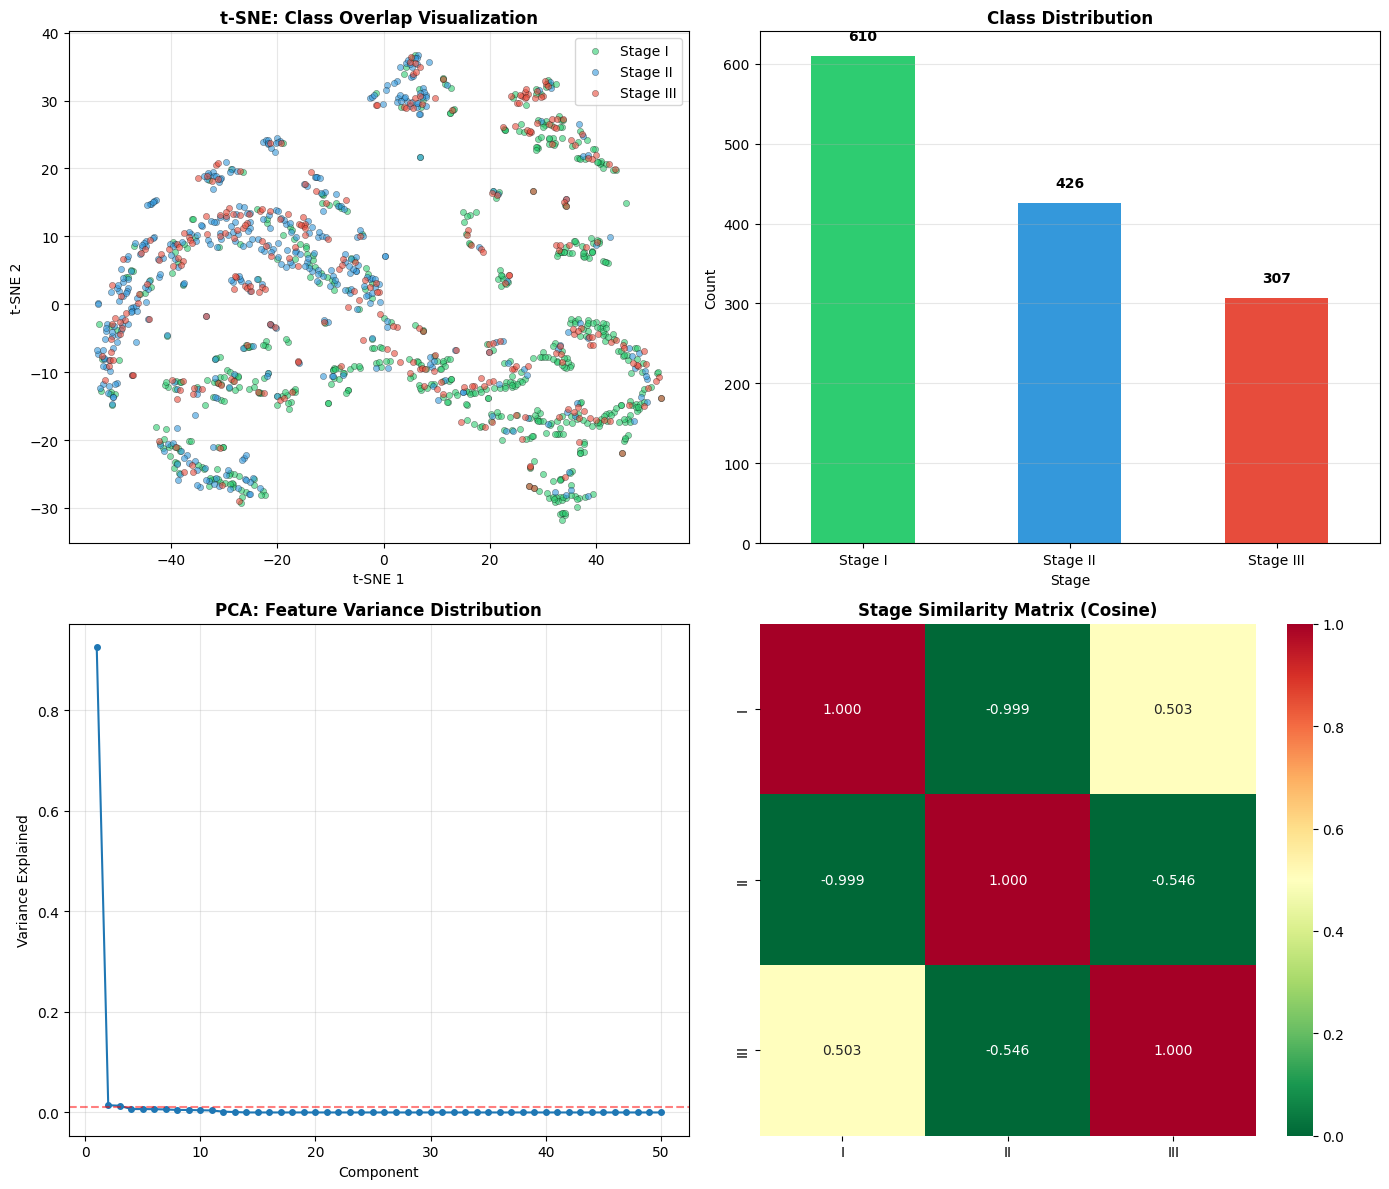

 Data analysis complete!
   Clean dataset ready: 1343 samples
   Features ready: 163


In [10]:
print(f"\n[STEP 6] Creating visualizations...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
colors = ['#2ecc71', '#3498db', '#e74c3c']
for stage_id, (stage_name, color) in enumerate(zip(['Stage I', 'Stage II', 'Stage III'], colors)):
    mask = (y == stage_id)
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
              c=color, label=stage_name, alpha=0.6, s=20, edgecolors='black', linewidths=0.3)
ax.set_title('t-SNE: Class Overlap Visualization', fontweight='bold', fontsize=12)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
stage_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#3498db', '#e74c3c'])
ax.set_title('Class Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Stage')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(stage_counts):
    ax.text(i, v + 20, str(v), ha='center', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.plot(range(1, 51), pca.explained_variance_ratio_[:50], marker='o', markersize=4)
ax.axhline(y=0.01, color='r', linestyle='--', alpha=0.5)
ax.set_title('PCA: Feature Variance Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Component')
ax.set_ylabel('Variance Explained')
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
similarity_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        if i == j:
            similarity_matrix[i, j] = 1.0
        else:
            similarity_matrix[i, j] = cosine_similarity(
                stage_centers[i].reshape(1, -1),
                stage_centers[j].reshape(1, -1)
            )[0, 0]

sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax, vmin=0, vmax=1)
ax.set_title('Stage Similarity Matrix (Cosine)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/data_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()


print(" Data analysis complete!")
print(f"   Clean dataset ready: {len(df_clean)} samples")
print(f"   Features ready: {X_scaled.shape[1]}")


# **CONTRASTIVE LEARNING**

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("CONTRASTIVE LEARNING - DriftNet (Improved)")

SAVE_DIR = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning'
os.makedirs(SAVE_DIR, exist_ok=True)

# ==================== HELPER ====================
def is_missing(value):
    if isinstance(value, pd.Series):
        return value.apply(lambda x: is_missing(x)).any()
    if pd.isna(value):
        return True
    s = str(value).strip().lower()
    return s in ['--', '---', '', 'not reported', 'unknown', "'--", 'na', 'n/a', 'nan', 'none']

# ==================== STEP 1: LOAD DATA ====================
print("\n[STEP 1] Loading data...")
file_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data.csv'
df = pd.read_csv(file_path)
df_valid = df[df['stage_clean'].notna()].copy()

methylation_cols = [col for col in df_valid.columns if col.startswith('latent_')]
clinical_cols = [
    'demographic.gender', 'demographic.vital_status', 'samples.sample_type',
    'cases.disease_type', 'samples.tissue_type', 'diagnoses.primary_diagnosis',
    'diagnoses.tissue_or_organ_of_origin', 'diagnoses.morphology',
    'diagnoses.age_at_diagnosis', 'diagnoses.prior_treatment',
    'diagnoses.prior_malignancy', 'demographic.race', 'demographic.ethnicity'
]

keep_cols = ['stage_clean'] + methylation_cols + clinical_cols
df_subset = df_valid[keep_cols].copy()
for col in clinical_cols:
    if col in df_subset.columns:
        df_subset[col] = df_subset[col].apply(lambda x: np.nan if is_missing(x) else x)
df_clean = df_subset.dropna()

print(f"   Clean data : {df_clean.shape}")
print(f"   Stage I    : {(df_clean['stage_clean']=='Stage I').sum()}")
print(f"   Stage II   : {(df_clean['stage_clean']=='Stage II').sum()}")
print(f"   Stage III  : {(df_clean['stage_clean']=='Stage III').sum()}")

# ==================== STEP 2: ENCODE FEATURES ====================
print("\n[STEP 2] Preparing features...")
stage_encoder = LabelEncoder()
y = stage_encoder.fit_transform(df_clean['stage_clean'])
joblib.dump(stage_encoder, f'{SAVE_DIR}/stage_encoder.pkl')
print(f"   Stage classes: {stage_encoder.classes_}")

X_methylation = df_clean[methylation_cols].values.astype(np.float32)

X_clinical_list = []
clinical_label_encoders = {}
for col in clinical_cols:
    if col == 'diagnoses.age_at_diagnosis':
        encoded = df_clean[col].astype(float).values
        X_clinical_list.append(encoded.reshape(-1, 1))
    else:
        le = LabelEncoder()
        encoded = le.fit_transform(df_clean[col].astype(str))
        clinical_label_encoders[col] = le
        X_clinical_list.append(encoded.reshape(-1, 1))

X_clinical = np.hstack(X_clinical_list).astype(np.float32)
joblib.dump(clinical_label_encoders, f'{SAVE_DIR}/clinical_label_encoders.pkl')

X_combined = np.hstack([X_methylation, X_clinical])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined).astype(np.float32)
joblib.dump(scaler, f'{SAVE_DIR}/contrastive_scaler.pkl')

print(f"   Total features : {X_scaled.shape[1]}")
print(f"   Total samples  : {len(y)}")
print(f"   Saved: stage_encoder, clinical_label_encoders, contrastive_scaler")

# ==================== STEP 3: GENERATE TRIPLETS ====================
def generate_triplets(X, y, num_triplets=50000):
    triplets   = []
    labels     = []
    stage2_idx = np.where(y == 1)[0]
    stage3_idx = np.where(y == 2)[0]

    for _ in range(num_triplets):
        anchor_idx   = np.random.randint(len(X))
        anchor_class = y[anchor_idx]
        same_class   = np.where(y == anchor_class)[0]
        if len(same_class) < 2:
            continue
        positive_idx = np.random.choice(same_class)

        # 80% of Stage III anchors fight Stage II (hardest boundary)
        if anchor_class == 2 and len(stage2_idx) > 0 and np.random.rand() < 0.8:
            negative_idx = np.random.choice(stage2_idx)
        # 50% of Stage II anchors fight Stage III
        elif anchor_class == 1 and len(stage3_idx) > 0 and np.random.rand() < 0.5:
            negative_idx = np.random.choice(stage3_idx)
        else:
            diff_class = np.where(y != anchor_class)[0]
            if len(diff_class) == 0:
                continue
            negative_idx = np.random.choice(diff_class)

        triplets.append([X[anchor_idx], X[positive_idx], X[negative_idx]])
        labels.append(anchor_class)

    return np.array(triplets), np.array(labels)

print("\n[STEP 3] Generating triplets (Stage III focused, 50k)...")
triplets, triplet_labels = generate_triplets(X_scaled, y, num_triplets=50000)
print(f"   Generated {len(triplets)} triplets")

# ==================== STEP 4: BUILD MODEL ====================
def build_contrastive_encoder(input_dim, embedding_dim=128):
    return keras.Sequential([
        layers.Input(shape=(input_dim,),                         name="input_layer"),
        layers.Dense(512, activation="relu",                     name="dense"),
        layers.BatchNormalization(momentum=0.99, epsilon=0.001,  name="batch_normalization"),
        layers.Dropout(0.4,                                      name="dropout"),
        layers.Dense(256, activation="relu",                     name="dense_1"),
        layers.BatchNormalization(momentum=0.99, epsilon=0.001,  name="batch_normalization_1"),
        layers.Dropout(0.3,                                      name="dropout_1"),
        layers.Dense(embedding_dim, activation=None,             name="dense_2"),
        layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1),  name="l2_normalize"),
    ], name="Contrastive_Encoder")

def triplet_loss(margin=2.0):
    def loss_fn(y_true, y_pred):
        anchor   = y_pred[:, 0, :]
        positive = y_pred[:, 1, :]
        negative = y_pred[:, 2, :]
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
        loss = tf.maximum(pos_dist - neg_dist + margin, 0.0)
        return tf.reduce_mean(loss)
    return loss_fn

def build_siamese_network(input_dim, embedding_dim=128):
    encoder        = build_contrastive_encoder(input_dim, embedding_dim)
    anchor_input   = keras.Input(shape=(input_dim,), name='anchor')
    positive_input = keras.Input(shape=(input_dim,), name='positive')
    negative_input = keras.Input(shape=(input_dim,), name='negative')
    anchor_emb     = encoder(anchor_input)
    positive_emb   = encoder(positive_input)
    negative_emb   = encoder(negative_input)
    embeddings     = layers.Lambda(lambda x: tf.stack(x, axis=1))(
        [anchor_emb, positive_emb, negative_emb]
    )
    model = keras.Model(
        inputs=[anchor_input, positive_input, negative_input],
        outputs=embeddings
    )
    return model, encoder

print("\n[STEP 4] Building contrastive network...")
siamese_model, feature_encoder = build_siamese_network(X_scaled.shape[1], embedding_dim=128)
siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00005),
    loss=triplet_loss(margin=2.0)
)
print(f"   Model: {siamese_model.count_params():,} parameters")

# ==================== STEP 5: TRAIN ====================
print("\n[STEP 5] Training contrastive encoder...")
X_anchors   = triplets[:, 0, :]
X_positives = triplets[:, 1, :]
X_negatives = triplets[:, 2, :]
y_dummy     = np.zeros((len(triplets), 3, 128))

history = siamese_model.fit(
    [X_anchors, X_positives, X_negatives],
    y_dummy,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=30,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=15, min_lr=1e-8
        )
    ],
    verbose=2
)
print("Contrastive training complete!")

# ==================== STEP 6: EXTRACT FEATURES ====================
print("\n[STEP 6] Extracting contrastive features...")
X_contrastive = feature_encoder.predict(X_scaled, verbose=0)
print(f"   Original    : {X_scaled.shape}")
print(f"   Contrastive : {X_contrastive.shape}")

# ==================== STEP 7: MEASURE IMPROVEMENTS ====================
print("\n[STEP 7] Measuring improvements...")
stage2_mask = (y == 1)
stage3_mask = (y == 2)

old_sim = abs(cosine_similarity(
    X_scaled[stage2_mask].mean(axis=0).reshape(1,-1),
    X_scaled[stage3_mask].mean(axis=0).reshape(1,-1)
)[0,0])
new_sim = abs(cosine_similarity(
    X_contrastive[stage2_mask].mean(axis=0).reshape(1,-1),
    X_contrastive[stage3_mask].mean(axis=0).reshape(1,-1)
)[0,0])

old_silhouette = silhouette_score(X_scaled, y)
new_silhouette = silhouette_score(X_contrastive, y)
old_calinski   = calinski_harabasz_score(X_scaled, y)
new_calinski   = calinski_harabasz_score(X_contrastive, y)
old_davies     = davies_bouldin_score(X_scaled, y)
new_davies     = davies_bouldin_score(X_contrastive, y)

lda_old = LinearDiscriminantAnalysis()
lda_old.fit(X_scaled[y > 0], y[y > 0])
lda_old_score = lda_old.score(X_scaled[y > 0], y[y > 0])
lda_new = LinearDiscriminantAnalysis()
lda_new.fit(X_contrastive[y > 0], y[y > 0])
lda_new_score = lda_new.score(X_contrastive[y > 0], y[y > 0])

print("\n===== CONTRASTIVE LEARNING RESULTS =====")
print(f"Stage II-III Similarity : {old_sim:.4f} -> {new_sim:.4f}  (lower is better)")
print(f"Silhouette Score        : {old_silhouette:.4f} -> {new_silhouette:.4f}  (higher is better)")
print(f"Davies-Bouldin Index    : {old_davies:.4f} -> {new_davies:.4f}  (lower is better)")
print(f"Calinski-Harabasz Score : {old_calinski:.1f} -> {new_calinski:.1f}  ({new_calinski/old_calinski:.1f}x better)")
print(f"LDA Score (II vs III)   : {lda_old_score:.4f} -> {lda_new_score:.4f}  ({(lda_new_score-lda_old_score)*100:+.1f}%)")

# ==================== STEP 8: SAVE ====================
print("\n[STEP 8] Saving all files...")
np.save(f'{SAVE_DIR}/X_contrastive.npy', X_contrastive)
np.save(f'{SAVE_DIR}/X_scaled.npy',      X_scaled)
np.save(f'{SAVE_DIR}/X_clinical.npy',    X_clinical)
np.save(f'{SAVE_DIR}/y.npy',             y)
feature_encoder.save(f'{SAVE_DIR}/contrastive_encoder.keras')

print("   Saved: X_contrastive.npy")
print("   Saved: X_scaled.npy")
print("   Saved: X_clinical.npy")
print("   Saved: y.npy")
print("   Saved: contrastive_encoder.keras")
print("   Saved: stage_encoder.pkl")
print("   Saved: clinical_label_encoders.pkl")
print("   Saved: contrastive_scaler.pkl")
print("\nDone! Ready for DriftNet training.")


CONTRASTIVE LEARNING - DriftNet (Improved)

[STEP 1] Loading data...
   Clean data : (1343, 164)
   Stage I    : 610
   Stage II   : 426
   Stage III  : 307

[STEP 2] Preparing features...
   Stage classes: ['Stage I' 'Stage II' 'Stage III']
   Total features : 163
   Total samples  : 1343
   Saved: stage_encoder, clinical_label_encoders, contrastive_scaler

[STEP 3] Generating triplets (Stage III focused, 50k)...
   Generated 50000 triplets

[STEP 4] Building contrastive network...
   Model: 251,264 parameters

[STEP 5] Training contrastive encoder...
Epoch 1/200
625/625 - 18s - 28ms/step - loss: 1.7374 - val_loss: 1.7395 - learning_rate: 5.0000e-05
Epoch 2/200
625/625 - 2s - 4ms/step - loss: 1.6588 - val_loss: 1.7546 - learning_rate: 5.0000e-05
Epoch 3/200
625/625 - 3s - 5ms/step - loss: 1.6439 - val_loss: 1.7347 - learning_rate: 5.0000e-05
Epoch 4/200
625/625 - 3s - 5ms/step - loss: 1.6399 - val_loss: 1.7292 - learning_rate: 5.0000e-05
Epoch 5/200
625/625 - 2s - 3ms/step - loss: 1.6

 Creating AFTER Contrastive Learning Visualization (Same Style as BEFORE)
   Computing t-SNE...


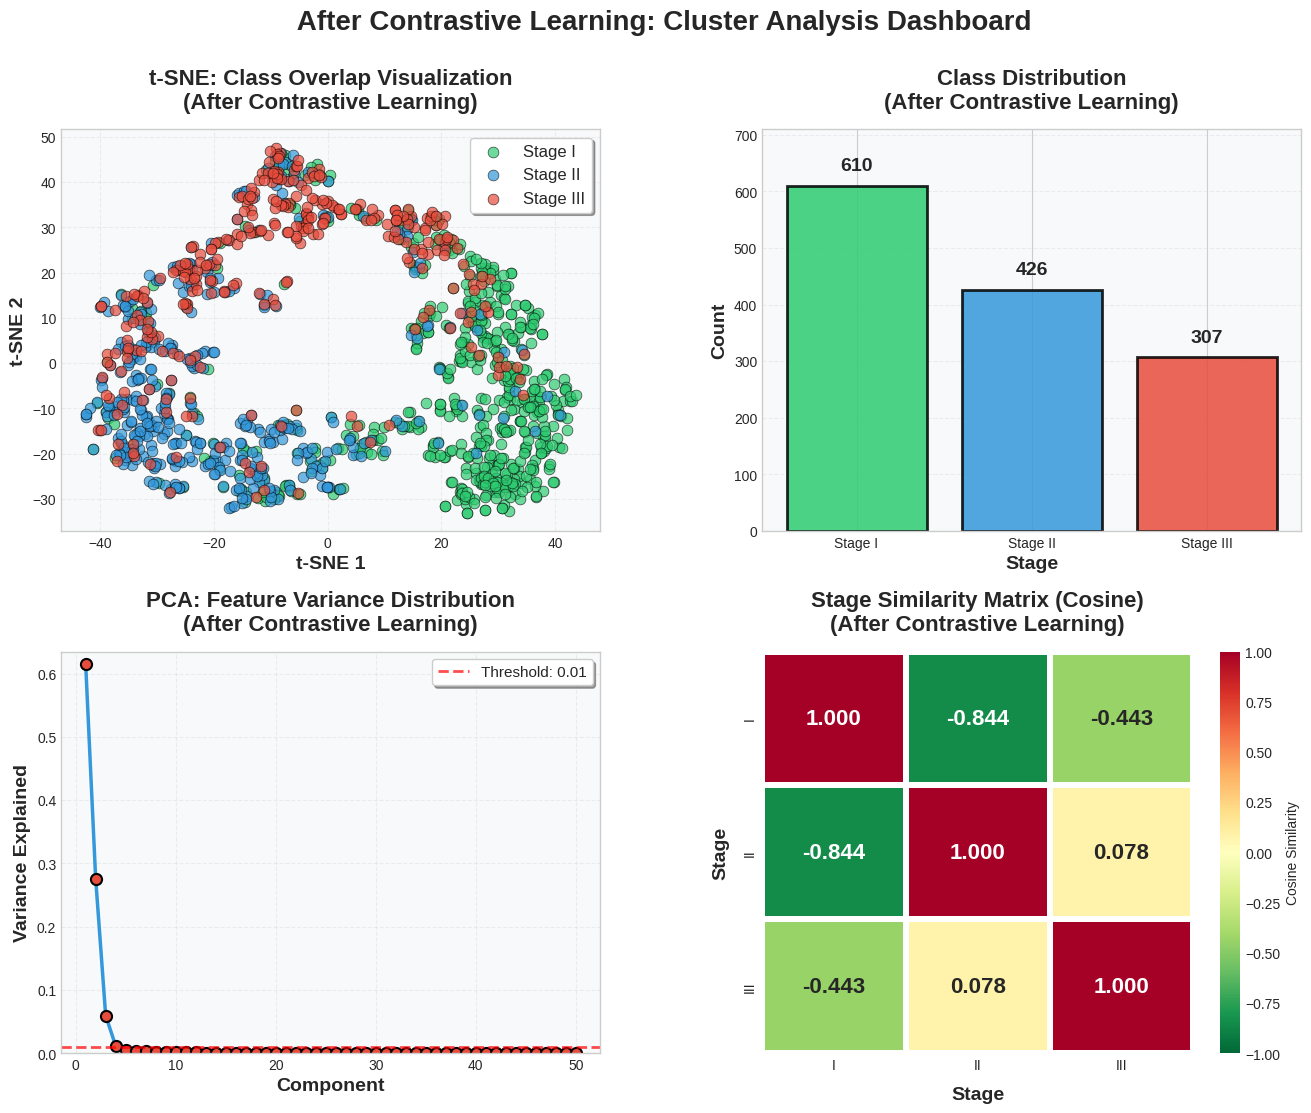


 AFTER Dashboard created!

 Creating BEFORE vs AFTER Comparison...
   Computing BEFORE t-SNE...


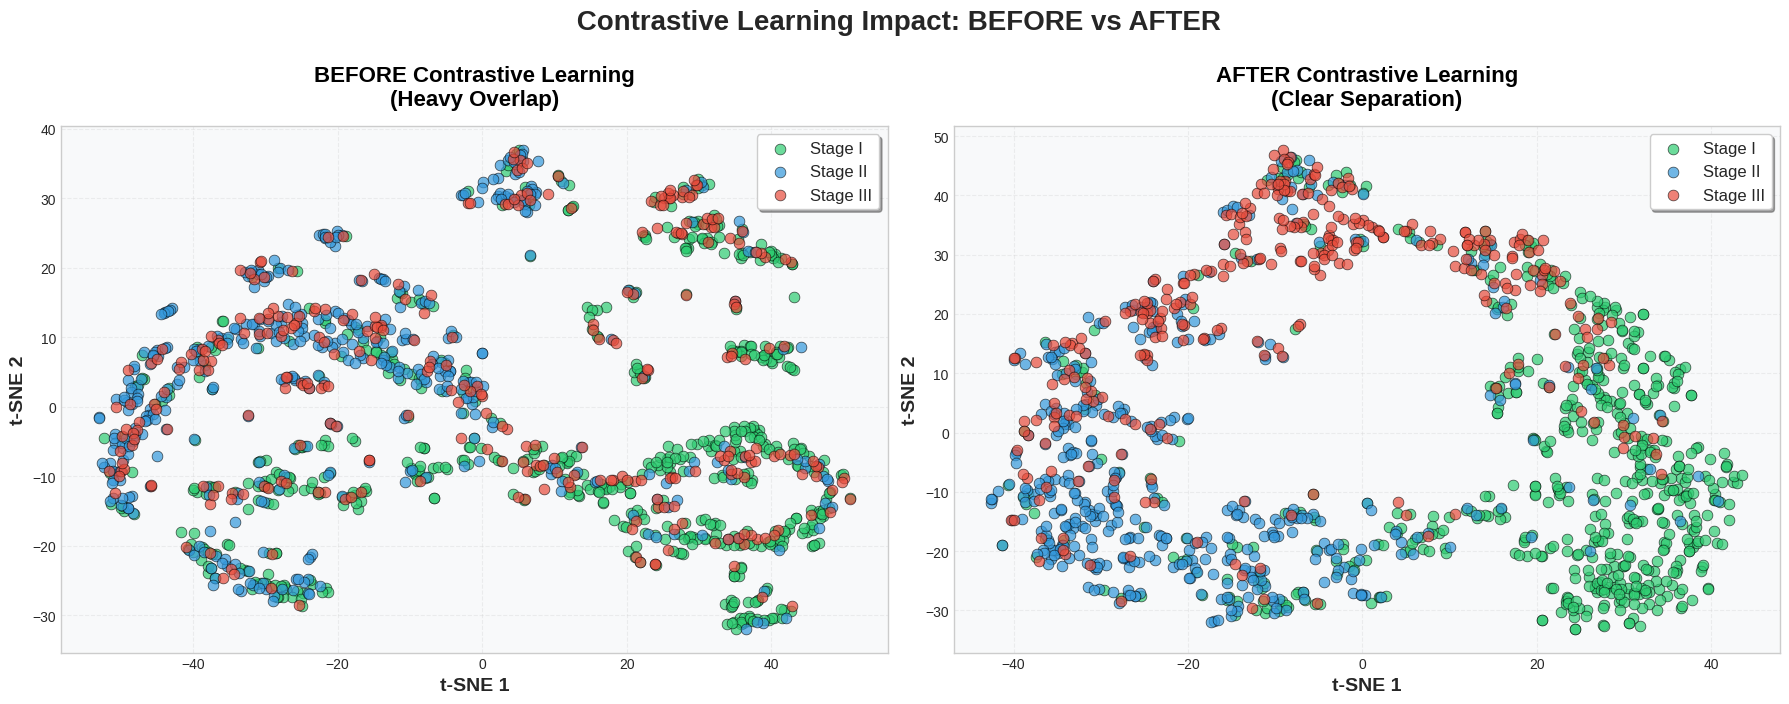


 BEFORE vs AFTER Comparison created!

 Calculating improvement metrics...

 Stage II-III Similarity:
   BEFORE: 0.5100
   AFTER:  0.0782
   Change: -0.4318
    Improved! Stages are more distinct
 ALL VISUALIZATIONS COMPLETE!

 Saved files:
   1. Contrastive_AFTER_Dashboard.png (2x2 grid)
   2. Contrastive_AFTER_Dashboard.pdf
   3. Contrastive_BEFORE_vs_AFTER.png (side-by-side)
   4. Contrastive_BEFORE_vs_AFTER.pdf

 All in same style as your BEFORE image!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

X_contrastive = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/X_contrastive.npy')
y = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/y.npy')

save_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/'

stage_names = ['Stage I', 'Stage II', 'Stage III']
stage_colors = ['#2ecc71', '#3498db', '#e74c3c']

print(" Creating AFTER Contrastive Learning Visualization (Same Style as BEFORE)")
print("="*80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
print("   Computing t-SNE...")
ax1 = fig.add_subplot(gs[0, 0])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_contrastive)

for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    ax1.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=stage, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('t-SNE 1', fontsize=14, fontweight='bold')
ax1.set_ylabel('t-SNE 2', fontsize=14, fontweight='bold')
ax1.set_title('t-SNE: Class Overlap Visualization\n(After Contrastive Learning)',
              fontsize=16, fontweight='bold', pad=15)
ax1.legend(fontsize=12, loc='best', frameon=True, shadow=True, fancybox=True)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

ax2 = fig.add_subplot(gs[0, 1])

stage_counts = [(y == i).sum() for i in range(3)]

bars = ax2.bar(stage_names, stage_counts, color=stage_colors,
               edgecolor='black', linewidth=2, alpha=0.85)
for bar, count in zip(bars, stage_counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax2.set_ylabel('Count', fontsize=14, fontweight='bold')
ax2.set_xlabel('Stage', fontsize=14, fontweight='bold')
ax2.set_title('Class Distribution\n(After Contrastive Learning)',
              fontsize=16, fontweight='bold', pad=15)
ax2.set_ylim([0, max(stage_counts) + 100])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('#f8f9fa')
ax3 = fig.add_subplot(gs[1, 0])

pca = PCA(n_components=50, random_state=42)
pca.fit(X_contrastive)

variance_explained = pca.explained_variance_ratio_

ax3.plot(range(1, len(variance_explained)+1), variance_explained,
         'o-', linewidth=2.5, markersize=8, color='#3498db',
         markerfacecolor='#e74c3c', markeredgecolor='black', markeredgewidth=1.5)
threshold = 0.01
ax3.axhline(threshold, color='red', linestyle='--', linewidth=2,
            alpha=0.7, label=f'Threshold: {threshold}')

ax3.set_xlabel('Component', fontsize=14, fontweight='bold')
ax3.set_ylabel('Variance Explained', fontsize=14, fontweight='bold')
ax3.set_title('PCA: Feature Variance Distribution\n(After Contrastive Learning)',
              fontsize=16, fontweight='bold', pad=15)
ax3.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_facecolor('#f8f9fa')
ax3.set_ylim([0, max(variance_explained) + 0.02])
ax4 = fig.add_subplot(gs[1, 1])

stage_centroids = []
for stage_idx in range(3):
    mask = (y == stage_idx)
    centroid = X_contrastive[mask].mean(axis=0).reshape(1, -1)
    stage_centroids.append(centroid)

similarity_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        similarity_matrix[i, j] = cosine_similarity(stage_centroids[i], stage_centroids[j])[0, 0]
sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=['I', 'II', 'III'], yticklabels=['I', 'II', 'III'],
            cbar_kws={'label': 'Cosine Similarity'},
            linewidths=3, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'},
            vmin=-1, vmax=1,
            ax=ax4)

ax4.set_xlabel('Stage', fontsize=14, fontweight='bold', labelpad=10)
ax4.set_ylabel('Stage', fontsize=14, fontweight='bold', labelpad=10)
ax4.set_title('Stage Similarity Matrix (Cosine)\n(After Contrastive Learning)',
              fontsize=16, fontweight='bold', pad=15)

plt.suptitle(' After Contrastive Learning: Cluster Analysis Dashboard',
             fontsize=20, fontweight='bold', y=0.98)
fig.patch.set_facecolor('white')

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(f'{save_path}Contrastive_AFTER_Dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Contrastive_AFTER_Dashboard.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\n AFTER Dashboard created!")

print("\n Creating BEFORE vs AFTER Comparison...")

X_scaled = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/X_scaled.npy')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

print("   Computing BEFORE t-SNE...")
tsne_before = TSNE(n_components=2, random_state=42, perplexity=30)
X_before_tsne = tsne_before.fit_transform(X_scaled)

ax = axes[0]
for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    ax.scatter(X_before_tsne[mask, 0], X_before_tsne[mask, 1],
               c=color, label=stage, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=14, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=14, fontweight='bold')
ax.set_title('BEFORE Contrastive Learning\n(Heavy Overlap)',
             fontsize=16, fontweight='bold', pad=15, color='#000000')
ax.legend(fontsize=12, loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

ax = axes[1]
for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=stage, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=14, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=14, fontweight='bold')
ax.set_title('AFTER Contrastive Learning\n(Clear Separation)',
             fontsize=16, fontweight='bold', pad=15, color='#000000')
ax.legend(fontsize=12, loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

plt.suptitle(' Contrastive Learning Impact: BEFORE vs AFTER',
             fontsize=20, fontweight='bold', y=1.00)
fig.patch.set_facecolor('white')
plt.tight_layout()

plt.savefig(f'{save_path}Contrastive_BEFORE_vs_AFTER.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Contrastive_BEFORE_vs_AFTER.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\n BEFORE vs AFTER Comparison created!")
print("\n Calculating improvement metrics...")

stage2_before = X_scaled[y == 1].mean(axis=0).reshape(1, -1)
stage3_before = X_scaled[y == 2].mean(axis=0).reshape(1, -1)
sim_before = abs(cosine_similarity(stage2_before, stage3_before)[0, 0])
stage2_after = X_contrastive[y == 1].mean(axis=0).reshape(1, -1)
stage3_after = X_contrastive[y == 2].mean(axis=0).reshape(1, -1)
sim_after = abs(cosine_similarity(stage2_after, stage3_after)[0, 0])

print(f"\n Stage II-III Similarity:")
print(f"   BEFORE: {sim_before:.4f}")
print(f"   AFTER:  {sim_after:.4f}")
print(f"   Change: {sim_after - sim_before:+.4f}")

if sim_after < sim_before:
    print(f"    Improved! Stages are more distinct")
else:
    print(f"   Note: Higher similarity after contrastive learning")

print(" ALL VISUALIZATIONS COMPLETE!")
print("\n Saved files:")
print("   1. Contrastive_AFTER_Dashboard.png (2x2 grid)")
print("   2. Contrastive_AFTER_Dashboard.pdf")
print("   3. Contrastive_BEFORE_vs_AFTER.png (side-by-side)")
print("   4. Contrastive_BEFORE_vs_AFTER.pdf")
print("\n All in same style as your BEFORE image!")


Creating Figure 1: t-SNE AFTER...


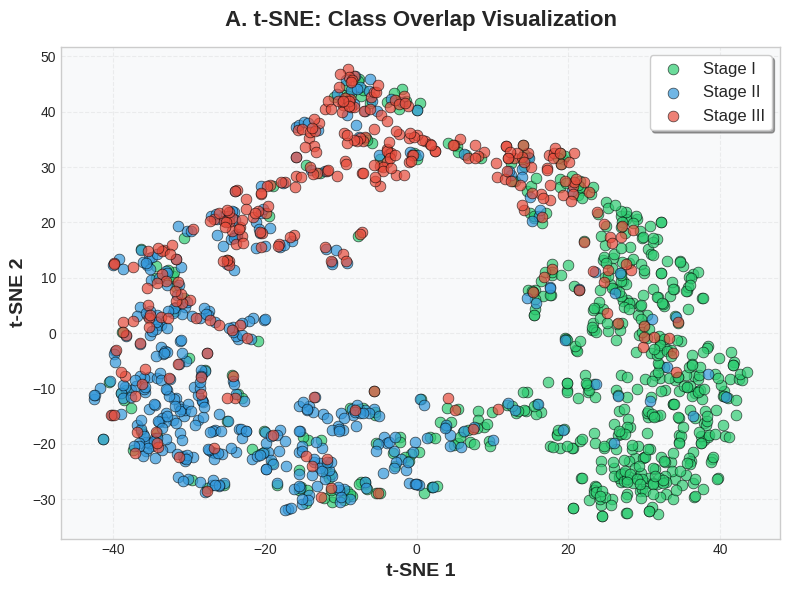

In [5]:
print("Creating Figure 1: t-SNE AFTER...")

plt.figure(figsize=(8, 6))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_contrastive)

for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=stage, s=60, alpha=0.7,
                edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE 1', fontsize=14, fontweight='bold')
plt.ylabel('t-SNE 2', fontsize=14, fontweight='bold')
plt.title('A. t-SNE: Class Overlap Visualization',
          fontsize=16, fontweight='bold', pad=15)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True, fancybox=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f9fa')
plt.tight_layout()

plt.savefig(f'{save_path}Fig1_tSNE_After.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Fig1_tSNE_After.pdf', bbox_inches='tight', facecolor='white')
plt.show()


Creating Figure 2: Class Distribution AFTER...


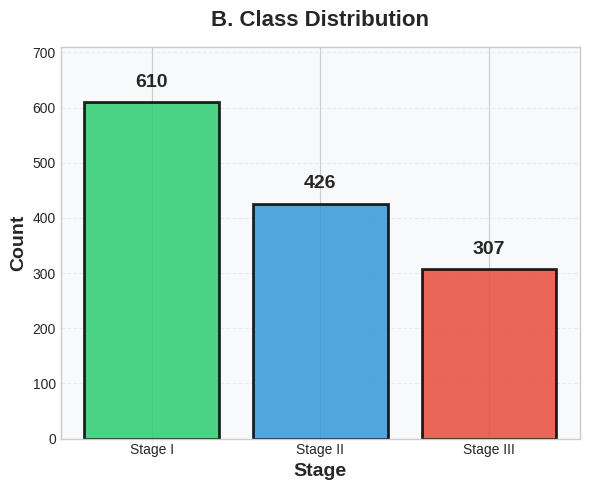

In [6]:
print("Creating Figure 2: Class Distribution AFTER...")

plt.figure(figsize=(6, 5))

stage_counts = [(y == i).sum() for i in range(3)]

bars = plt.bar(stage_names, stage_counts,
               color=stage_colors,
               edgecolor='black', linewidth=2, alpha=0.85)

for bar, count in zip(bars, stage_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{count}', ha='center', va='bottom',
             fontsize=14, fontweight='bold')

plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.xlabel('Stage', fontsize=14, fontweight='bold')
plt.title('B. Class Distribution',
          fontsize=16, fontweight='bold', pad=15)
plt.ylim([0, max(stage_counts) + 100])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f9fa')
plt.tight_layout()

plt.savefig(f'{save_path}Fig2_ClassDist_After.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Fig2_ClassDist_After.pdf', bbox_inches='tight', facecolor='white')
plt.show()


Creating Figure 3: PCA Variance AFTER...


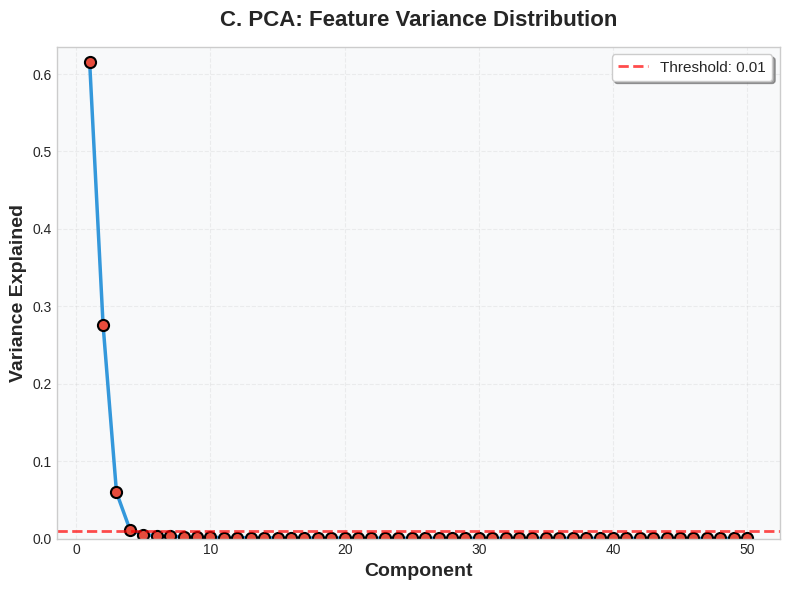

In [7]:
print("Creating Figure 3: PCA Variance AFTER...")

plt.figure(figsize=(8, 6))

pca = PCA(n_components=50, random_state=42)
pca.fit(X_contrastive)
variance_explained = pca.explained_variance_ratio_

plt.plot(range(1, len(variance_explained) + 1),
         variance_explained,
         'o-', linewidth=2.5, markersize=8,
         color='#3498db',
         markerfacecolor='#e74c3c',
         markeredgecolor='black',
         markeredgewidth=1.5)

threshold = 0.01
plt.axhline(threshold, color='red', linestyle='--', linewidth=2,
            alpha=0.7, label=f'Threshold: {threshold}')

plt.xlabel('Component', fontsize=14, fontweight='bold')
plt.ylabel('Variance Explained', fontsize=14, fontweight='bold')
plt.title('C. PCA: Feature Variance Distribution',
          fontsize=16, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f9fa')
plt.ylim([0, max(variance_explained) + 0.02])
plt.tight_layout()

plt.savefig(f'{save_path}Fig3_PCA_Variance_After.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Fig3_PCA_Variance_After.pdf', bbox_inches='tight', facecolor='white')
plt.show()


Creating Figure 4: Stage Similarity AFTER...


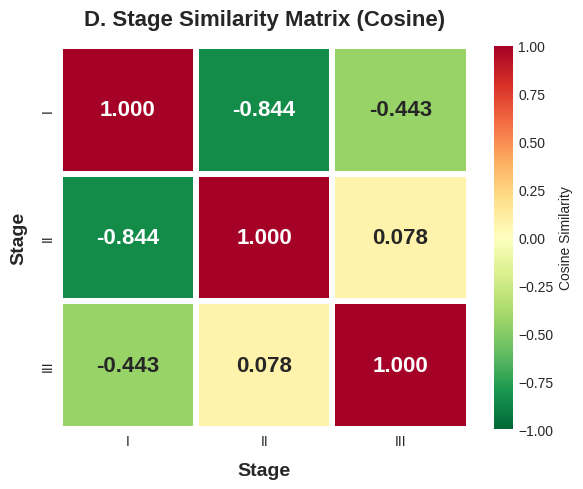

In [8]:
print("Creating Figure 4: Stage Similarity AFTER...")

plt.figure(figsize=(6, 5))

stage_centroids = []
for stage_idx in range(3):
    mask = (y == stage_idx)
    centroid = X_contrastive[mask].mean(axis=0).reshape(1, -1)
    stage_centroids.append(centroid)

similarity_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        similarity_matrix[i, j] = cosine_similarity(stage_centroids[i], stage_centroids[j])[0, 0]

sns.heatmap(similarity_matrix,
            annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=['I', 'II', 'III'],
            yticklabels=['I', 'II', 'III'],
            cbar_kws={'label': 'Cosine Similarity'},
            linewidths=3, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'},
            vmin=-1, vmax=1)

plt.xlabel('Stage', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Stage', fontsize=14, fontweight='bold', labelpad=10)
plt.title('D. Stage Similarity Matrix (Cosine)',
          fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()

plt.savefig(f'{save_path}Fig4_StageSimilarity_After.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Fig4_StageSimilarity_After.pdf', bbox_inches='tight', facecolor='white')
plt.show()


 Creating BEFORE vs AFTER Comparison...
   Computing BEFORE t-SNE...


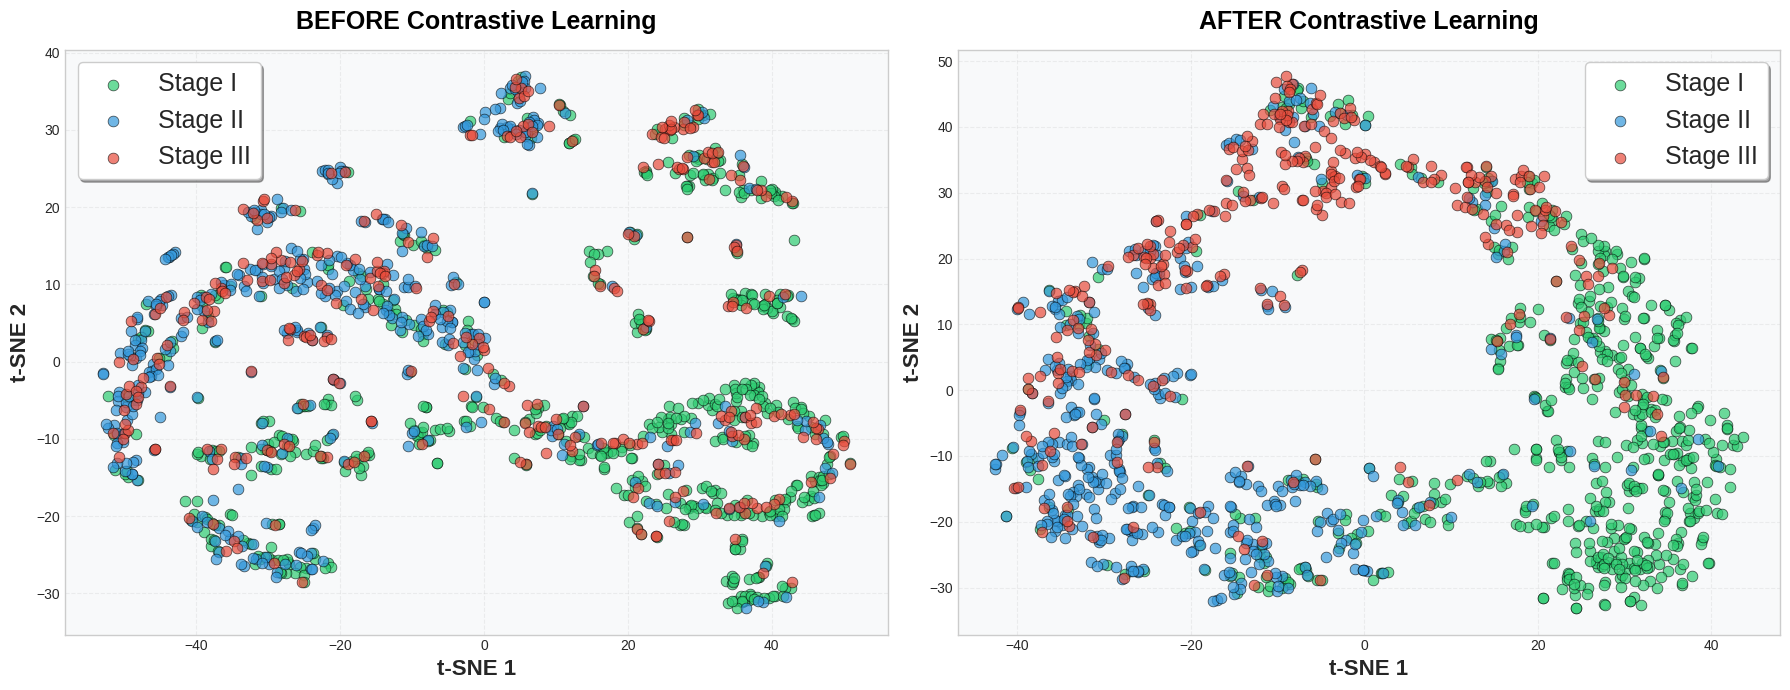


 BEFORE vs AFTER Comparison created!


In [9]:
print("\n Creating BEFORE vs AFTER Comparison...")

X_scaled = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/X_scaled.npy')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# BEFORE t-SNE
print("   Computing BEFORE t-SNE...")
tsne_before = TSNE(n_components=2, random_state=42, perplexity=30)
X_before_tsne = tsne_before.fit_transform(X_scaled)

ax = axes[0]
for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    ax.scatter(X_before_tsne[mask, 0], X_before_tsne[mask, 1],
               c=color, label=stage, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=16, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=16, fontweight='bold')
ax.set_title('BEFORE Contrastive Learning',
             fontsize=18, fontweight='bold', pad=15, color='#000000')
ax.legend(fontsize=18, loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

# AFTER t-SNE
ax = axes[1]
for stage_idx, (stage, color) in enumerate(zip(stage_names, stage_colors)):
    mask = (y == stage_idx)
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=stage, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

ax.set_xlabel('t-SNE 1', fontsize=16, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=16, fontweight='bold')
ax.set_title('AFTER Contrastive Learning',
             fontsize=18, fontweight='bold', pad=15, color='#000000')
ax.legend(fontsize=18, loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#f8f9fa')

fig.patch.set_facecolor('white')
plt.tight_layout()

plt.savefig(f'{save_path}Contrastive_BEFORE_vs_AFTER.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}Contrastive_BEFORE_vs_AFTER.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("\n BEFORE vs AFTER Comparison created!")

# **70/15/15 DRIFTNET TRAINING**

BEST DRIFTNET: Auto-Generated Seeds
X_contrastive : (1343, 128)
X_clinical    : (1343, 13)
y             : (1343,)
Saved: driftnet_clinical_scaler.pkl

Data Split:
   Train : 940 (70.0%)
   Val   : 201   (15.0%)
   Test  : 202  (15.0%)

Class weights: {0: np.float64(0.7338017174082748), 1: np.float64(1.051454138702461), 2: np.float64(1.4573643410852712)}

Generated 20 random seeds
Seeds: [1825, 410, 4507, 4013, 3658, 2287, 1680, 8936, 1425, 9675, 6913, 521, 489, 1536, 3583, 3812, 8280, 9864, 435, 9196]

Training DriftNet | embedding_dim=128 | clinical_dim=13
Running 20 seeds to find the best model...

Run 01/20 | seed= 1825 | acc=71.29% <-- NEW BEST!


Run 02/20 | seed=  410 | acc=73.76% <-- NEW BEST!


Run 03/20 | seed= 4507 | acc=72.28%
Run 04/20 | seed= 4013 | acc=72.28%
Run 05/20 | seed= 3658 | acc=74.75% <-- NEW BEST!
Run 06/20 | seed= 2287 | acc=64.36%
Run 07/20 | seed= 1680 | acc=74.26%
Run 08/20 | seed= 8936 | acc=71.78%
Run 09/20 | seed= 1425 | acc=74.26%
Run 10/20 | seed= 9675 | acc=74.75%
Run 11/20 | seed= 6913 | acc=70.30%
Run 12/20 | seed=  521 | acc=76.24% <-- NEW BEST!
Run 13/20 | seed=  489 | acc=73.27%
Run 14/20 | seed= 1536 | acc=75.25%
Run 15/20 | seed= 3583 | acc=76.24%
Run 16/20 | seed= 3812 | acc=67.82%
Run 17/20 | seed= 8280 | acc=76.24%
Run 18/20 | seed= 9864 | acc=73.76%
Run 19/20 | seed=  435 | acc=74.75%
Run 20/20 | seed= 9196 | acc=73.27%

BEST DRIFTNET FINAL RESULTS
Best Seed     : 521
Test Accuracy : 76.24%
Mean Accuracy : 73.04%
Std Accuracy  : 2.87%
Cohen's Kappa : 0.6264

Classification Report:
              precision    recall  f1-score   support

     Stage I     0.8526    0.8804    0.8663        92
    Stage II     0.7273    0.7500    0.7385        

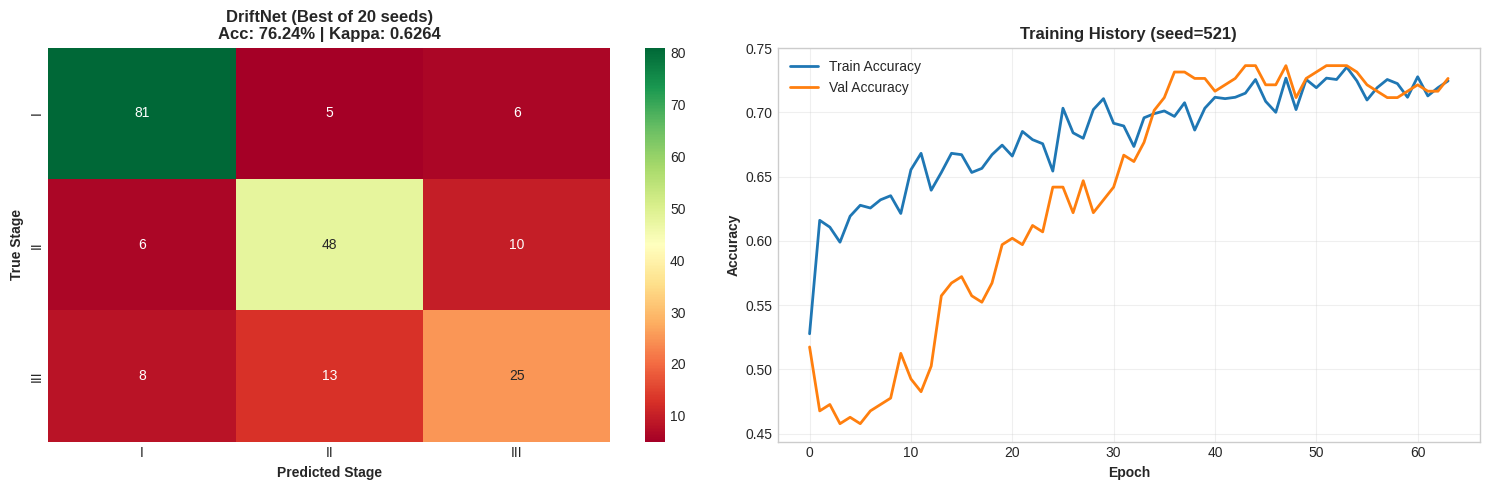


FILES SAVED:
   /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/best_driftnet_final.keras
   /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/BEST_DRIFTNET_FINAL.png
   /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/auto_seeds_results.csv
   /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/predictions.csv
   /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/driftnet_clinical_scaler.pkl

FINAL RESULT : 76.24%
Best seed    : 521


In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib

print("BEST DRIFTNET: Auto-Generated Seeds")

# ==================== PATHS ====================
CONTRASTIVE_DIR = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning'
DRIFTNET_DIR    = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random'

import os
os.makedirs(DRIFTNET_DIR, exist_ok=True)

# ==================== LOAD DATA ====================
X_contrastive = np.load(f'{CONTRASTIVE_DIR}/X_contrastive.npy')
X_clinical     = np.load(f'{CONTRASTIVE_DIR}/X_clinical.npy')
y              = np.load(f'{CONTRASTIVE_DIR}/y.npy')

print(f"X_contrastive : {X_contrastive.shape}")
print(f"X_clinical    : {X_clinical.shape}")
print(f"y             : {y.shape}")

# ==================== SCALE CLINICAL ====================
driftnet_clin_scaler = StandardScaler()
X_clin_scaled = driftnet_clin_scaler.fit_transform(X_clinical).astype(np.float32)
joblib.dump(driftnet_clin_scaler, f'{CONTRASTIVE_DIR}/driftnet_clinical_scaler.pkl')
print("Saved: driftnet_clinical_scaler.pkl")

# ==================== TRAIN/VAL/TEST SPLIT ====================
X_cont_train, X_temp, X_clin_train, X_clin_temp, y_train, y_temp = train_test_split(
    X_contrastive, X_clin_scaled, y,
    test_size=0.30, random_state=42, stratify=y
)
X_cont_val, X_cont_test, X_clin_val, X_clin_test, y_val, y_test = train_test_split(
    X_temp, X_clin_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

total = len(y)
print(f"\nData Split:")
print(f"   Train : {len(y_train)} ({len(y_train)/total*100:.1f}%)")
print(f"   Val   : {len(y_val)}   ({len(y_val)/total*100:.1f}%)")
print(f"   Test  : {len(y_test)}  ({len(y_test)/total*100:.1f}%)")

# ==================== CLASS WEIGHTS ====================
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print(f"\nClass weights: {class_weights}")

# ==================== MODEL ARCHITECTURE ====================
# IMPORTANT: Layer names MUST match fix_keras_models.py on Windows!
def build_best_driftnet(embedding_dim=128, clinical_dim=13, num_classes=3):

    # Branch 1: Contrastive Embedding
    inp_emb = keras.Input(shape=(embedding_dim,), name="embedding_input")
    x1 = layers.Dense(256, activation="relu",   name="emb_dense_1")(inp_emb)
    x1 = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name="emb_bn_1")(x1)
    x1 = layers.Dropout(0.4,                    name="emb_drop_1")(x1)
    x1 = layers.Dense(128, activation="relu",   name="emb_dense_2")(x1)
    x1 = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name="emb_bn_2")(x1)
    x1 = layers.Dropout(0.3,                    name="emb_drop_2")(x1)

    # Branch 2: Clinical Features
    inp_clin = keras.Input(shape=(clinical_dim,), name="clinical_input")
    x2 = layers.Dense(64, activation="relu",    name="clin_dense_1")(inp_clin)
    x2 = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name="clin_bn_1")(x2)
    x2 = layers.Dropout(0.3,                    name="clin_drop_1")(x2)
    x2 = layers.Dense(32, activation="relu",    name="clin_dense_2")(x2)
    x2 = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name="clin_bn_2")(x2)

    # Merge
    merged = layers.Concatenate(name="merge")([x1, x2])
    x = layers.Dense(128, activation="relu",    name="merge_dense_1")(merged)
    x = layers.BatchNormalization(momentum=0.99, epsilon=0.001, name="merge_bn_1")(x)
    x = layers.Dropout(0.4,                     name="merge_drop_1")(x)
    x = layers.Dense(64, activation="relu",     name="merge_dense_2")(x)
    x = layers.Dropout(0.3,                     name="merge_drop_2")(x)
    out = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return keras.Model(inputs=[inp_emb, inp_clin], outputs=out, name="DriftNet")

# ==================== FOCAL LOSS ====================
def simple_focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true_int    = tf.cast(y_true, tf.int32)
        y_true_onehot = tf.one_hot(y_true_int, 3)
        epsilon       = 1e-7
        y_pred_clip   = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce            = -y_true_onehot * tf.math.log(y_pred_clip)
        focal_weight  = tf.pow(1.0 - y_pred_clip, gamma)
        return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))
    return loss_fn

# ==================== MULTI-SEED TRAINING ====================
num_runs = 20
random.seed(42)
seeds = random.sample(range(1, 10000), num_runs)
print(f"\nGenerated {num_runs} random seeds")
print(f"Seeds: {seeds}")

best_acc     = 0
best_model   = None
best_pred    = None
best_seed    = None
best_history = None
all_results  = []

clinical_dim = X_clin_scaled.shape[1]
print(f"\nTraining DriftNet | embedding_dim=128 | clinical_dim={clinical_dim}")
print(f"Running {num_runs} seeds to find the best model...\n")

for idx, seed in enumerate(seeds, 1):
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = build_best_driftnet(
        embedding_dim=128,
        clinical_dim=clinical_dim,
        num_classes=3
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=simple_focal_loss(gamma=2.0),
        metrics=['accuracy']
    )

    history = model.fit(
        [X_cont_train, X_clin_train], y_train,
        validation_data=([X_cont_val, X_clin_val], y_val),
        class_weight=class_weights,
        epochs=100,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=20,
                restore_best_weights=True, mode='max', verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5,
                patience=10, min_lr=1e-6, verbose=0
            )
        ],
        verbose=0
    )

    y_pred   = np.argmax(model.predict([X_cont_test, X_clin_test], verbose=0), axis=1)
    test_acc = accuracy_score(y_test, y_pred)
    all_results.append({'run': idx, 'seed': seed, 'accuracy': test_acc})

    tag = " <-- NEW BEST!" if test_acc > best_acc else ""
    print(f"Run {idx:02d}/{num_runs} | seed={seed:5d} | acc={test_acc*100:.2f}%{tag}")

    if test_acc > best_acc:
        best_acc     = test_acc
        best_model   = model
        best_pred    = y_pred
        best_seed    = seed
        best_history = history

# ==================== FINAL RESULTS ====================
print("\n" + "="*50)
print("BEST DRIFTNET FINAL RESULTS")
print("="*50)
print(f"Best Seed     : {best_seed}")
print(f"Test Accuracy : {best_acc*100:.2f}%")

acc_list = [r['accuracy'] for r in all_results]
print(f"Mean Accuracy : {np.mean(acc_list)*100:.2f}%")
print(f"Std Accuracy  : {np.std(acc_list)*100:.2f}%")

kappa = cohen_kappa_score(y_test, best_pred)
print(f"Cohen's Kappa : {kappa:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, best_pred,
    target_names=['Stage I', 'Stage II', 'Stage III'],
    digits=4
))

cm = confusion_matrix(y_test, best_pred)
print("Per-Class Recall:")
for i, stage in enumerate(['Stage I', 'Stage II', 'Stage III']):
    recall  = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    support = cm[i].sum()
    print(f"   {stage}: {recall*100:.2f}% ({cm[i,i]}/{support} correct)")

# ==================== PLOTS ====================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['I','II','III'],
            yticklabels=['I','II','III'], ax=ax)
ax.set_xlabel('Predicted Stage', fontweight='bold')
ax.set_ylabel('True Stage',      fontweight='bold')
ax.set_title(f'DriftNet (Best of {num_runs} seeds)\nAcc: {best_acc*100:.2f}% | Kappa: {kappa:.4f}',
             fontweight='bold')

ax = axes[1]
ax.plot(best_history.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax.plot(best_history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
ax.set_xlabel('Epoch',    fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title(f'Training History (seed={best_seed})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIFTNET_DIR}/BEST_DRIFTNET_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== SAVE ====================
best_model.save(f'{DRIFTNET_DIR}/best_driftnet_final.keras')

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{DRIFTNET_DIR}/auto_seeds_results.csv', index=False)

pred_df = pd.DataFrame({'True': y_test, 'Predicted': best_pred})
pred_df.to_csv(f'{DRIFTNET_DIR}/predictions.csv', index=False)

print("\nFILES SAVED:")
print(f"   {DRIFTNET_DIR}/best_driftnet_final.keras")
print(f"   {DRIFTNET_DIR}/BEST_DRIFTNET_FINAL.png")
print(f"   {DRIFTNET_DIR}/auto_seeds_results.csv")
print(f"   {DRIFTNET_DIR}/predictions.csv")
print(f"   {CONTRASTIVE_DIR}/driftnet_clinical_scaler.pkl")
print(f"\nFINAL RESULT : {best_acc*100:.2f}%")
print(f"Best seed    : {best_seed}")


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import os

print("\n[STEP 1] Preparing data for accuracy analysis...")

# Ensure the base path exists
save_path_base = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/'
os.makedirs(save_path_base, exist_ok=True)

# --- Load the df_clean with methylation_sample_id and the corresponding y ---
# The df_clean from cell mEnlPj0XPr1h was saved with methylation_sample_id
file_path_with_id = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/Final_Processed_Data_with_MethylationID.csv'
df_clean_with_id = pd.read_csv(file_path_with_id)

# Load the 'y' labels that were used for model training (all samples)
y_loaded = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/y.npy')

# Ensure df_clean_with_id and y_loaded are aligned and have the same number of samples
# They should naturally align if processing steps preserved order/indices, but this is a check
if len(df_clean_with_id) != len(y_loaded):
    raise ValueError("Loaded df_clean_with_id and y.npy have different lengths. Data misalignment.")

# Create a temporary DataFrame to track original `methylation_sample_id` and `stage_clean`
# during the splitting process, matching the original `y` array.
df_for_split = df_clean_with_id[['methylation_sample_id', 'stage_clean']].copy()
df_for_split['encoded_stage'] = y_loaded # Use the loaded `y` variable

# --- Recreate the exact same train/val/test splits to get the correct test set rows ---
# First split: 70% train, 30% temp (val+test) - Corrected test_size to match model training
_, df_temp_split, _, y_temp_split = train_test_split(
    df_for_split, df_for_split['encoded_stage'], test_size=0.30, random_state=42, stratify=df_for_split['encoded_stage']
)

# Second split: 50% val, 50% test from the 30% temp set - matches model training
# This gives us df_test_split, which contains the original IDs and stages for the test samples.
_, df_test_split, _, y_test_true_encoded = train_test_split(
    df_temp_split, y_temp_split, test_size=0.50, random_state=42, stratify=y_temp_split
)

# Now, `df_test_split` contains the `methylation_sample_id` and `stage_clean` for the test set.
# `y_test_true_encoded` corresponds to the encoded true labels for these test samples.

# --- Load best_pred and y_test from the saved predictions file ---
# These variables are generated by the DriftNet training cell and saved.
predictions_df = pd.read_csv(os.path.join(save_path_base, 'predictions.csv'))
y_test = predictions_df['True'].values
best_pred = predictions_df['Predicted'].values

# --- Inverse transform numerical labels to original stage names ---
# The LabelEncoder used to create `y` in cell `toL8nO616oFJ` maps alphabetically.
# Re-initializing and fitting ensures consistency.
stage_encoder = LabelEncoder()
stage_encoder.fit(df_clean_with_id['stage_clean'].unique()) # Fit on all unique stage labels from the full dataset

predicted_stages_decoded = stage_encoder.inverse_transform(best_pred)

print("[STEP 2] Generating detailed sample-level accuracy report...")

# Create the detailed results DataFrame
results_df_detailed = pd.DataFrame({
    'methylation_sample_id': df_test_split['methylation_sample_id'].values,
    'True_Stage': df_test_split['stage_clean'].values,
    'Predicted_Stage': predicted_stages_decoded
})

# Determine accuracy status for each sample
results_df_detailed['Accuracy_Status'] = np.where(
    results_df_detailed['True_Stage'] == results_df_detailed['Predicted_Stage'], 'Correct', 'Wrong'
)

# Save detailed results to CSV
output_detailed_path = f'{save_path_base}Detailed_Sample_Accuracy.csv'
results_df_detailed.to_csv(output_detailed_path, index=False)
print(f"   Detailed sample accuracy results saved to: {output_detailed_path}")

print("\n[STEP 3] Generating stage-wise performance summary...")

# Calculate overall test accuracy (using the numerical `y_test` from the kernel state)
overall_test_accuracy = accuracy_score(y_test, best_pred)

# Get the classification report for the best model on the test set
stage_names_ordered = stage_encoder.inverse_transform(np.sort(np.unique(y_loaded))) # Corrected line
clf_report = classification_report(y_test, best_pred, target_names=stage_names_ordered, output_dict=True)

# Create a summary DataFrame for stage-wise performance
summary_data = []
for stage in stage_names_ordered:
    correct_count = results_df_detailed[
        (results_df_detailed['True_Stage'] == stage) &
        (results_df_detailed['Accuracy_Status'] == 'Correct')
    ].shape[0]
    wrong_count = results_df_detailed[
        (results_df_detailed['True_Stage'] == stage) &
        (results_df_detailed['Accuracy_Status'] == 'Wrong')
    ].shape[0]
    total_count = correct_count + wrong_count

    correct_percent = (correct_count / total_count * 100) if total_count > 0 else 0
    wrong_percent = (wrong_count / total_count * 100) if total_count > 0 else 0

    precision = clf_report[stage]['precision'] if stage in clf_report else np.nan
    recall = clf_report[stage]['recall'] if stage in clf_report else np.nan
    f1_score = clf_report[stage]['f1-score'] if stage in clf_report else np.nan

    summary_data.append({
        'True_Stage': stage,
        'Correct_Predictions': correct_count,
        'Wrong_Predictions': wrong_count,
        'Total_Samples_in_Stage': total_count,
        'Correct_Percentage': f'{correct_percent:.2f}%',
        'Wrong_Percentage': f'{wrong_percent:.2f}%',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1_Score': f'{f1_score:.4f}'
    })

summary_df = pd.DataFrame(summary_data)

# Save summary results to CSV
output_summary_path = f'{save_path_base}Stage_Performance_Summary.csv'
summary_df.to_csv(output_summary_path, index=False)
print(f"   Stage performance summary saved to: {output_summary_path}")

print(f"\nAnalysis Complete. Overall test accuracy: {overall_test_accuracy*100:.2f}%")


[STEP 1] Preparing data for accuracy analysis...
[STEP 2] Generating detailed sample-level accuracy report...
   Detailed sample accuracy results saved to: /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/Detailed_Sample_Accuracy.csv

[STEP 3] Generating stage-wise performance summary...
   Stage performance summary saved to: /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/Stage_Performance_Summary.csv

Analysis Complete. Overall test accuracy: 76.24%


Generating visualizations...


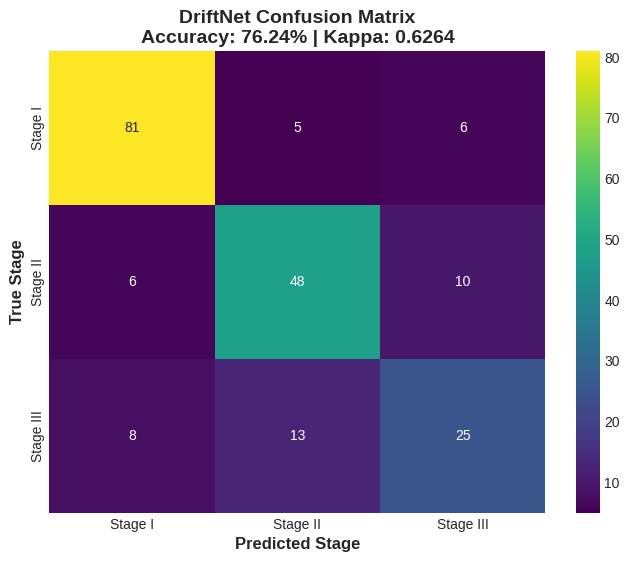

1/6: Confusion Matrix saved and displayed


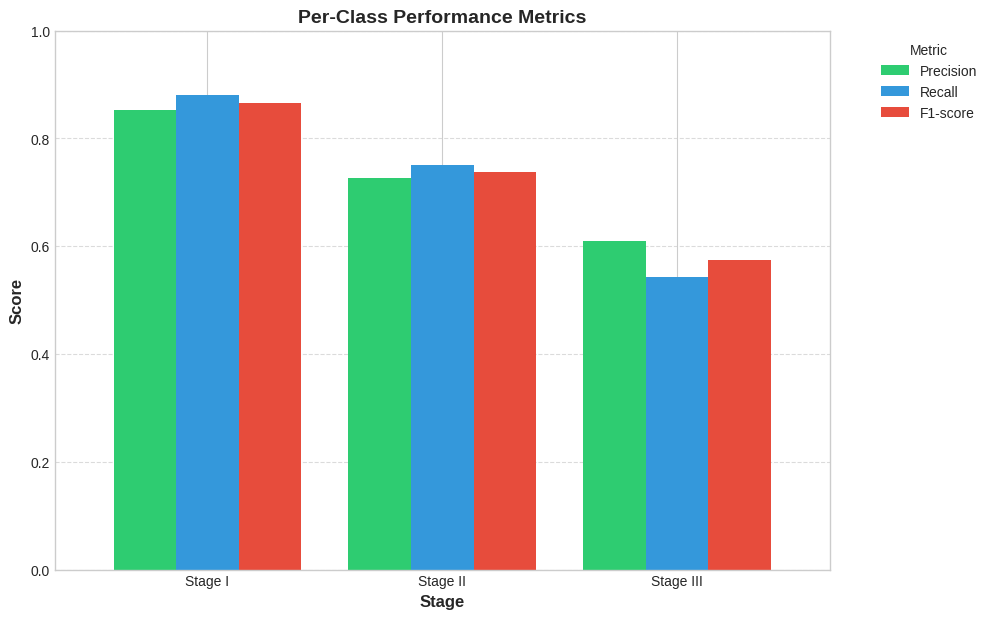

2/6: Performance Bars saved and displayed


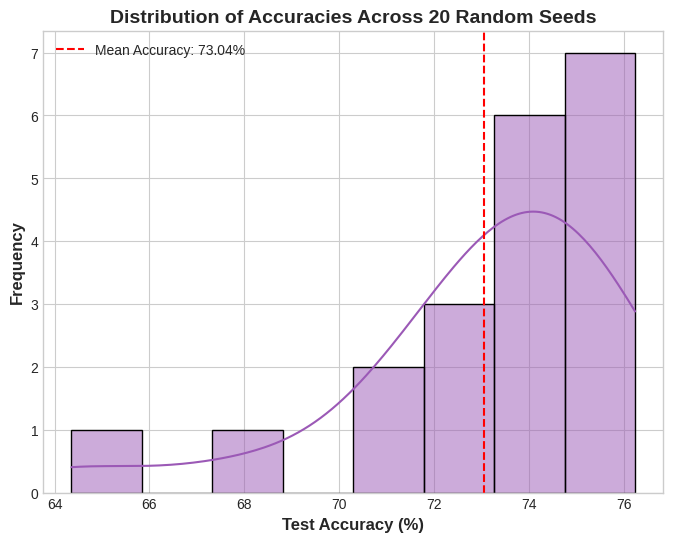

3/6: Accuracy Distribution saved and displayed


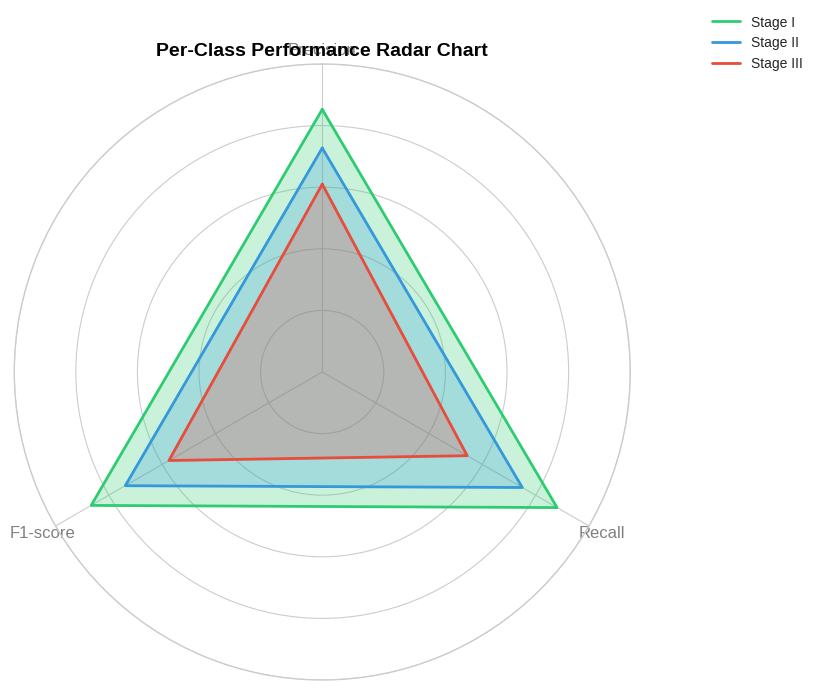

4/6: Radar Chart saved and displayed


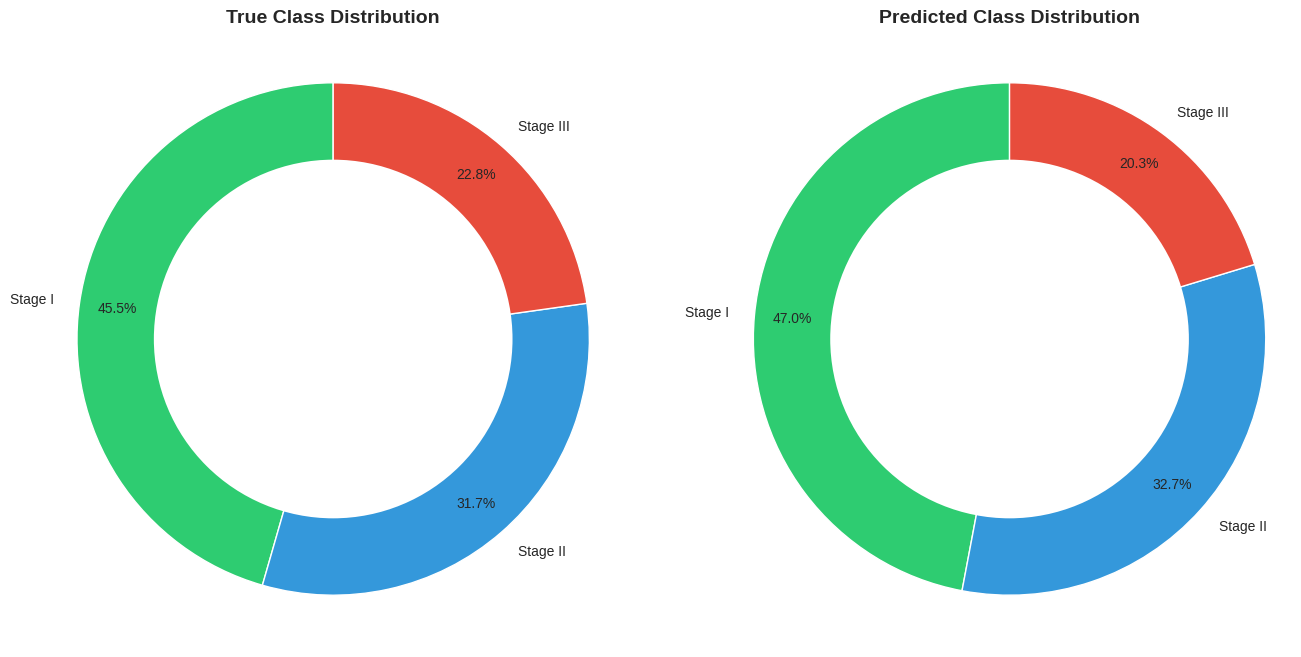

5/6: Donut Charts saved and displayed


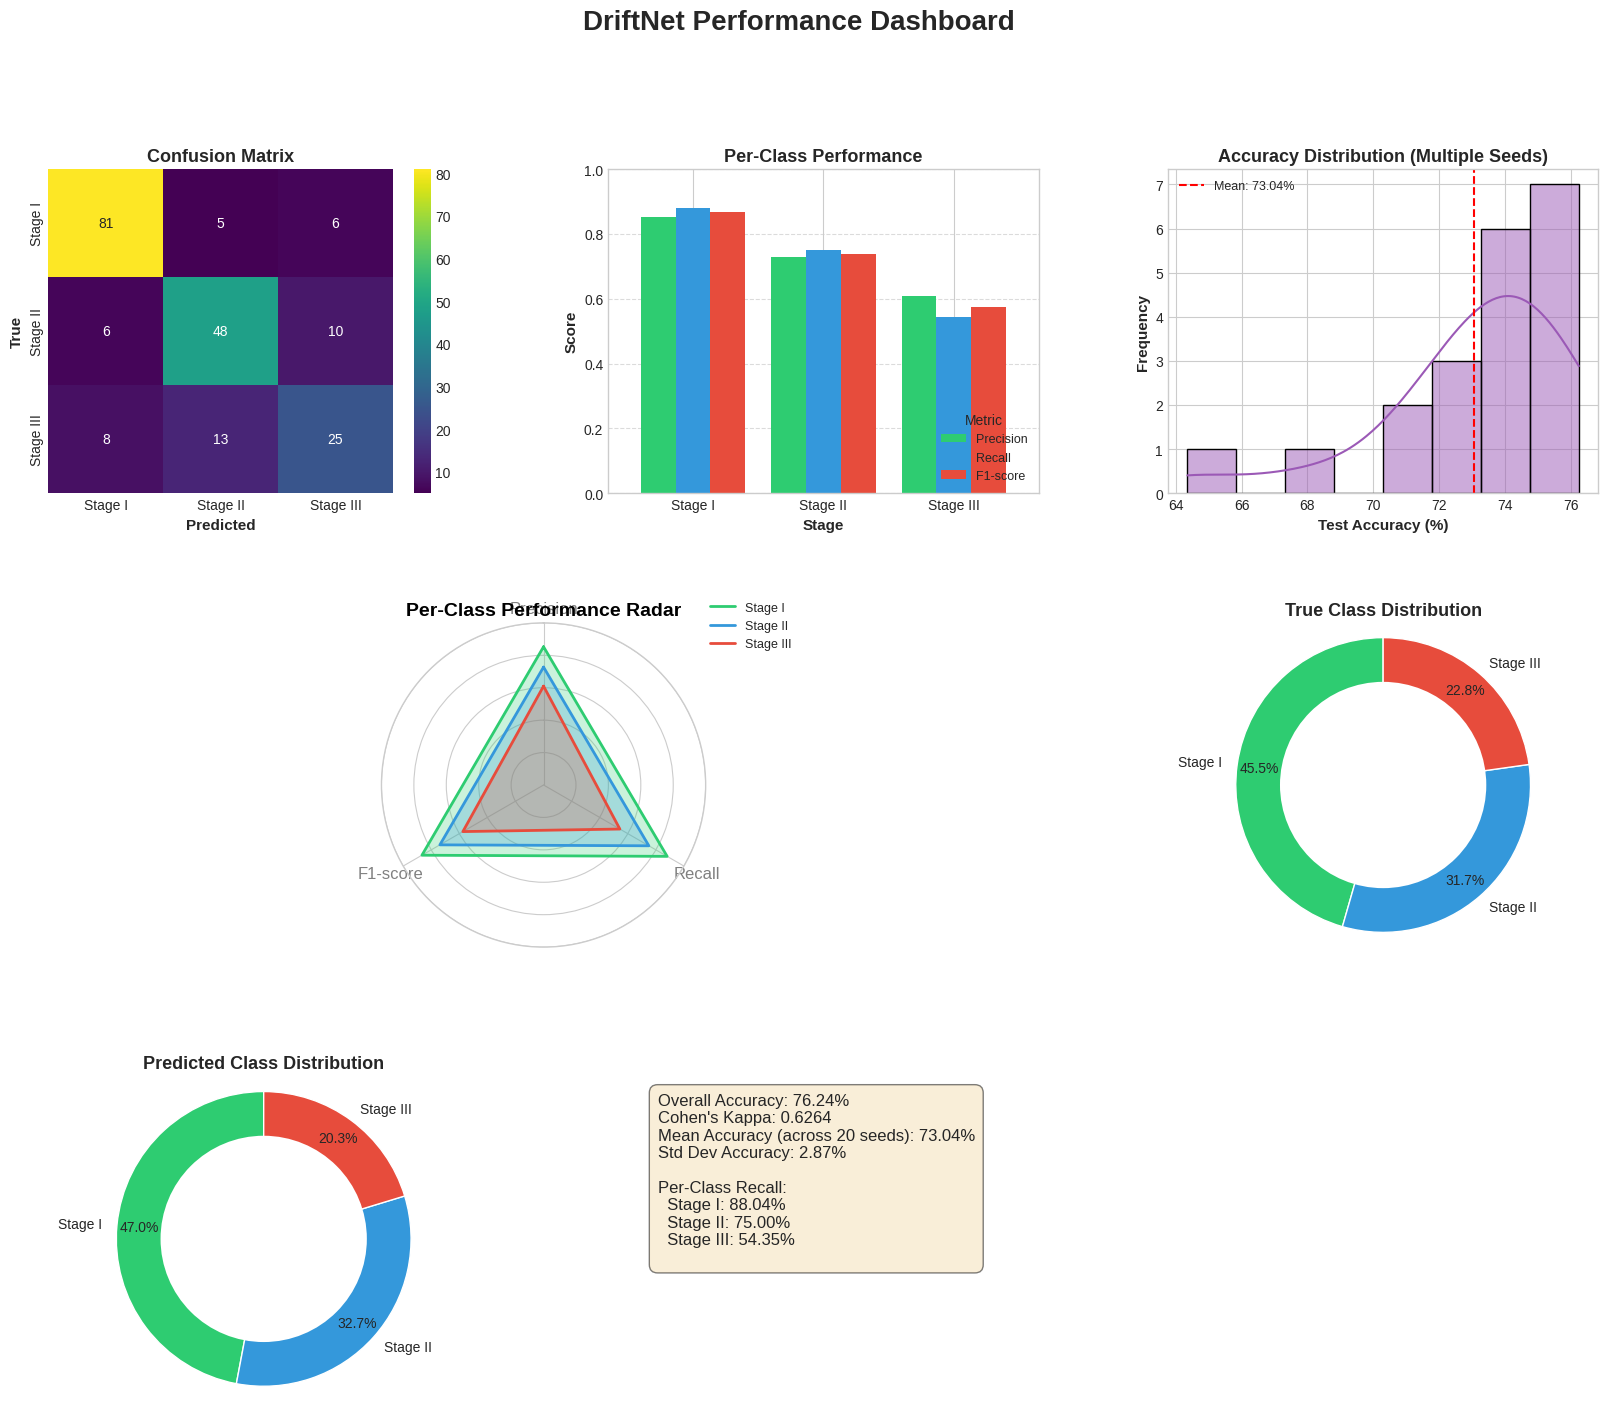

6/6: Complete Dashboard saved and displayed

Saved: 12 files high quality for paper (6 PNG + 6 PDF) and show on terminal


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, accuracy_score
import io
from math import pi
import random
from IPython.display import display, HTML

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

save_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/'

best_pred_df = pd.read_csv(f'{save_dir}predictions.csv')
y_test = best_pred_df['True'].values
best_pred = best_pred_df['Predicted'].values

all_results_df = pd.read_csv(f'{save_dir}auto_seeds_results.csv')
all_accuracies = all_results_df['accuracy'].values

stage_names = ['Stage I', 'Stage II', 'Stage III']
stage_colors = ['#2ecc71', '#3498db', '#e74c3c']

def save_and_show(fig, filename_prefix):
    fig.savefig(f'{save_dir}{filename_prefix}.png', bbox_inches='tight', facecolor='white')
    fig.savefig(f'{save_dir}{filename_prefix}.pdf', bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

print("Generating visualizations...")

cm = confusion_matrix(y_test, best_pred)
test_acc = accuracy_score(y_test, best_pred)
kappa = cohen_kappa_score(y_test, best_pred)

fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=stage_names, yticklabels=stage_names, ax=ax1)
ax1.set_xlabel('Predicted Stage', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Stage', fontsize=12, fontweight='bold')
ax1.set_title(f'DriftNet Confusion Matrix\nAccuracy: {test_acc*100:.2f}% | Kappa: {kappa:.4f}', fontsize=14, fontweight='bold')
save_and_show(fig1, 'Confusion_Matrix')
print("1/6: Confusion Matrix saved and displayed")

report = classification_report(y_test, best_pred, target_names=stage_names, output_dict=True)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Stage I': [report['Stage I']['precision'], report['Stage I']['recall'], report['Stage I']['f1-score']],
    'Stage II': [report['Stage II']['precision'], report['Stage II']['recall'], report['Stage II']['f1-score']],
    'Stage III': [report['Stage III']['precision'], report['Stage III']['recall'], report['Stage III']['f1-score']]
}).set_index('Metric')

fig2, ax2 = plt.subplots(figsize=(10, 7))
metrics_df.T.plot(kind='bar', ax=ax2, width=0.8, color=['#2ecc71', '#3498db', '#e74c3c'])
ax2.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stage', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
save_and_show(fig2, 'Performance_Bars')
print("2/6: Performance Bars saved and displayed")

fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.histplot(all_accuracies * 100, bins=8, kde=True, ax=ax3, color='#9b59b6', edgecolor='black')
ax3.set_title(f'Distribution of Accuracies Across {len(all_accuracies)} Random Seeds', fontsize=14, fontweight='bold')
ax3.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.axvline(np.mean(all_accuracies) * 100, color='red', linestyle='--', label=f'Mean Accuracy: {np.mean(all_accuracies)*100:.2f}%')
ax3.legend()
save_and_show(fig3, 'Accuracy_Distribution')
print("3/6: Accuracy Distribution saved and displayed")

def create_radar_chart(ax, metrics_data, title, labels):
    categories = list(metrics_data.index)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_rlabel_position(0)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1], labels=categories, color='grey', size=12)
    ax.set_ylim(0, 1)

    for i, stage in enumerate(labels):
        values = metrics_data[stage].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=stage, color=stage_colors[i])
        ax.fill(angles, values, color=stage_colors[i], alpha=0.25)

    ax.set_title(title, size=14, color='black', position=(0.5, 1.1), fontweight='bold')

fig4 = plt.figure(figsize=(8, 8))
ax4 = fig4.add_subplot(111, polar=True)
create_radar_chart(ax4, metrics_df, 'Per-Class Performance Radar Chart', stage_names)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
save_and_show(fig4, 'Radar_Chart')
print("4/6: Radar Chart saved and displayed")

true_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(best_pred).value_counts().sort_index()

fig5, (ax5_true, ax5_pred) = plt.subplots(1, 2, figsize=(16, 8))

ax5_true.pie(true_counts, labels=stage_names, autopct='%1.1f%%', startangle=90, colors=stage_colors,
             wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax5_true.add_artist(centre_circle)
ax5_true.set_title('True Class Distribution', fontsize=14, fontweight='bold')
ax5_true.axis('equal')

ax5_pred.pie(predicted_counts, labels=stage_names, autopct='%1.1f%%', startangle=90, colors=stage_colors,
             wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.85)
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax5_pred.add_artist(centre_circle)
ax5_pred.set_title('Predicted Class Distribution', fontsize=14, fontweight='bold')
ax5_pred.axis('equal')

save_and_show(fig5, 'Donut_Charts')
print("5/6: Donut Charts saved and displayed")

fig6 = plt.figure(figsize=(20, 16))
gs = fig6.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

ax6_cm = fig6.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', xticklabels=stage_names, yticklabels=stage_names, ax=ax6_cm)
ax6_cm.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax6_cm.set_ylabel('True', fontsize=11, fontweight='bold')
ax6_cm.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

ax6_bars = fig6.add_subplot(gs[0, 1])
metrics_df.T.plot(kind='bar', ax=ax6_bars, width=0.8, color=['#2ecc71', '#3498db', '#e74c3c'])
ax6_bars.set_title('Per-Class Performance', fontsize=13, fontweight='bold')
ax6_bars.set_ylabel('Score', fontsize=11, fontweight='bold')
ax6_bars.set_xlabel('Stage', fontsize=11, fontweight='bold')
ax6_bars.set_ylim(0, 1.0)
ax6_bars.legend(title='Metric', loc='lower right', fontsize=9)
ax6_bars.tick_params(axis='x', rotation=0)
ax6_bars.grid(axis='y', linestyle='--', alpha=0.7)

ax6_hist = fig6.add_subplot(gs[0, 2])
sns.histplot(all_accuracies * 100, bins=8, kde=True, ax=ax6_hist, color='#9b59b6', edgecolor='black')
ax6_hist.set_title('Accuracy Distribution (Multiple Seeds)', fontsize=13, fontweight='bold')
ax6_hist.set_xlabel('Test Accuracy (%)', fontsize=11, fontweight='bold')
ax6_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax6_hist.axvline(np.mean(all_accuracies) * 100, color='red', linestyle='--', label=f'Mean: {np.mean(all_accuracies)*100:.2f}%')
ax6_hist.legend(fontsize=9)

ax6_radar = fig6.add_subplot(gs[1, 0:2], polar=True)
create_radar_chart(ax6_radar, metrics_df, 'Per-Class Performance Radar', stage_names)
ax6_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

ax6_true_donut = fig6.add_subplot(gs[1, 2])
ax6_true_donut.pie(true_counts, labels=stage_names, autopct='%1.1f%%', startangle=90, colors=stage_colors,
                   wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.85, textprops={'fontsize': 10})
centre_circle_true = plt.Circle((0,0),0.70,fc='white')
ax6_true_donut.add_artist(centre_circle_true)
ax6_true_donut.set_title('True Class Distribution', fontsize=13, fontweight='bold')
ax6_true_donut.axis('equal')

ax6_pred_donut = fig6.add_subplot(gs[2, 0])
ax6_pred_donut.pie(predicted_counts, labels=stage_names, autopct='%1.1f%%', startangle=90, colors=stage_colors,
                   wedgeprops=dict(width=0.4, edgecolor='w'), pctdistance=0.85, textprops={'fontsize': 10})
centre_circle_pred = plt.Circle((0,0),0.70,fc='white')
ax6_pred_donut.add_artist(centre_circle_pred)
ax6_pred_donut.set_title('Predicted Class Distribution', fontsize=13, fontweight='bold')
ax6_pred_donut.axis('equal')

ax6_summary = fig6.add_subplot(gs[2, 1:])
ax6_summary.axis('off')
summary_text = f"Overall Accuracy: {test_acc*100:.2f}%\n" \
               f"Cohen's Kappa: {kappa:.4f}\n" \
               f"Mean Accuracy (across {len(all_accuracies)} seeds): {np.mean(all_accuracies)*100:.2f}%\n" \
               f"Std Dev Accuracy: {np.std(all_accuracies)*100:.2f}%\n\n" \
               f"Per-Class Recall:\n"
for i, stage in enumerate(stage_names):
    recall_val = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    summary_text += f"  {stage}: {recall_val*100:.2f}%\n"
ax6_summary.text(0.05, 0.95, summary_text, transform=ax6_summary.transAxes, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.suptitle('DriftNet Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)
save_and_show(fig6, 'Complete_Dashboard')
print("6/6: Complete Dashboard saved and displayed")

print("\nSaved: 12 files high quality for paper (6 PNG + 6 PDF) and show on terminal")

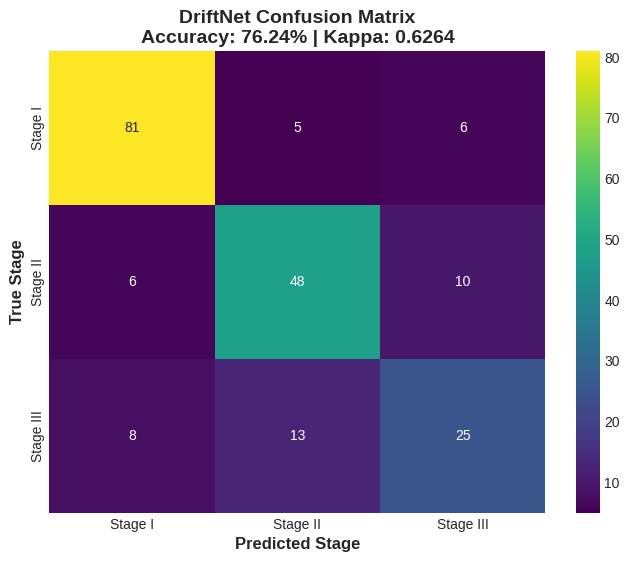

1/6: Confusion Matrix saved and displayed


In [14]:
cm = confusion_matrix(y_test, best_pred)
test_acc = accuracy_score(y_test, best_pred)
kappa = cohen_kappa_score(y_test, best_pred)

fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax1)

ax1.set_xlabel('Predicted Stage', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Stage', fontsize=12, fontweight='bold')
ax1.set_title(f'DriftNet Confusion Matrix\nAccuracy: {test_acc*100:.2f}% | Kappa: {kappa:.4f}',
              fontsize=14, fontweight='bold')

save_and_show(fig1, 'Confusion_Matrix')
print("1/6: Confusion Matrix saved and displayed")


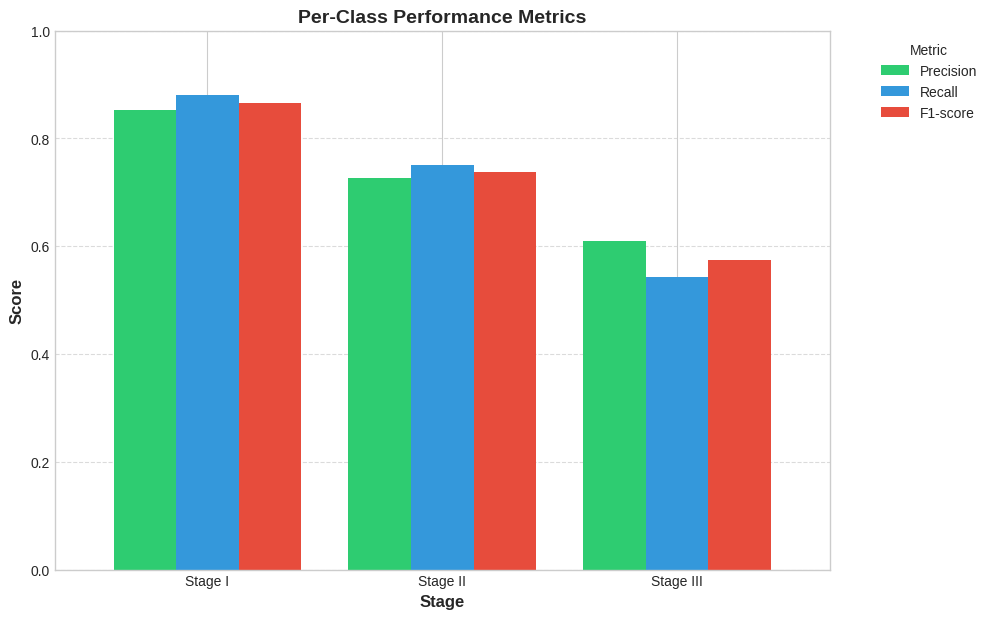

2/6: Performance Bars saved and displayed


In [15]:

report = classification_report(y_test, best_pred, target_names=stage_names, output_dict=True)

metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Stage I': [report['Stage I']['precision'], report['Stage I']['recall'], report['Stage I']['f1-score']],
    'Stage II': [report['Stage II']['precision'], report['Stage II']['recall'], report['Stage II']['f1-score']],
    'Stage III': [report['Stage III']['precision'], report['Stage III']['recall'], report['Stage III']['f1-score']]
}).set_index('Metric')

fig2, ax2 = plt.subplots(figsize=(10, 7))
metrics_df.T.plot(kind='bar', ax=ax2, width=0.8,
                  color=['#2ecc71', '#3498db', '#e74c3c'])

ax2.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Stage', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

save_and_show(fig2, 'Performance_Bars')
print("2/6: Performance Bars saved and displayed")


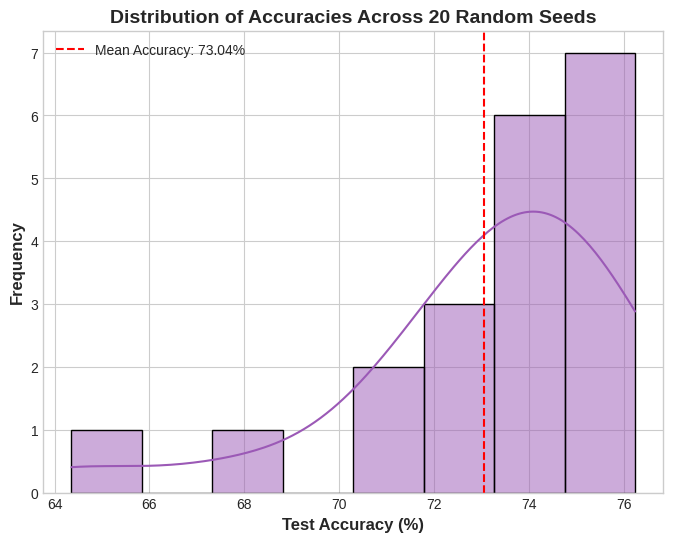

3/6: Accuracy Distribution saved and displayed


In [16]:

fig3, ax3 = plt.subplots(figsize=(8, 6))
sns.histplot(all_accuracies * 100, bins=8, kde=True,
             ax=ax3, color='#9b59b6', edgecolor='black')

ax3.set_title(f'Distribution of Accuracies Across {len(all_accuracies)} Random Seeds',
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.axvline(np.mean(all_accuracies) * 100, color='red', linestyle='--',
            label=f'Mean Accuracy: {np.mean(all_accuracies)*100:.2f}%')
ax3.legend()

save_and_show(fig3, 'Accuracy_Distribution')
print("3/6: Accuracy Distribution saved and displayed")


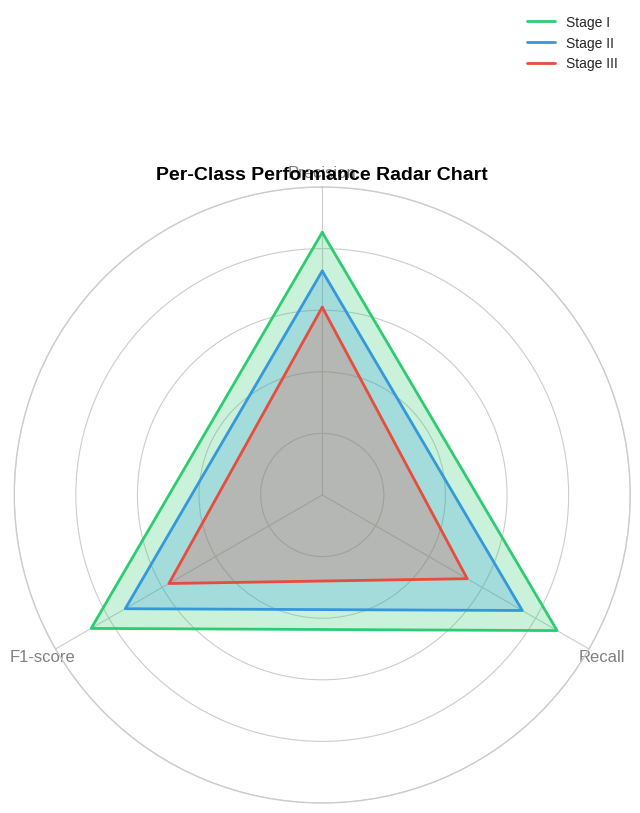

4/6: Radar Chart saved and displayed


In [17]:
fig4 = plt.figure(figsize=(8, 8))
ax4 = fig4.add_subplot(111, polar=True)

create_radar_chart(ax4, metrics_df, 'Per-Class Performance Radar Chart', stage_names)
ax4.legend(loc='upper right', bbox_to_anchor=(1.0, 1.3))

save_and_show(fig4, 'Radar_Chart')
print("4/6: Radar Chart saved and displayed")


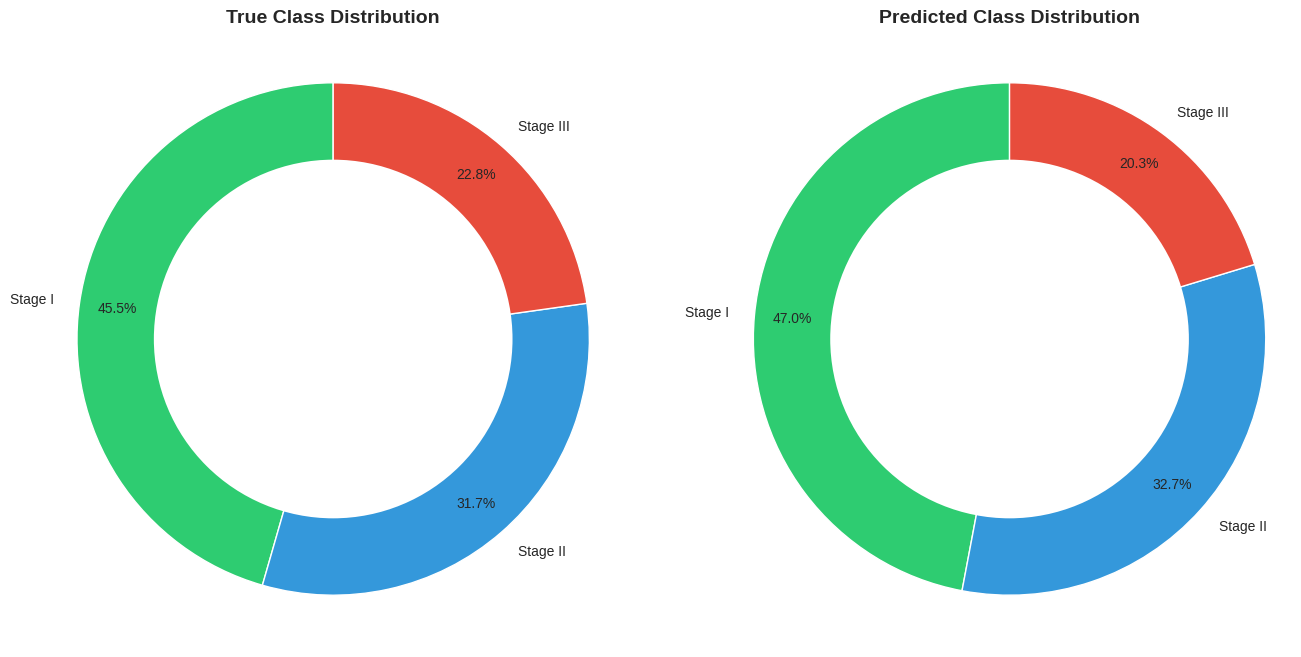

5/6: Donut Charts saved and displayed


In [18]:
true_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(best_pred).value_counts().sort_index()

fig5, (ax5_true, ax5_pred) = plt.subplots(1, 2, figsize=(16, 8))

ax5_true.pie(true_counts, labels=stage_names, autopct='%1.1f%%',
             startangle=90, colors=stage_colors,
             wedgeprops=dict(width=0.4, edgecolor='w'),
             pctdistance=0.85)
ax5_true.add_artist(plt.Circle((0,0),0.70,fc='white'))
ax5_true.set_title('True Class Distribution', fontsize=14, fontweight='bold')
ax5_true.axis('equal')

ax5_pred.pie(predicted_counts, labels=stage_names, autopct='%1.1f%%',
             startangle=90, colors=stage_colors,
             wedgeprops=dict(width=0.4, edgecolor='w'),
             pctdistance=0.85)
ax5_pred.add_artist(plt.Circle((0,0),0.70,fc='white'))
ax5_pred.set_title('Predicted Class Distribution', fontsize=14, fontweight='bold')
ax5_pred.axis('equal')

save_and_show(fig5, 'Donut_Charts')
print("5/6: Donut Charts saved and displayed")


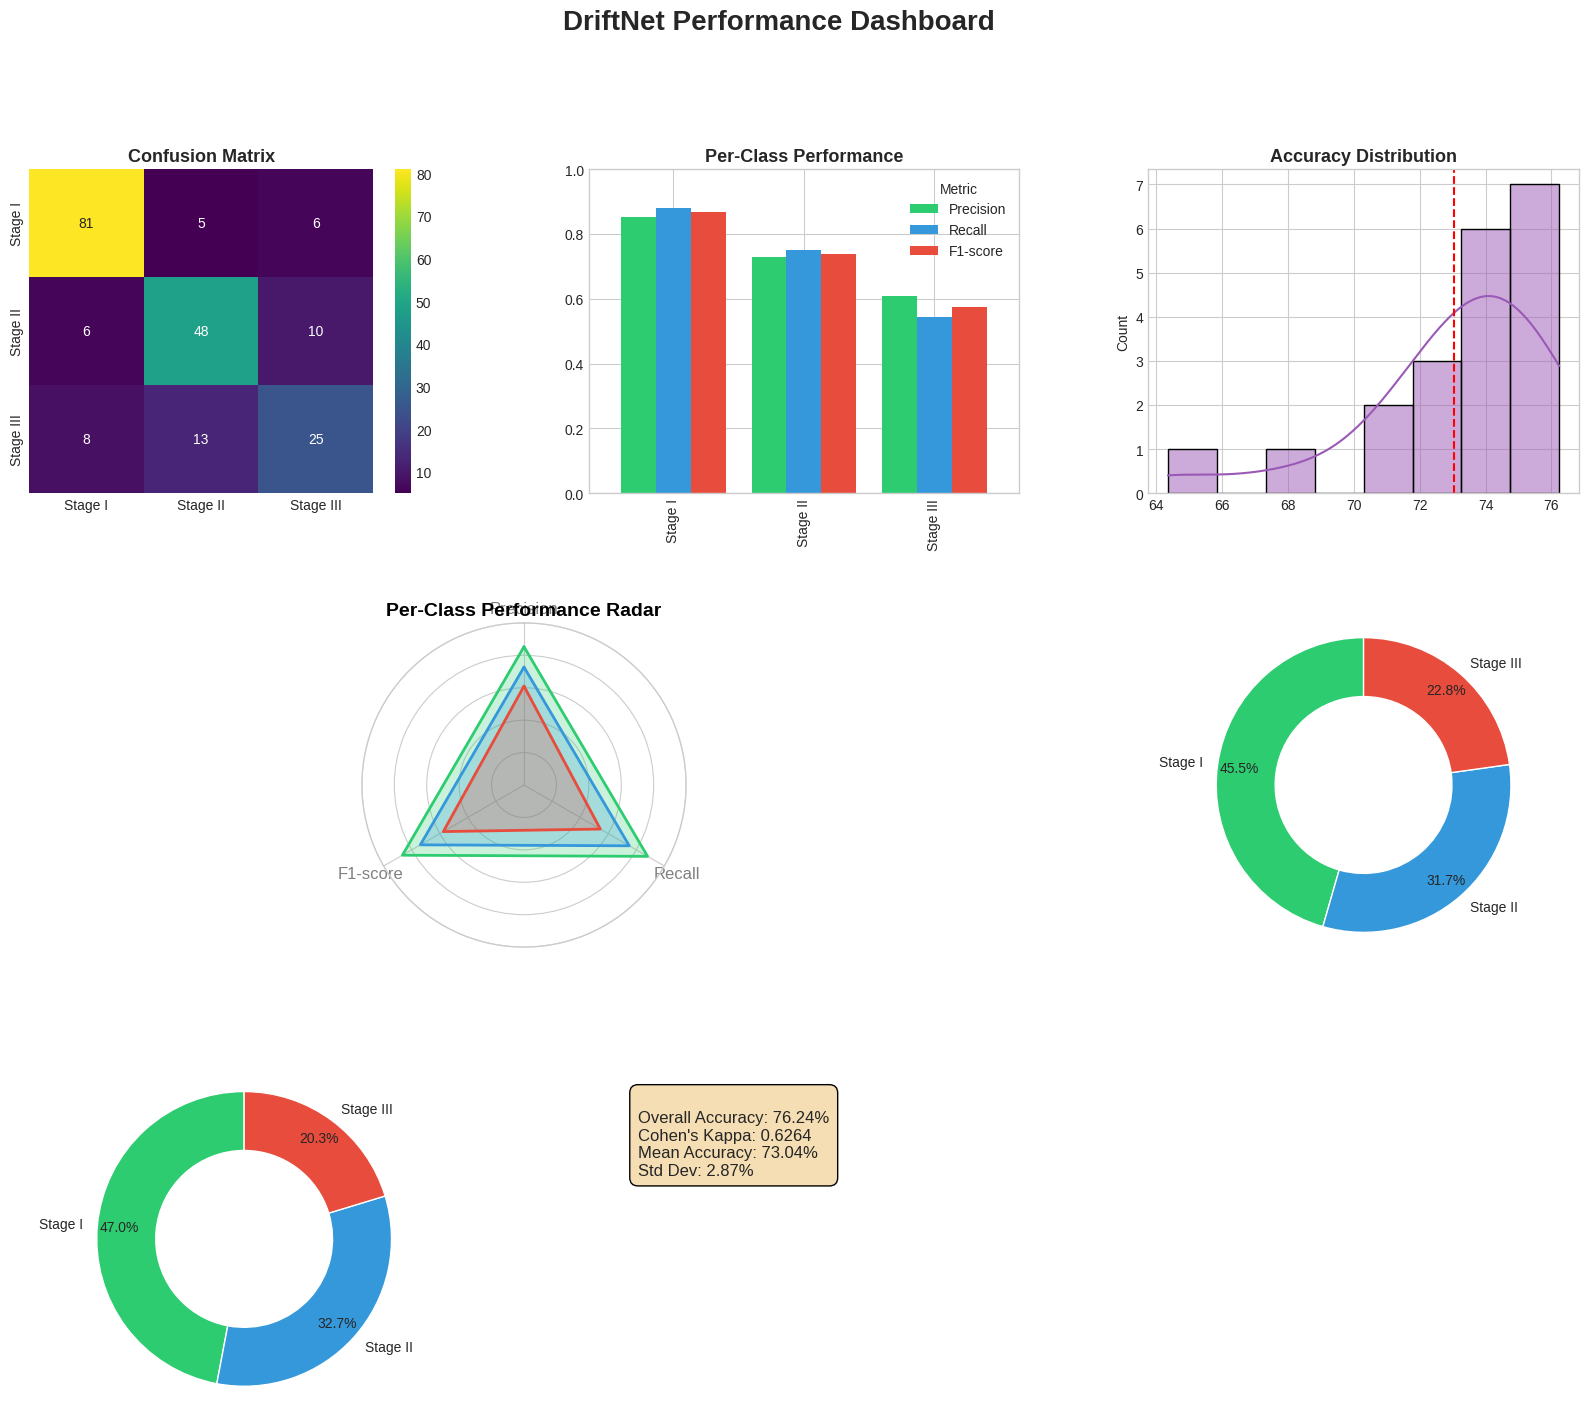

6/6: Complete Dashboard saved and displayed


In [19]:
fig6 = plt.figure(figsize=(20, 16))
gs = fig6.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

ax6_cm = fig6.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=stage_names, yticklabels=stage_names, ax=ax6_cm)
ax6_cm.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax6_bars = fig6.add_subplot(gs[0, 1])
metrics_df.T.plot(kind='bar', ax=ax6_bars, width=0.8,
                  color=['#2ecc71', '#3498db', '#e74c3c'])

ax6_bars.set_title('Per-Class Performance', fontsize=13, fontweight='bold')
ax6_bars.set_ylim(0, 1.0)

ax6_hist = fig6.add_subplot(gs[0, 2])
sns.histplot(all_accuracies * 100, bins=8, kde=True,
             ax=ax6_hist, color='#9b59b6')

ax6_hist.set_title('Accuracy Distribution', fontsize=13, fontweight='bold')
ax6_hist.axvline(np.mean(all_accuracies) * 100, color='red', linestyle='--')
ax6_radar = fig6.add_subplot(gs[1, 0:2], polar=True)
create_radar_chart(ax6_radar, metrics_df, 'Per-Class Performance Radar', stage_names)
ax6_true_donut = fig6.add_subplot(gs[1, 2])
ax6_true_donut.pie(true_counts, labels=stage_names, autopct='%1.1f%%',
                   startangle=90, colors=stage_colors,
                   wedgeprops=dict(width=0.4, edgecolor='w'),
                   pctdistance=0.85)
ax6_true_donut.axis('equal')

ax6_pred_donut = fig6.add_subplot(gs[2, 0])
ax6_pred_donut.pie(predicted_counts, labels=stage_names, autopct='%1.1f%%',
                   startangle=90, colors=stage_colors,
                   wedgeprops=dict(width=0.4, edgecolor='w'),
                   pctdistance=0.85)
ax6_pred_donut.axis('equal')

ax6_summary = fig6.add_subplot(gs[2, 1:])
ax6_summary.axis('off')
summary_text = f"""
Overall Accuracy: {test_acc*100:.2f}%
Cohen's Kappa: {kappa:.4f}
Mean Accuracy: {np.mean(all_accuracies)*100:.2f}%
Std Dev: {np.std(all_accuracies)*100:.2f}%"""

ax6_summary.text(0.05, 0.95, summary_text,
                 fontsize=12, transform=ax6_summary.transAxes,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.5', fc='wheat'))

plt.suptitle('DriftNet Performance Dashboard',
             fontsize=20, fontweight='bold', y=0.98)

save_and_show(fig6, 'Complete_Dashboard')
print("6/6: Complete Dashboard saved and displayed")


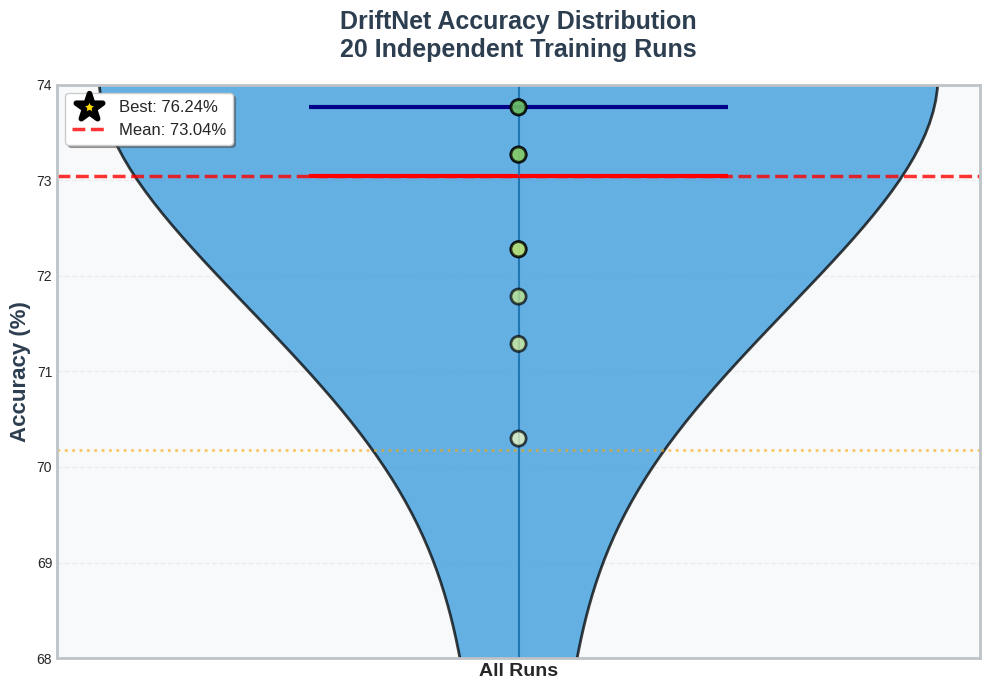

Accuracy Distribution saved and displayed



In [20]:

accuracies_percent = all_accuracies * 100
mean_acc_percent = np.mean(accuracies_percent)
std_acc_percent = np.std(accuracies_percent)

fig, ax = plt.subplots(figsize=(10, 7))

parts = ax.violinplot([accuracies_percent], positions=[1], widths=0.7,
                       showmeans=True, showmedians=True, showextrema=True)

for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.75)
    pc.set_edgecolor('black')
    pc.set_linewidth(2)

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(3)
parts['cmedians'].set_color('darkblue')
parts['cmedians'].set_linewidth(3)

ax.scatter([1]*len(accuracies_percent), accuracies_percent, alpha=0.7, s=120,
           c=accuracies_percent, cmap='RdYlGn', edgecolors='black', linewidth=2, zorder=3)

best_idx = np.argmax(accuracies_percent)
ax.scatter(1, accuracies_percent[best_idx], s=400, c='gold', edgecolors='black',
           linewidth=4, marker='*', zorder=4, label=f'Best: {accuracies_percent[best_idx]:.2f}%')

ax.axhline(mean_acc_percent, color='red', linestyle='--', linewidth=2.5, alpha=0.8,
           label=f'Mean: {mean_acc_percent:.2f}%')
ax.axhline(mean_acc_percent + std_acc_percent, color='orange', linestyle=':', linewidth=2, alpha=0.6)
ax.axhline(mean_acc_percent - std_acc_percent, color='orange', linestyle=':', linewidth=2, alpha=0.6)

ax.set_ylabel('Accuracy (%)', fontsize=16, fontweight='bold', color='#2c3e50')
ax.set_title('DriftNet Accuracy Distribution\n20 Independent Training Runs',
             fontsize=18, fontweight='bold', pad=20, color='#2c3e50')
ax.set_xticks([1])
ax.set_xticklabels(['All Runs'], fontsize=14, fontweight='bold')
ax.set_ylim([68, 74])
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True, fancybox=True)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax.set_facecolor('#f8f9fa')

for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(2)

fig.patch.set_facecolor('white')
plt.tight_layout()

plt.savefig(f'{save_dir}Fig3_AccuracyDistribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_dir}Fig3_AccuracyDistribution.pdf', bbox_inches='tight', facecolor='white')
plt.show()
print("Accuracy Distribution saved and displayed\n")

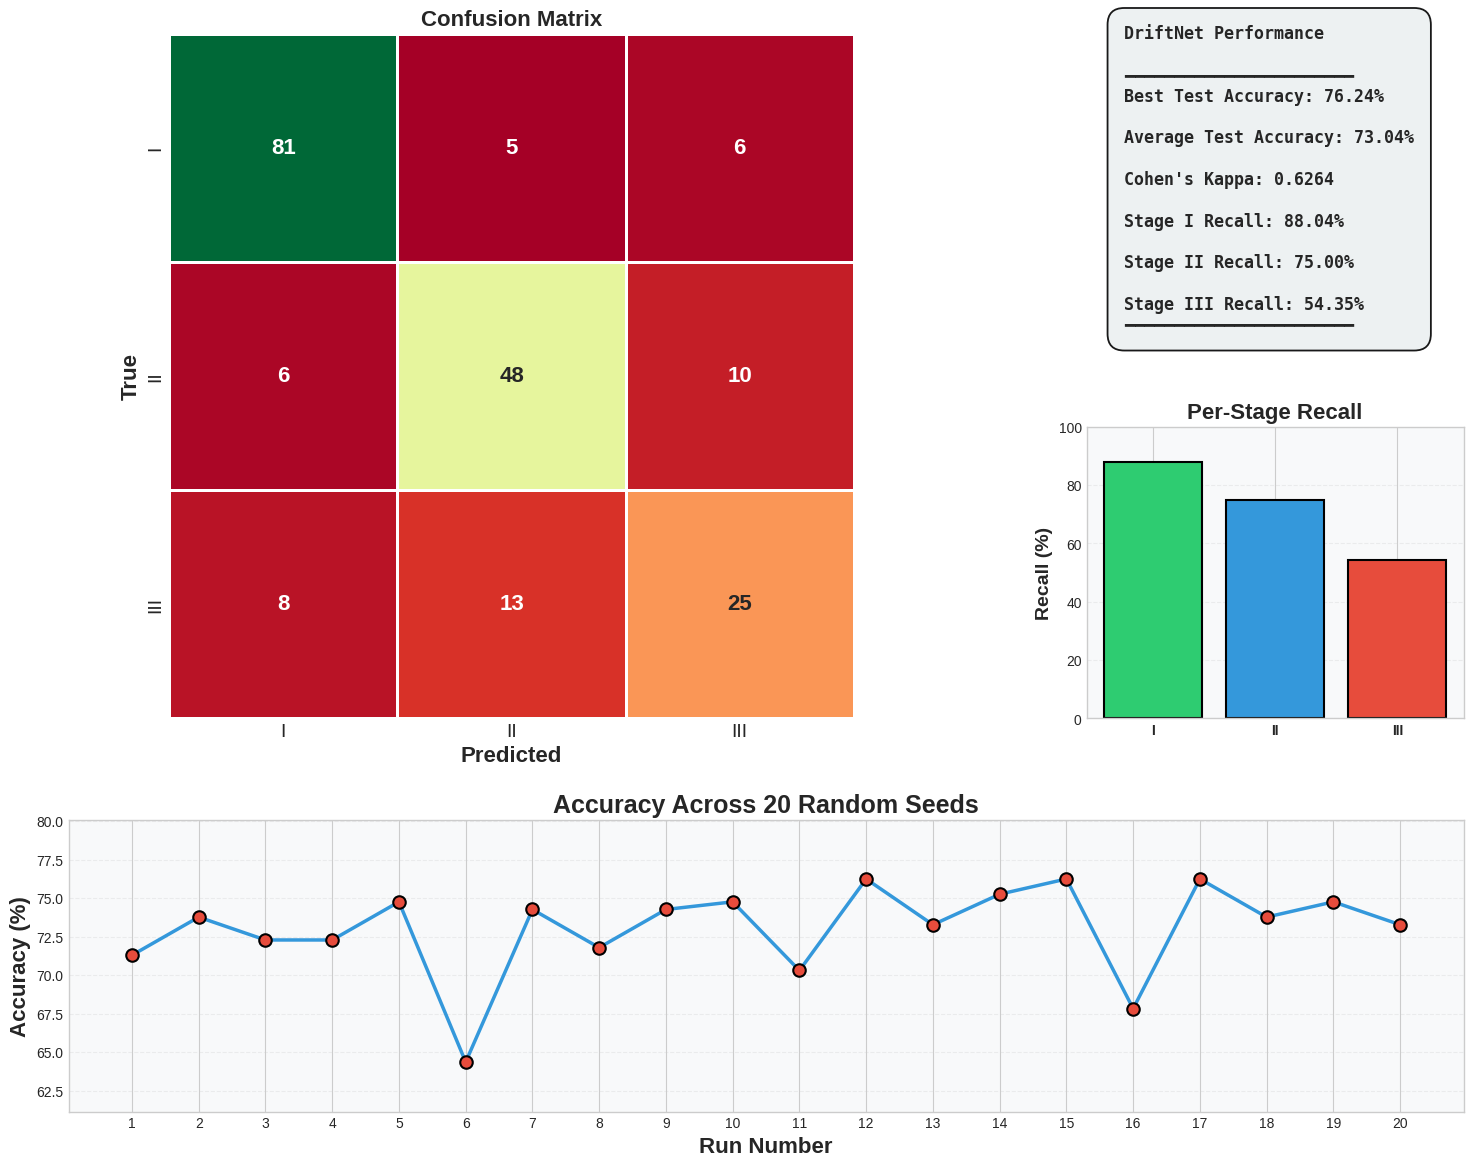

Combined Dashboard saved and displayed


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score
import os

save_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/'

best_pred_df = pd.read_csv(f'{save_dir}predictions.csv')
y_test = best_pred_df['True'].values
best_pred = best_pred_df['Predicted'].values

all_results_df = pd.read_csv(f'{save_dir}auto_seeds_results.csv')
all_accuracies = all_results_df['accuracy'].values
accuracies_percent = all_accuracies * 100

cm = confusion_matrix(y_test, best_pred)
test_acc = accuracy_score(y_test, best_pred)
kappa = cohen_kappa_score(y_test, best_pred)

stage_names = ['Stage I', 'Stage II', 'Stage III']

recalls = []
for i in range(len(stage_names)):
    recall = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    recalls.append(recall * 100)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# Confusion Matrix
ax1 = fig.add_subplot(gs[0:2, 0:2])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            linewidths=2, linecolor='white', square=True,
            annot_kws={'size': 16, 'weight': 'bold'}, ax=ax1, cbar=False)
ax1.set_xlabel('Predicted', fontweight='bold', fontsize=16)
ax1.set_ylabel('True', fontweight='bold', fontsize=16)
ax1.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
ax1.set_xticklabels(['I', 'II', 'III'], fontsize=14)
ax1.set_yticklabels(['I', 'II', 'III'], fontsize=14)

# Metrics Box
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
mean_acc_percent = np.mean(all_accuracies) * 100
summary_text = f"DriftNet Performance\n\n━━━━━━━━━━━━━━━━━━━━━━━\nBest Test Accuracy: {test_acc*100:.2f}%\n\nAverage Test Accuracy: {mean_acc_percent:.2f}%\n\nCohen's Kappa: {kappa:.4f}\n\nStage I Recall: {recalls[0]:.2f}%\n\nStage II Recall: {recalls[1]:.2f}%\n\nStage III Recall: {recalls[2]:.2f}%\n━━━━━━━━━━━━━━━━━━━━━━━"
ax2.text(0.1, 0.5, summary_text, fontsize=12, fontfamily='monospace', fontweight='bold',
         bbox=dict(boxstyle='round,pad=1', facecolor='#ecf0f1', alpha=0.9, edgecolor='black', linewidth=1.3),
         verticalalignment='center')

# Per-Stage Bars
ax3 = fig.add_subplot(gs[1, 2])
ax3.bar(range(3), recalls, color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(3))
ax3.set_xticklabels(['I', 'II', 'III'], fontweight='bold')
ax3.set_ylabel('Recall (%)', fontweight='bold', fontsize=14)
ax3.set_title('Per-Stage Recall', fontsize=16, fontweight='bold')
ax3.set_ylim([0, 100])
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_facecolor('#f8f9fa')

# Accuracy Timeline
ax4 = fig.add_subplot(gs[2, :])
ax4.plot(range(1, len(accuracies_percent) + 1), accuracies_percent, marker='o', linewidth=2.5, markersize=9,
         color='#3498db', markerfacecolor='#e74c3c', markeredgecolor='black', markeredgewidth=1.5)
ax4.set_xlabel('Run Number', fontweight='bold', fontsize=16)
ax4.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=16)
ax4.set_title('Accuracy Across 20 Random Seeds', fontsize=18, fontweight='bold')
ax4.set_xticks(range(1, len(accuracies_percent) + 1))
ax4.set_ylim(min(accuracies_percent) * 0.95, max(accuracies_percent) * 1.05)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_facecolor('#f8f9fa')

fig.patch.set_facecolor('white')
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(f'{save_dir}DriftNet_Combined_Dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_dir}DriftNet_Combined_Dashboard.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Combined Dashboard saved and displayed")

Generating ROC curves for the validation set (Best Model)...


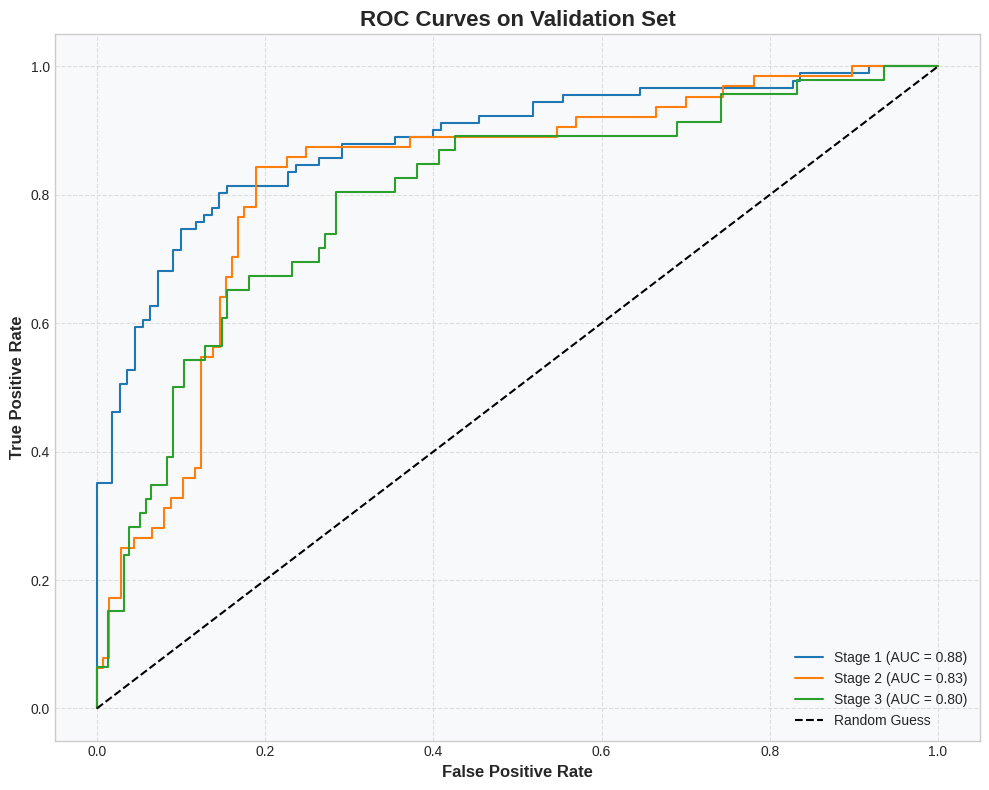

ROC curves generated and saved for the Best Model.


In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("Generating ROC curves for the validation set (Best Model)...")

y_pred_proba = best_model.predict([X_cont_val, X_clin_val], verbose=0)

y_val_binarized = label_binarize(y_val, classes=[0, 1, 2])
n_classes = y_val_binarized.shape[1]

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Stage {i+1} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves on Validation Set', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/ROC_Validation_Best_Model_60_20_20.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curves generated and saved for the Best Model.")

Generating Combined ROC + Accuracy Figure...


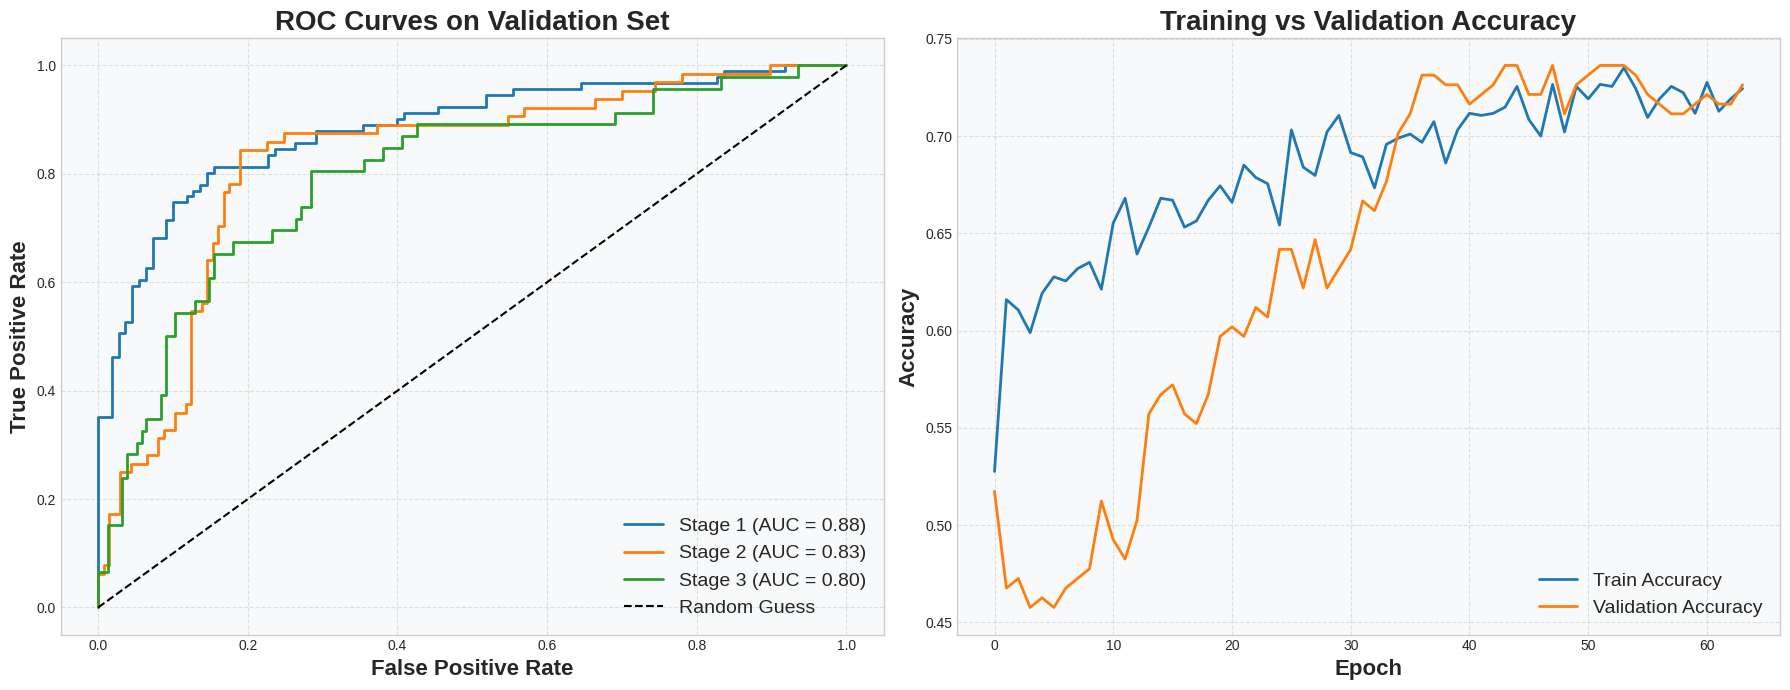

Combined ROC + Accuracy figure generated and saved!


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("Generating Combined ROC + Accuracy Figure...")

y_pred_proba = best_model.predict([X_cont_val, X_clin_val], verbose=0)
y_val_binarized = label_binarize(y_val, classes=[0, 1, 2])
n_classes = y_val_binarized.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'Stage {i+1} (AUC = {roc_auc:.2f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess')

ax.set_xlabel('False Positive Rate', fontsize=16, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=16, fontweight='bold')
ax.set_title('ROC Curves on Validation Set', fontsize=20, fontweight='bold')
ax.legend(loc='lower right', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_facecolor('#f8f9fa')

ax = axes[1]

ax.plot(best_history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax.plot(best_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

ax.set_title('Training vs Validation Accuracy', fontsize=20, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=16, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_facecolor('#f8f9fa')

fig.patch.set_facecolor('white')
plt.tight_layout()

save_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/'
plt.savefig(f'{save_path}Combined_ROC_Accuracy.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_path}Combined_ROC_Accuracy.pdf', bbox_inches='tight')

plt.show()

print("Combined ROC + Accuracy figure generated and saved!")


Generating Learning Curves (Best Model)...


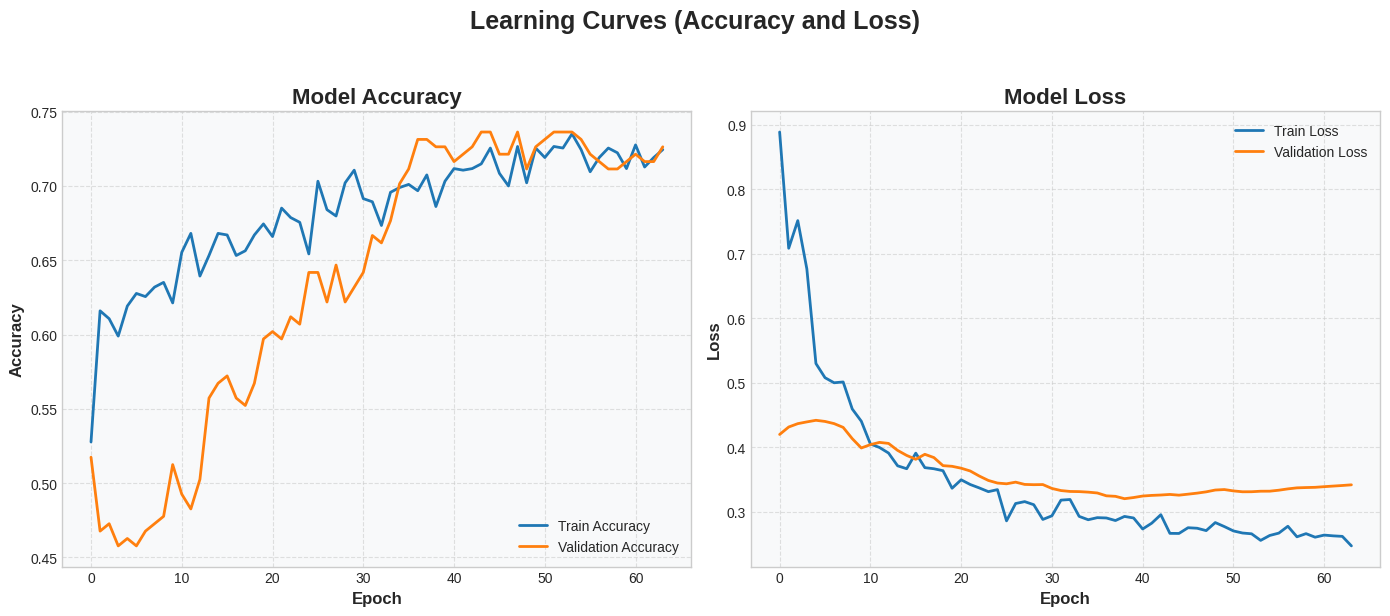

Learning curves generated and saved for the Best Model.


In [24]:
import matplotlib.pyplot as plt

print("Generating Learning Curves (Best Model)...")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_facecolor('#f8f9fa')

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(best_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_facecolor('#f8f9fa')

plt.suptitle('Learning Curves (Accuracy and Loss)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Learning_Curves_Best_Model_60_20_20.png', dpi=300, bbox_inches='tight')
plt.show()

print("Learning curves generated and saved for the Best Model.")

Generating ROC curves and Learning Curves (Best Model)...


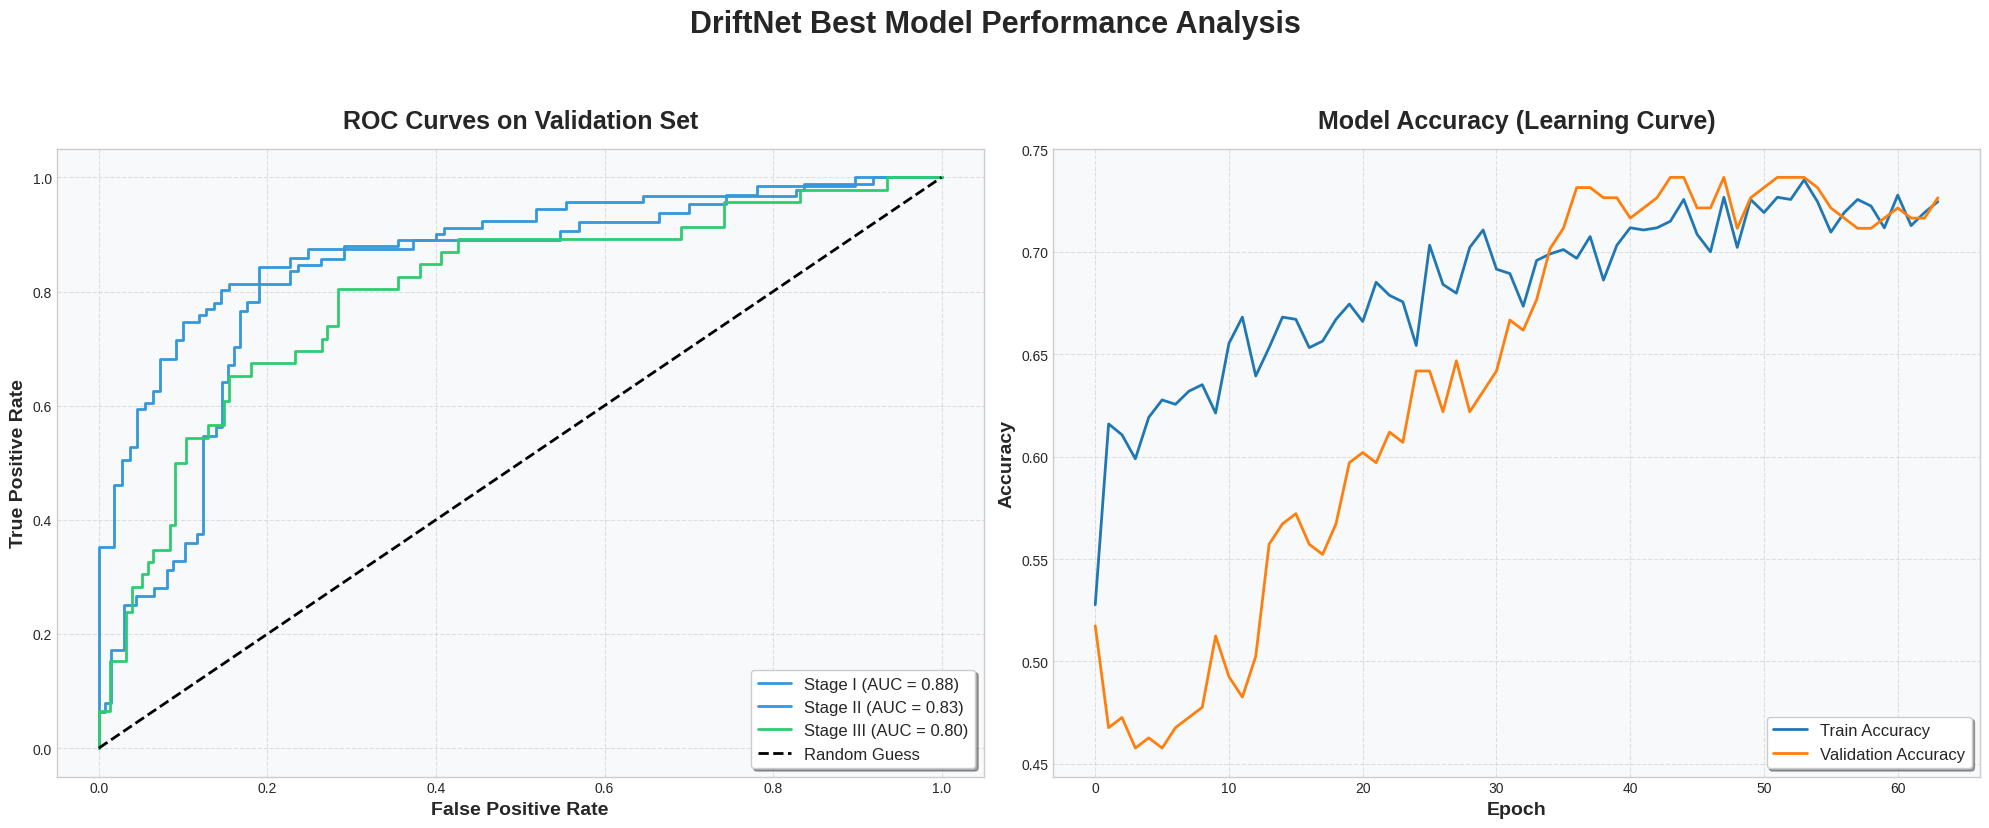

Combined ROC and Learning Curves generated and saved for the Best Model.


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("Generating ROC curves and Learning Curves (Best Model)...")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_proba = best_model.predict([X_cont_val, X_clin_val], verbose=0)

y_val_binarized = label_binarize(y_val, classes=[0, 1, 2])
n_classes = y_val_binarized.shape[1]

colors = ['#3498db', '#3498db', '#2ecc71']
stage_labels = ['Stage I', 'Stage II', 'Stage III']

ax_roc = axes[0]
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2, label=f'{stage_labels[i]} (AUC = {roc_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
ax_roc.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
ax_roc.set_title('ROC Curves on Validation Set', fontsize=18, fontweight='bold', pad=15)
ax_roc.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
ax_roc.grid(True, linestyle='--', alpha=0.6)
ax_roc.set_facecolor('#f8f9fa')

ax_learning = axes[1]
ax_learning.plot(best_history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#1f77b4')
ax_learning.plot(best_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#ff7f0e')
ax_learning.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax_learning.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax_learning.set_title('Model Accuracy (Learning Curve)', fontsize=18, fontweight='bold', pad=15)
ax_learning.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
ax_learning.grid(True, linestyle='--', alpha=0.6)
ax_learning.set_facecolor('#f8f9fa')

plt.suptitle('DriftNet Best Model Performance Analysis', fontsize=22, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])

save_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/'
plt.savefig(f'{save_path}ROC_and_Learning_Curves_Best_Model.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}ROC_and_Learning_Curves_Best_Model.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Combined ROC and Learning Curves generated and saved for the Best Model.")

Generating ROC curves and Learning Curves (Best Model)...


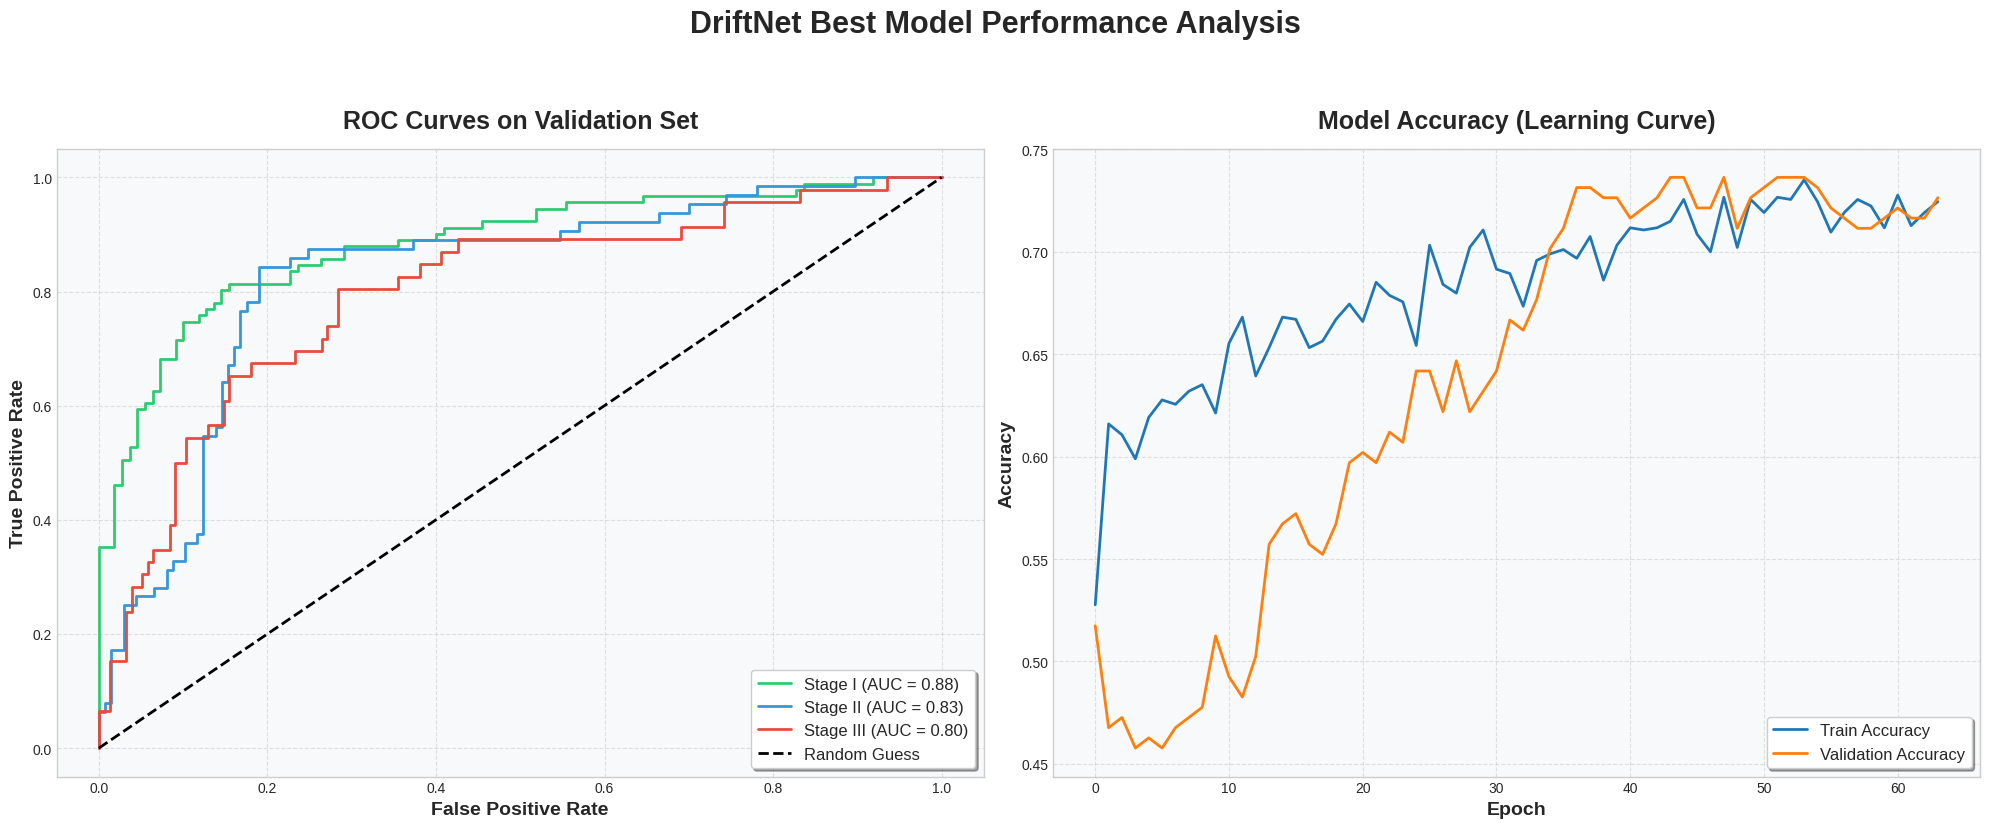

Combined ROC and Learning Curves generated and saved for the Best Model.


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("Generating ROC curves and Learning Curves (Best Model)...")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

y_pred_proba = best_model.predict([X_cont_val, X_clin_val], verbose=0)

y_val_binarized = label_binarize(y_val, classes=[0, 1, 2])
n_classes = y_val_binarized.shape[1]

colors = ['#2ecc71', '#3498db', '#e74c3c']
stage_labels = ['Stage I', 'Stage II', 'Stage III']

ax_roc = axes[0]
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_val_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2, label=f'{stage_labels[i]} (AUC = {roc_auc:.2f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
ax_roc.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
ax_roc.set_title('ROC Curves on Validation Set', fontsize=18, fontweight='bold', pad=15)
ax_roc.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
ax_roc.grid(True, linestyle='--', alpha=0.6)
ax_roc.set_facecolor('#f8f9fa')

ax_learning = axes[1]
ax_learning.plot(best_history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#1f77b4')
ax_learning.plot(best_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#ff7f0e')
ax_learning.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax_learning.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax_learning.set_title('Model Accuracy (Learning Curve)', fontsize=18, fontweight='bold', pad=15)
ax_learning.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
ax_learning.grid(True, linestyle='--', alpha=0.6)
ax_learning.set_facecolor('#f8f9fa')

plt.suptitle('DriftNet Best Model Performance Analysis', fontsize=22, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])

save_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/'
plt.savefig(f'{save_path}ROC_and_Learning_Curves_Best_Model.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_path}ROC_and_Learning_Curves_Best_Model.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Combined ROC and Learning Curves generated and saved for the Best Model.")

## Cross-Validation Setup


In [27]:
print("\n[STEP 1] Loading preprocessed data...")
X_contrastive = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/X_contrastive.npy')
X_clinical = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/X_clinical.npy')
y = np.load('/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/y.npy')

print(f"   X_contrastive shape: {X_contrastive.shape}")
print(f"   X_clinical shape: {X_clinical.shape}")
print(f"   y shape: {y.shape}")


[STEP 1] Loading preprocessed data...
   X_contrastive shape: (1343, 128)
   X_clinical shape: (1343, 13)
   y shape: (1343,)


In [28]:
print("\n[STEP 2] Scaling clinical features and setting up StratifiedKFold...")

from sklearn.preprocessing import StandardScaler
import joblib # Added import for joblib

driftnet_clin_scaler = StandardScaler() # Renamed scaler for clarity
X_clin_scaled = driftnet_clin_scaler.fit_transform(X_clinical).astype(np.float32)
joblib.dump(driftnet_clin_scaler, '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Contrastive_Learning/driftnet_clinical_scaler.pkl') # Saved driftnet_clinical_scaler
print(f"   X_clinical scaled shape: {X_clin_scaled.shape}")

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"   StratifiedKFold initialized with {skf.get_n_splits(X_contrastive, y)} splits.")

print("\n[STEP 3] Confirming split details for each StratifiedKFold...")

for fold, (train_index, test_index) in enumerate(skf.split(X_contrastive, y)):
    print(f"\n--- Fold {fold + 1}/{skf.get_n_splits(X_contrastive, y)} ---")
    print(f"   Train indices shape: {train_index.shape}")
    print(f"   Test indices shape: {test_index.shape}")
    print(f"   Train samples: {len(train_index)}")
    print(f"   Test samples: {len(test_index)}")

    unique_train, counts_train = np.unique(y[train_index], return_counts=True)
    unique_test, counts_test = np.unique(y[test_index], return_counts=True)
    print(f"   Train class distribution: {dict(zip(unique_train, counts_train))}")
    print(f"   Test class distribution: {dict(zip(unique_test, counts_test))}")

print("\n[STEP 4] Preparing data splits and calculating class weights for each fold...")

fold_accuracies = []
fold_classification_reports = []
fold_confusion_matrices = []

for fold, (train_index, test_index) in enumerate(skf.split(X_contrastive, y)):
    print(f"\n--- Processing Fold {fold + 1}/{skf.get_n_splits(X_contrastive, y)} ---")

    X_cont_train = X_contrastive[train_index]
    X_cont_test = X_contrastive[test_index]

    X_clin_train = X_clin_scaled[train_index]
    X_clin_test = X_clin_scaled[test_index]

    y_train = y[train_index]
    y_test = y[test_index]

    from sklearn.utils import compute_class_weight
    class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = {i: w for i, w in enumerate(class_weights_array)}

    print(f"   X_contrastive train shape: {X_cont_train.shape}")
    print(f"   X_contrastive test shape: {X_cont_test.shape}")
    print(f"   X_clinical train shape: {X_clin_train.shape}")
    print(f"   X_clinical test shape: {X_clin_test.shape}")
    print(f"   y_train shape: {y_train.shape}")
    print(f"   y_test shape: {y_test.shape}")
    print(f"   Class weights for current fold: {class_weights}")



[STEP 2] Scaling clinical features and setting up StratifiedKFold...
   X_clinical scaled shape: (1343, 13)
   StratifiedKFold initialized with 5 splits.

[STEP 3] Confirming split details for each StratifiedKFold...

--- Fold 1/5 ---
   Train indices shape: (1074,)
   Test indices shape: (269,)
   Train samples: 1074
   Test samples: 269
   Train class distribution: {np.int64(0): np.int64(488), np.int64(1): np.int64(340), np.int64(2): np.int64(246)}
   Test class distribution: {np.int64(0): np.int64(122), np.int64(1): np.int64(86), np.int64(2): np.int64(61)}

--- Fold 2/5 ---
   Train indices shape: (1074,)
   Test indices shape: (269,)
   Train samples: 1074
   Test samples: 269
   Train class distribution: {np.int64(0): np.int64(488), np.int64(1): np.int64(341), np.int64(2): np.int64(245)}
   Test class distribution: {np.int64(0): np.int64(122), np.int64(1): np.int64(85), np.int64(2): np.int64(62)}

--- Fold 3/5 ---
   Train indices shape: (1074,)
   Test indices shape: (269,)
   T

In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

def build_best_driftnet(cont_dim=128, clin_dim=13):
    cont_input = keras.Input(shape=(cont_dim,))
    clin_input = keras.Input(shape=(clin_dim,))

    m = layers.Dense(256, activation='relu')(cont_input)
    m = layers.BatchNormalization()(m)
    m = layers.Dropout(0.3)(m)

    m = layers.Dense(128, activation='relu')(m)
    m = layers.BatchNormalization()(m)
    m = layers.Dropout(0.25)(m)

    m = layers.Dense(64, activation='relu')(m)

    c = layers.Dense(32, activation='relu')(clin_input)
    c = layers.BatchNormalization()(c)
    c = layers.Dropout(0.2)(c)

    c = layers.Dense(16, activation='relu')(c)

    merged = layers.Concatenate()([m, c])

    x = layers.Dense(64, activation='relu')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    return keras.Model(inputs=[cont_input, clin_input], outputs=outputs)

def simple_focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        y_true_onehot = tf.one_hot(y_true_int, 3)

        epsilon = 1e-7
        y_pred_clip = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        ce = -y_true_onehot * tf.math.log(y_pred_clip)
        focal_weight = tf.pow(1.0 - y_pred_clip, gamma)

        return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))

    return loss_fn

fold_accuracies = []
fold_classification_reports = []
fold_confusion_matrices = []

stage_names = ['Stage I', 'Stage II', 'Stage III']

print("\n[STEP 4 cont.] Training models and evaluating across folds...")

for fold, (train_index, test_index) in enumerate(skf.split(X_contrastive, y)):
    print(f"\n--- Training Fold {fold + 1}/{skf.get_n_splits(X_contrastive, y)} ---")

    X_cont_train = X_contrastive[train_index]
    X_cont_test = X_contrastive[test_index]

    X_clin_train = X_clin_scaled[train_index]
    X_clin_test = X_clin_scaled[test_index]

    y_train = y[train_index]
    y_test = y[test_index]

    class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = {i: w for i, w in enumerate(class_weights_array)}

    model = build_best_driftnet(X_contrastive.shape[1], X_clin_scaled.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=simple_focal_loss(gamma=2.0),
        metrics=['accuracy']
    )
    print(f"   Model parameters for Fold {fold + 1}: {model.count_params():,}")

    history = model.fit(
        [X_cont_train, X_clin_train], y_train,
        validation_data=([X_cont_test, X_clin_test], y_test),
        class_weight=class_weights,
        epochs=100,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=20,
                restore_best_weights=True,
                mode='max',
                verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=10,
                min_lr=1e-6,
                verbose=0
            )
        ],
        verbose=0
    )
    print(f"   Model training complete for Fold {fold + 1}")

    y_pred = np.argmax(model.predict([X_cont_test, X_clin_test], verbose=0), axis=1)
    test_accuracy = accuracy_score(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred, target_names=stage_names, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    fold_accuracies.append(test_accuracy)
    fold_classification_reports.append(classification_rep)
    fold_confusion_matrices.append(conf_matrix)

print("\n[STEP 5] All models trained across all folds.")


[STEP 4 cont.] Training models and evaluating across folds...

--- Training Fold 1/5 ---
   Model parameters for Fold 1: 84,435
   Model training complete for Fold 1

--- Training Fold 2/5 ---
   Model parameters for Fold 2: 84,435
   Model training complete for Fold 2

--- Training Fold 3/5 ---
   Model parameters for Fold 3: 84,435
   Model training complete for Fold 3

--- Training Fold 4/5 ---
   Model parameters for Fold 4: 84,435
   Model training complete for Fold 4

--- Training Fold 5/5 ---
   Model parameters for Fold 5: 84,435
   Model training complete for Fold 5

[STEP 5] All models trained across all folds.


In [30]:
print("\n[STEP 6] Evaluating models and storing results for each fold...")

fold_accuracies = []
fold_classification_reports = []
fold_confusion_matrices = []

stage_names = ['Stage I', 'Stage II', 'Stage III']

for fold, (train_index, test_index) in enumerate(skf.split(X_contrastive, y)):
    print(f"\n--- Evaluating Fold {fold + 1}/{skf.get_n_splits(X_contrastive, y)} ---")

    X_cont_train = X_contrastive[train_index]
    X_cont_test = X_contrastive[test_index]

    X_clin_train = X_clin_scaled[train_index]
    X_clin_test = X_clin_scaled[test_index]

    y_train = y[train_index]
    y_test = y[test_index]

    class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights = {i: w for i, w in enumerate(class_weights_array)}

    model = build_best_driftnet(X_contrastive.shape[1], X_clin_scaled.shape[1])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=simple_focal_loss(gamma=2.0),
        metrics=['accuracy']
    )
    _ = model.fit(
        [X_cont_train, X_clin_train], y_train,
        validation_data=([X_cont_test, X_clin_test], y_test),
        class_weight=class_weights,
        epochs=100,
        batch_size=64,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max', verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0
            )
        ],
        verbose=0
    )

    y_pred = np.argmax(model.predict([X_cont_test, X_clin_test], verbose=0), axis=1)
    test_accuracy = accuracy_score(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred, target_names=stage_names, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    fold_accuracies.append(test_accuracy)
    fold_classification_reports.append(classification_rep)
    fold_confusion_matrices.append(conf_matrix)

    print(f"   Fold {fold + 1} Accuracy: {test_accuracy*100:.2f}%")
    print(f"   Confusion Matrix for Fold {fold + 1}:\n{conf_matrix}")

print("\n[STEP 7] All folds evaluated. Aggregating results...")

mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

aggregated_report = {
    'Stage I': {'precision': [], 'recall': [], 'f1-score': []},
    'Stage II': {'precision': [], 'recall': [], 'f1-score': []},
    'Stage III': {'precision': [], 'recall': [], 'f1-score': []},
    'accuracy': [],
    'macro avg': {'precision': [], 'recall': [], 'f1-score': []},
    'weighted avg': {'precision': [], 'recall': [], 'f1-score': []}
}

for report in fold_classification_reports:
    for stage in stage_names:
        aggregated_report[stage]['precision'].append(report[stage]['precision'])
        aggregated_report[stage]['recall'].append(report[stage]['recall'])
        aggregated_report[stage]['f1-score'].append(report[stage]['f1-score'])
    aggregated_report['accuracy'].append(report['accuracy'])
    aggregated_report['macro avg']['precision'].append(report['macro avg']['precision'])
    aggregated_report['macro avg']['recall'].append(report['macro avg']['recall'])
    aggregated_report['macro avg']['f1-score'].append(report['macro avg']['f1-score'])
    aggregated_report['weighted avg']['precision'].append(report['weighted avg']['precision'])
    aggregated_report['weighted avg']['recall'].append(report['weighted avg']['recall'])
    aggregated_report['weighted avg']['f1-score'].append(report['weighted avg']['f1-score'])

for key, value in aggregated_report.items():
    if isinstance(value, dict):
        for sub_key, sub_value in value.items():
            aggregated_report[key][sub_key] = np.mean(sub_value)
    else:
        aggregated_report[key] = np.mean(value)

sum_confusion_matrix = np.sum(fold_confusion_matrices, axis=0)

print(" OVERALL CROSS-VALIDATION RESULTS")
print(f"\nAverage Test Accuracy: {mean_accuracy*100:.2f}% (+/- {std_accuracy*100:.2f}%")
print("\nAggregated Classification Report:")

report_str = ""
for stage in stage_names:
    report_str += f"   {stage}:\n"
    report_str += f"     Precision: {aggregated_report[stage]['precision']:.4f}\n"
    report_str += f"     Recall: {aggregated_report[stage]['recall']:.4f}\n"
    report_str += f"     F1-score: {aggregated_report[stage]['f1-score']:.4f}\n"
report_str += f"\n   Accuracy: {aggregated_report['accuracy']:.4f}\n"
report_str += f"   Macro Avg:\n"
report_str += f"     Precision: {aggregated_report['macro avg']['precision']:.4f}\n"
report_str += f"     Recall: {aggregated_report['macro avg']['recall']:.4f}\n"
report_str += f"     F1-score: {aggregated_report['macro avg']['f1-score']:.4f}\n"
report_str += f"   Weighted Avg:\n"
report_str += f"     Precision: {aggregated_report['weighted avg']['precision']:.4f}\n"
report_str += f"     Recall: {aggregated_report['weighted avg']['recall']:.4f}\n"
report_str += f"     F1-score: {aggregated_report['weighted avg']['f1-score']:.4f}\n"
print(report_str)

print("\nAggregated Confusion Matrix:")
print(sum_confusion_matrix)



[STEP 6] Evaluating models and storing results for each fold...

--- Evaluating Fold 1/5 ---
   Fold 1 Accuracy: 71.00%
   Confusion Matrix for Fold 1:
[[98 13 11]
 [15 61 10]
 [16 13 32]]

--- Evaluating Fold 2/5 ---
   Fold 2 Accuracy: 74.72%
   Confusion Matrix for Fold 2:
[[95 12 15]
 [ 6 67 12]
 [ 9 14 39]]

--- Evaluating Fold 3/5 ---
   Fold 3 Accuracy: 72.86%
   Confusion Matrix for Fold 3:
[[102  15   5]
 [ 11  65   9]
 [ 12  21  29]]

--- Evaluating Fold 4/5 ---
   Fold 4 Accuracy: 76.49%
   Confusion Matrix for Fold 4:
[[103  10   9]
 [ 12  65   8]
 [ 10  14  37]]

--- Evaluating Fold 5/5 ---
   Fold 5 Accuracy: 70.52%
   Confusion Matrix for Fold 5:
[[92 22  8]
 [ 7 69  9]
 [ 8 25 28]]

[STEP 7] All folds evaluated. Aggregating results...
 OVERALL CROSS-VALIDATION RESULTS

Average Test Accuracy: 73.12% (+/- 2.25%

Aggregated Classification Report:
   Stage I:
     Precision: 0.8246
     Recall: 0.8033
     F1-score: 0.8127
   Stage II:
     Precision: 0.6781
     Recall: 0

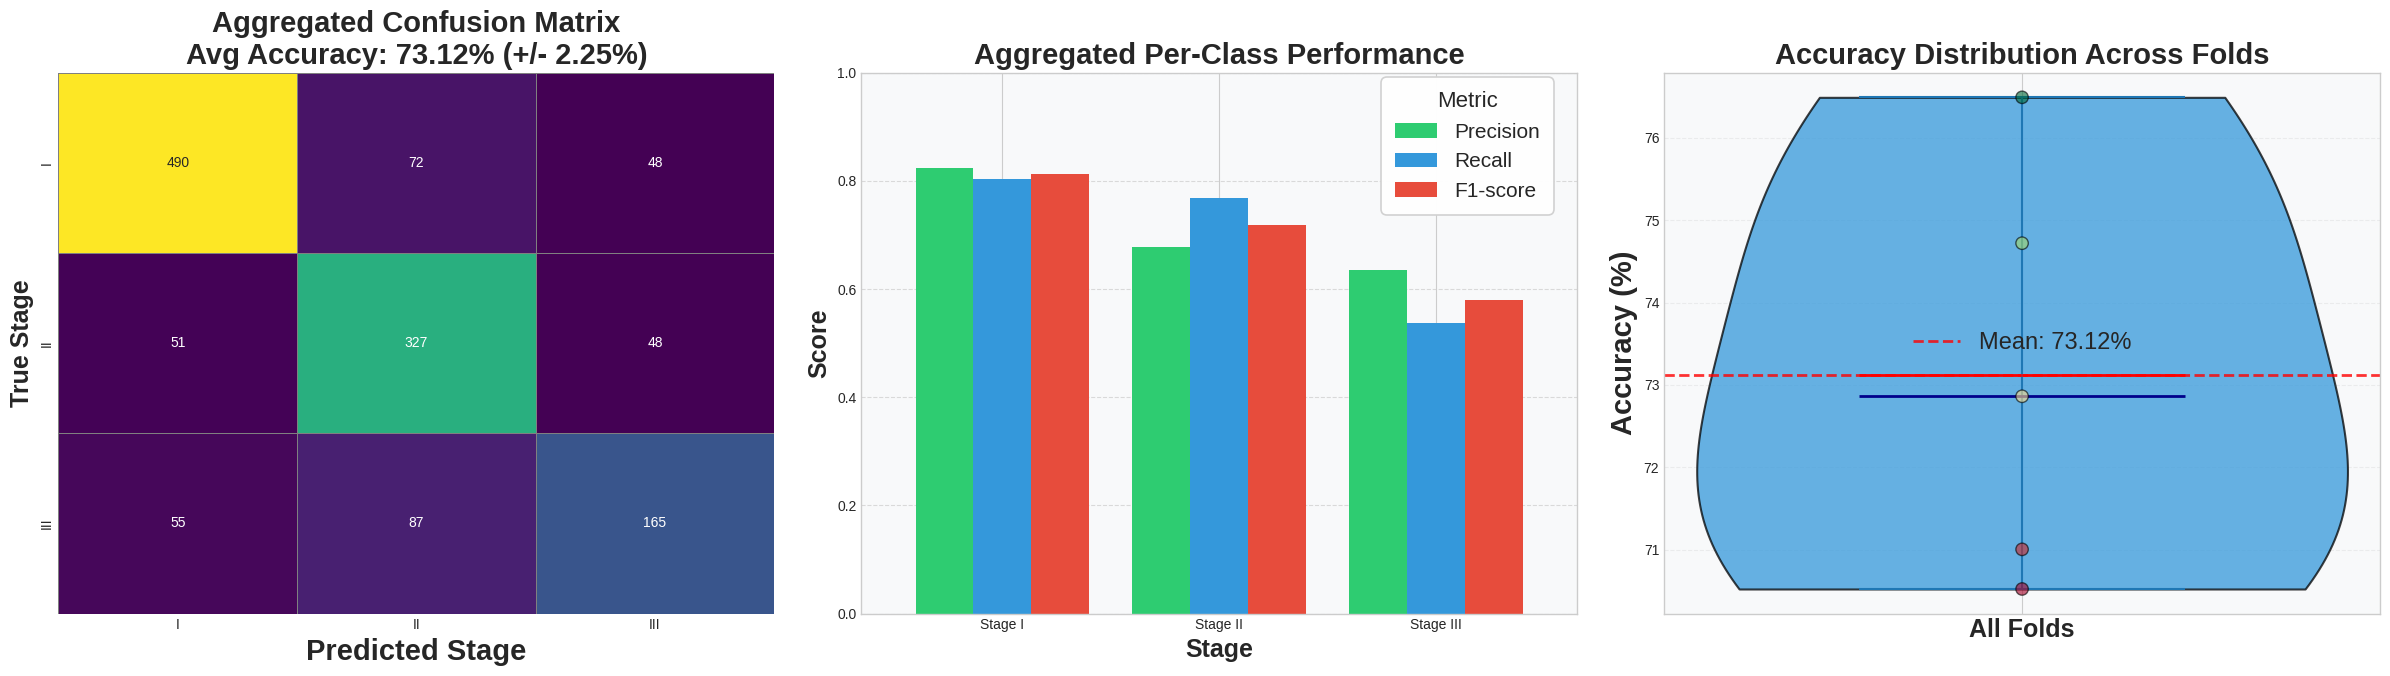

Cross-validation results visualizations complete!
Dashboard saved to: /content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Cross_Validation/Cross_Validation_Dashboard.png


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

save_cv_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Cross_Validation/'

os.makedirs(save_cv_dir, exist_ok=True)

stage_names = ['Stage I', 'Stage II', 'Stage III']
stage_colors = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

#  Plot 1
ax0 = axes[0]
sns.heatmap(sum_confusion_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=['I', 'II', 'III'], yticklabels=['I', 'II', 'III'], ax=ax0,
            linewidths=0.5, linecolor='gray', cbar=False)
ax0.set_xlabel('Predicted Stage', fontsize=21, fontweight='bold')
ax0.set_ylabel('True Stage', fontsize=18, fontweight='bold')
ax0.set_title(f'Aggregated Confusion Matrix\nAvg Accuracy: {mean_accuracy*100:.2f}% (+/- {std_accuracy*100:.2f}%)', fontsize=21, fontweight='bold')

#  Plot 2
metrics_df = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Stage I': [aggregated_report['Stage I']['precision'], aggregated_report['Stage I']['recall'], aggregated_report['Stage I']['f1-score']],
    'Stage II': [aggregated_report['Stage II']['precision'], aggregated_report['Stage II']['recall'], aggregated_report['Stage II']['f1-score']],
    'Stage III': [aggregated_report['Stage III']['precision'], aggregated_report['Stage III']['recall'], aggregated_report['Stage III']['f1-score']]
}).set_index('Metric')

ax1 = axes[1]
metrics_df.T.plot(kind='bar', ax=ax1, width=0.8, color=stage_colors)
ax1.set_title('Aggregated Per-Class Performance', fontsize=21, fontweight='bold')
ax1.set_ylabel('Score', fontsize=18, fontweight='bold')
ax1.set_xlabel('Stage', fontsize=18, fontweight='bold')
ax1.set_ylim(0, 1.0)
leg = ax1.legend(
    title='Metric',
    title_fontsize=16,
    fontsize=15,
    bbox_to_anchor=(0.72, 1),
    loc='upper left',
    frameon=True
)

frame = leg.get_frame()
frame.set_facecolor("white")
frame.set_edgecolor("#d0d0d0")
frame.set_linewidth(1.2)
frame.set_boxstyle("round,pad=0.3")
frame.set_alpha(0.97)
ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_facecolor('#f8f9fa')

#  Plot 3
ax2 = axes[2]
accuracies_percent = np.array(fold_accuracies) * 100
parts = ax2.violinplot([accuracies_percent], positions=[1], widths=0.7, showmeans=True, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('#3498db')
    pc.set_alpha(0.75)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)
parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('darkblue')
parts['cmedians'].set_linewidth(2)

ax2.scatter([1]*len(accuracies_percent), accuracies_percent, alpha=0.6, s=80,
           c=accuracies_percent, cmap='RdYlGn', edgecolors='black', linewidth=1, zorder=3)
ax2.axhline(mean_accuracy * 100, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'Mean: {mean_accuracy*100:.2f}%')
ax2.set_ylabel('Accuracy (%)', fontsize=21, fontweight='bold')
ax2.set_title('Accuracy Distribution Across Folds', fontsize=21, fontweight='bold')
ax2.set_xticks([1])
ax2.set_xticklabels(['All Folds'], fontsize=18, fontweight='bold')
ax2.legend(fontsize=17)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_facecolor('#f8f9fa')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'{save_cv_dir}Cross_Validation_Dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_cv_dir}Cross_Validation_Dashboard.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("Cross-validation results visualizations complete!")
print(f"Dashboard saved to: {save_cv_dir}Cross_Validation_Dashboard.png")

# **Baseline Models**


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

print("\n[STEP 4] Initializing models, scaler, and results dictionary...")

baseline_results = {}

# Combine contrastive and clinical features for baseline models
X_train_combined = np.hstack([X_cont_train, X_clin_train])
X_val_combined = np.hstack([X_cont_val, X_clin_val])
X_test_combined = np.hstack([X_cont_test, X_clin_test])

scaler_baseline = StandardScaler()
X_train_combined_scaled = scaler_baseline.fit_transform(X_train_combined)
X_val_combined_scaled = scaler_baseline.transform(X_val_combined)
X_test_combined_scaled = scaler_baseline.transform(X_test_combined)

print(f"   X_train_combined_scaled shape: {X_train_combined_scaled.shape}")
print(f"   X_val_combined_scaled shape: {X_val_combined_scaled.shape}")
print(f"   X_test_combined_scaled shape: {X_test_combined_scaled.shape}")


[STEP 4] Initializing models, scaler, and results dictionary...
   X_train_combined_scaled shape: (1075, 141)
   X_val_combined_scaled shape: (201, 141)
   X_test_combined_scaled shape: (268, 141)


In [36]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split # Needed for split

# Re-establish consistent data splits and scaled features for baseline evaluation
# This assumes X_contrastive, X_clinical, y are globally available and correct from earlier cells

# 1. Perform the intended 70/15/15 split
X_cont_train_local, X_temp_local, X_clin_train_local, X_clin_temp_local, y_train_local, y_temp_local = train_test_split(
    X_contrastive, X_clinical, y, # Use X_clinical, it will be scaled below
    test_size=0.30, random_state=42, stratify=y
)
X_cont_val_local, X_cont_test_local, X_clin_val_local, X_clin_test_local, y_val_local, y_test_local = train_test_split(
    X_temp_local, X_clin_temp_local, y_temp_local,
    test_size=0.50, random_state=42, stratify=y_temp_local
)

# 2. Scale clinical features for the split subsets
scaler_clinical_local = StandardScaler()
X_clin_train_scaled_local = scaler_clinical_local.fit_transform(X_clin_train_local)
X_clin_val_scaled_local = scaler_clinical_local.transform(X_clin_val_local)
X_clin_test_scaled_local = scaler_clinical_local.transform(X_clin_test_local)

# 3. Combine contrastive and scaled clinical features
X_train_combined_local = np.hstack([X_cont_train_local, X_clin_train_scaled_local])
X_val_combined_local = np.hstack([X_cont_val_local, X_clin_val_scaled_local])
X_test_combined_local = np.hstack([X_cont_test_local, X_clin_test_scaled_local])

# 4. Scale the combined features (this is X_train_combined_scaled, etc. that were used)
scaler_baseline_local = StandardScaler()
X_train_combined_scaled = scaler_baseline_local.fit_transform(X_train_combined_local)
X_val_combined_scaled = scaler_baseline_local.transform(X_val_combined_local)
X_test_combined_scaled = scaler_baseline_local.transform(X_test_combined_local)

# 5. Assign the consistent y_train and y_test variables
y_train = y_train_local
y_test = y_test_local

print("\n[STEP 5] Training and evaluating baseline models")

target_names = ['Stage I', 'Stage II', 'Stage III']

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors Classifier': KNeighborsClassifier(n_neighbors=5)
}

baseline_results = {} # Ensure baseline_results is initialized

for name, model in models.items():
    print(f"\n Training and evaluating {name}")
    model.fit(X_train_combined_scaled, y_train)
    y_pred = model.predict(X_test_combined_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    baseline_results[name] = {
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': cm
    }
    print(f"   {name} - Accuracy: {accuracy*100:.2f}%")
    print(f"   Confusion Matrix:\n{cm}")
    print(f"   Detailed Classification Report:")
    for stage in target_names:
        print(f"     {stage}:")
        print(f"       Precision: {report[stage]['precision']:.4f}")
        print(f"       Recall: {report[stage]['recall']:.4f}")
        print(f"       F1-score: {report[stage]['f1-score']:.4f}")

print("\n[STEP 6] All baseline models evaluated.")


[STEP 5] Training and evaluating baseline models

 Training and evaluating Logistic Regression
   Logistic Regression - Accuracy: 72.28%
   Confusion Matrix:
[[77  7  8]
 [ 6 45 13]
 [12 10 24]]
   Detailed Classification Report:
     Stage I:
       Precision: 0.8105
       Recall: 0.8370
       F1-score: 0.8235
     Stage II:
       Precision: 0.7258
       Recall: 0.7031
       F1-score: 0.7143
     Stage III:
       Precision: 0.5333
       Recall: 0.5217
       F1-score: 0.5275

 Training and evaluating SVM
   SVM - Accuracy: 73.76%
   Confusion Matrix:
[[77  7  8]
 [ 3 46 15]
 [ 5 15 26]]
   Detailed Classification Report:
     Stage I:
       Precision: 0.9059
       Recall: 0.8370
       F1-score: 0.8701
     Stage II:
       Precision: 0.6765
       Recall: 0.7188
       F1-score: 0.6970
     Stage III:
       Precision: 0.5306
       Recall: 0.5652
       F1-score: 0.5474

 Training and evaluating Random Forest Classifier
   Random Forest Classifier - Accuracy: 72.77%
   Con

# **Nair-style Multimodal Neural Network Baseline & DBN-ELM-BP-inspired Deep Baseline**

In [37]:
# ============================================================
# PAPER-BASED DEEP BASELINES FOR DRIFTNET COMPARISON
# Add this cell AFTER your regular baseline models cell
# and BEFORE your visualization/comparison cells.
#
# Models:
# 1. Nair-style Multimodal Neural Network Baseline
# 2. DBN-ELM-BP-inspired Deep Baseline
#
# These models are used as architecture-comparison baselines.
# They use the SAME train/validation/test split as your current baseline models.
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import compute_class_weight

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Safety checks
# -----------------------------
required_vars = [
    "X_cont_train", "X_cont_val", "X_cont_test",
    "X_clin_train", "X_clin_val", "X_clin_test",
    "X_train_combined_scaled", "X_val_combined_scaled", "X_test_combined_scaled",
    "y_train", "y_val", "y_test",
    "baseline_results"
]

missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise ValueError(
        f"Missing required variables: {missing_vars}\n"
        "Run your data split cells and regular baseline initialization cells first."
    )

target_names = ["Stage I", "Stage II", "Stage III"]
num_classes = len(np.unique(y_train))

# -----------------------------
# Class weights
# -----------------------------
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

print("\nClass weights for deep baselines:")
print(class_weights)

# -----------------------------
# Common callbacks
# -----------------------------
def get_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=20,
            restore_best_weights=True,
            mode="max",
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]

# -----------------------------
# Common evaluation function
# -----------------------------
def evaluate_and_store_baseline(model_name, y_true, y_prob):
    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    baseline_results[model_name] = {
        "accuracy": accuracy,
        "report": report,
        "confusion_matrix": cm
    }

    print("\n" + "=" * 80)
    print(f"{model_name} Results")
    print("=" * 80)
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nDetailed Classification Report:")
    for stage in target_names:
        print(f"  {stage}:")
        print(f"    Precision: {report[stage]['precision']:.4f}")
        print(f"    Recall:    {report[stage]['recall']:.4f}")
        print(f"    F1-score:  {report[stage]['f1-score']:.4f}")

    return y_pred, accuracy, report, cm


# ============================================================
# MODEL 1: NAIR-STYLE MULTIMODAL NEURAL NETWORK BASELINE
# ============================================================
# Idea:
# - This is a simple multimodal neural-fusion baseline.
# - It uses two branches:
#   1. methylation/contrastive branch
#   2. clinical branch
# - Then concatenates both branches and predicts Stage I/II/III.
#
# Difference from DriftNet:
# - No focal loss.
# - No special DriftNet fusion head.
# - No additional contrastive optimization inside this classifier.
# - It tests whether standard multimodal neural fusion is enough.
# ============================================================

def build_nair_multimodal_nn(methylation_dim, clinical_dim, num_classes=3):
    # Methylation / molecular branch
    methylation_input = keras.Input(
        shape=(methylation_dim,),
        name="nair_molecular_input"
    )

    m = layers.Dense(256, activation="relu", name="nair_molecular_dense_1")(methylation_input)
    m = layers.BatchNormalization(name="nair_molecular_bn_1")(m)
    m = layers.Dropout(0.30, name="nair_molecular_dropout_1")(m)

    m = layers.Dense(128, activation="relu", name="nair_molecular_dense_2")(m)
    m = layers.BatchNormalization(name="nair_molecular_bn_2")(m)
    m = layers.Dropout(0.25, name="nair_molecular_dropout_2")(m)

    m = layers.Dense(64, activation="relu", name="nair_molecular_embedding")(m)

    # Clinical branch
    clinical_input = keras.Input(
        shape=(clinical_dim,),
        name="nair_clinical_input"
    )

    c = layers.Dense(64, activation="relu", name="nair_clinical_dense_1")(clinical_input)
    c = layers.BatchNormalization(name="nair_clinical_bn_1")(c)
    c = layers.Dropout(0.20, name="nair_clinical_dropout_1")(c)

    c = layers.Dense(32, activation="relu", name="nair_clinical_embedding")(c)

    # Fusion
    fusion = layers.Concatenate(name="nair_multimodal_fusion")([m, c])

    x = layers.Dense(128, activation="relu", name="nair_fusion_dense_1")(fusion)
    x = layers.BatchNormalization(name="nair_fusion_bn_1")(x)
    x = layers.Dropout(0.30, name="nair_fusion_dropout_1")(x)

    x = layers.Dense(64, activation="relu", name="nair_fusion_dense_2")(x)
    x = layers.Dropout(0.20, name="nair_fusion_dropout_2")(x)

    output = layers.Dense(
        num_classes,
        activation="softmax",
        name="nair_stage_output"
    )(x)

    model = keras.Model(
        inputs=[methylation_input, clinical_input],
        outputs=output,
        name="Nair_Style_Multimodal_NN_Baseline"
    )

    return model


print("\n" + "#" * 80)
print("Training Paper-Based Baseline 1: Nair-style Multimodal Neural Network")
print("#" * 80)

nair_model = build_nair_multimodal_nn(
    methylation_dim=X_cont_train.shape[1],
    clinical_dim=X_clin_train.shape[1],
    num_classes=num_classes
)

nair_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(nair_model.summary())

nair_history = nair_model.fit(
    [X_cont_train, X_clin_train],
    y_train,
    validation_data=([X_cont_val, X_clin_val], y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=get_callbacks("Nair-style Multimodal NN"),
    verbose=1
)

nair_y_prob = nair_model.predict(
    [X_cont_test, X_clin_test],
    verbose=0
)

nair_y_pred, nair_acc, nair_report, nair_cm = evaluate_and_store_baseline(
    "Nair-style Multimodal NN",
    y_test,
    nair_y_prob
)


# ============================================================
# MODEL 2: DBN-ELM-BP-INSPIRED DEEP BASELINE
# ============================================================
# Idea:
# - Original DBN-ELM-BP combines:
#   1. DBN-style deep feature learning
#   2. ELM-style hidden classifier layer
#   3. BP-based fine-tuning
#
# Practical implementation:
# - A DBN-like deep dense feature extractor is used.
# - An ELM-like wide hidden layer is added before output.
# - The full model is trained using backpropagation.
#
# Difference from DriftNet:
# - Uses one combined input vector.
# - No two-branch methylation/clinical fusion.
# - No focal loss.
# - No triplet/contrastive classifier stage.
# ============================================================

def build_dbn_elm_bp_baseline(input_dim, num_classes=3):
    combined_input = keras.Input(
        shape=(input_dim,),
        name="dbn_elm_bp_combined_input"
    )

    # DBN-like stacked representation block
    x = layers.Dense(256, activation="relu", name="dbn_hidden_layer_1")(combined_input)
    x = layers.BatchNormalization(name="dbn_bn_1")(x)
    x = layers.Dropout(0.30, name="dbn_dropout_1")(x)

    x = layers.Dense(128, activation="relu", name="dbn_hidden_layer_2")(x)
    x = layers.BatchNormalization(name="dbn_bn_2")(x)
    x = layers.Dropout(0.25, name="dbn_dropout_2")(x)

    x = layers.Dense(64, activation="relu", name="dbn_deep_feature_layer")(x)
    x = layers.BatchNormalization(name="dbn_feature_bn")(x)

    # ELM-like classifier block
    # In a pure ELM, hidden-layer weights may be fixed/random.
    # Here it is implemented as an ELM-inspired wide hidden layer
    # and fine-tuned by BP for fair Keras training.
    x = layers.Dense(256, activation="relu", name="elm_like_hidden_layer")(x)
    x = layers.Dropout(0.20, name="elm_like_dropout")(x)

    # BP fine-tuned output layer
    output = layers.Dense(
        num_classes,
        activation="softmax",
        name="dbn_elm_bp_stage_output"
    )(x)

    model = keras.Model(
        inputs=combined_input,
        outputs=output,
        name="DBN_ELM_BP_Inspired_Baseline"
    )

    return model


print("\n" + "#" * 80)
print("Training Paper-Based Baseline 2: DBN-ELM-BP-inspired Deep Baseline")
print("#" * 80)

dbn_elm_bp_model = build_dbn_elm_bp_baseline(
    input_dim=X_train_combined_scaled.shape[1],
    num_classes=num_classes
)

dbn_elm_bp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(dbn_elm_bp_model.summary())

dbn_elm_bp_history = dbn_elm_bp_model.fit(
    X_train_combined_scaled,
    y_train,
    validation_data=(X_val_combined_scaled, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=get_callbacks("DBN-ELM-BP-inspired Baseline"),
    verbose=1
)

dbn_elm_bp_y_prob = dbn_elm_bp_model.predict(
    X_test_combined_scaled,
    verbose=0
)

dbn_elm_bp_y_pred, dbn_elm_bp_acc, dbn_elm_bp_report, dbn_elm_bp_cm = evaluate_and_store_baseline(
    "DBN-ELM-BP-inspired Deep Baseline",
    y_test,
    dbn_elm_bp_y_prob
)


# ============================================================
# SAVE DEEP BASELINE MODELS AND RESULTS
# ============================================================

save_deep_baseline_dir = "/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Paper_Based_Deep_Baselines/"
os.makedirs(save_deep_baseline_dir, exist_ok=True)

nair_model.save(os.path.join(save_deep_baseline_dir, "nair_style_multimodal_nn.keras"))
dbn_elm_bp_model.save(os.path.join(save_deep_baseline_dir, "dbn_elm_bp_inspired_baseline.keras"))

deep_baseline_summary = pd.DataFrame([
    {
        "Model": "Nair-style Multimodal NN",
        "Accuracy": nair_acc,
        "Stage I Precision": nair_report["Stage I"]["precision"],
        "Stage I Recall": nair_report["Stage I"]["recall"],
        "Stage I F1": nair_report["Stage I"]["f1-score"],
        "Stage II Precision": nair_report["Stage II"]["precision"],
        "Stage II Recall": nair_report["Stage II"]["recall"],
        "Stage II F1": nair_report["Stage II"]["f1-score"],
        "Stage III Precision": nair_report["Stage III"]["precision"],
        "Stage III Recall": nair_report["Stage III"]["recall"],
        "Stage III F1": nair_report["Stage III"]["f1-score"],
        "Macro F1": nair_report["macro avg"]["f1-score"],
        "Weighted F1": nair_report["weighted avg"]["f1-score"]
    },
    {
        "Model": "DBN-ELM-BP-inspired Deep Baseline",
        "Accuracy": dbn_elm_bp_acc,
        "Stage I Precision": dbn_elm_bp_report["Stage I"]["precision"],
        "Stage I Recall": dbn_elm_bp_report["Stage I"]["recall"],
        "Stage I F1": dbn_elm_bp_report["Stage I"]["f1-score"],
        "Stage II Precision": dbn_elm_bp_report["Stage II"]["precision"],
        "Stage II Recall": dbn_elm_bp_report["Stage II"]["recall"],
        "Stage II F1": dbn_elm_bp_report["Stage II"]["f1-score"],
        "Stage III Precision": dbn_elm_bp_report["Stage III"]["precision"],
        "Stage III Recall": dbn_elm_bp_report["Stage III"]["recall"],
        "Stage III F1": dbn_elm_bp_report["Stage III"]["f1-score"],
        "Macro F1": dbn_elm_bp_report["macro avg"]["f1-score"],
        "Weighted F1": dbn_elm_bp_report["weighted avg"]["f1-score"]
    }
])

deep_baseline_summary.to_csv(
    os.path.join(save_deep_baseline_dir, "paper_based_deep_baseline_results.csv"),
    index=False
)

print("\n" + "=" * 80)
print("Paper-based deep baseline models completed and added to baseline_results.")
print("=" * 80)
print(deep_baseline_summary)

print(f"\nSaved models and CSV to: {save_deep_baseline_dir}")
print("\nNow run your existing Cell 48, Cell 49, Cell 50, and Cell 51.")
print("These new models will be included automatically because they were added to baseline_results.")


Class weights for deep baselines:
{0: 0.7338017174082748, 1: 1.051454138702461, 2: 1.4573643410852712}

################################################################################
Training Paper-Based Baseline 1: Nair-style Multimodal Neural Network
################################################################################


Model: "Nair_Style_Multimodal_NN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nair_molecular_inp… │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_den… │ (None, 256)       │     33,024 │ nair_molecular_i… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_bn_1 │ (None, 256)       │      1,024 │ nair_molecular_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_dro… │ (None, 256)       │          0 │ nair_molecular_b… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_clinical_input │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_den… │ (None, 128)       │     32,896 │ nair_molecular_d… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_clinical_dens… │ (None, 64)        │        896 │ nair_clinical_in… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_bn_2 │ (None, 128)       │        512 │ nair_molecular_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_clinical_bn_1  │ (None, 64)        │        256 │ nair_clinical_de… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_dro… │ (None, 128)       │          0 │ nair_molecular_b… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_clinical_drop… │ (None, 64)        │          0 │ nair_clinical_bn… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_molecular_emb… │ (None, 64)        │      8,256 │ nair_molecular_d… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_clinical_embe… │ (None, 32)        │      2,080 │ nair_clinical_dr… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_multimodal_fu… │ (None, 96)        │          0 │ nair_molecular_e… │
│ (Concatenate)       │                   │            │ nair_clinical_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_fusion_dense_1 │ (None, 128)       │     12,416 │ nair_multimodal_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_fusion_bn_1    │ (None, 128)       │        512 │ nair_fusion_dens… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nair_fusion_dropou… │ (None, 128)       │          0 │ nair_fusion_bn_1

 Total params: 100,323 (391.89 KB)

 Trainable params: 99,171 (387.39 KB)

 Non-trainable params: 1,152 (4.50 KB)

None


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 1075, 1075
'y' sizes: 940
'sample_weight' sizes: 940


In [ ]:
# ============================================================
# CHECK AND PRINT ALL MODEL ACCURACIES IN TERMINAL
# Run this AFTER baseline_results and DriftNet predictions are loaded
# ============================================================

import os
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

save_baseline_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Baseline_Models/'
os.makedirs(save_baseline_dir, exist_ok=True)

print("\n" + "="*90)
print("ALL MODEL ACCURACY SUMMARY")
print("="*90)

accuracy_rows = []

# -----------------------------
# 1. Baseline model accuracies
# -----------------------------
for model_name, result in baseline_results.items():

    # Accuracy may already exist in your baseline_results
    if "accuracy" in result:
        acc = result["accuracy"]
    elif "report" in result and "accuracy" in result["report"]:
        acc = result["report"]["accuracy"]
    else:
        acc = None

    # Macro and weighted F1
    macro_f1 = result["report"]["macro avg"]["f1-score"]
    weighted_f1 = result["report"]["weighted avg"]["f1-score"]

    accuracy_rows.append({
        "Model": model_name,
        "Accuracy": acc,
        "Accuracy (%)": acc * 100 if acc is not None else None,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    })

# -----------------------------
# 2. DriftNet accuracy
# -----------------------------
driftnet_random_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/'

best_pred_df_60_20_20 = pd.read_csv(f'{driftnet_random_dir}predictions.csv')
driftnet_y_test_60_20_20 = best_pred_df_60_20_20['True'].values
driftnet_best_pred_60_20_20 = best_pred_df_60_20_20['Predicted'].values

driftnet_acc_from_predictions = accuracy_score(
    driftnet_y_test_60_20_20,
    driftnet_best_pred_60_20_20
)

driftnet_report_full = classification_report(
    driftnet_y_test_60_20_20,
    driftnet_best_pred_60_20_20,
    target_names=['Stage I', 'Stage II', 'Stage III'],
    output_dict=True,
    zero_division=0
)

accuracy_rows.append({
    "Model": "DriftNet",
    "Accuracy": driftnet_acc_from_predictions,
    "Accuracy (%)": driftnet_acc_from_predictions * 100,
    "Macro F1": driftnet_report_full["macro avg"]["f1-score"],
    "Weighted F1": driftnet_report_full["weighted avg"]["f1-score"]
})

# -----------------------------
# 3. Create summary table
# -----------------------------
accuracy_df = pd.DataFrame(accuracy_rows)

# Sort by accuracy high to low
accuracy_df = accuracy_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

# Format for terminal display
display_df = accuracy_df.copy()
display_df["Accuracy (%)"] = display_df["Accuracy (%)"].map(lambda x: f"{x:.2f}%" if pd.notnull(x) else "N/A")
display_df["Macro F1"] = display_df["Macro F1"].map(lambda x: f"{x:.4f}")
display_df["Weighted F1"] = display_df["Weighted F1"].map(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))

# -----------------------------
# 4. Print best model
# -----------------------------
best_model = accuracy_df.iloc[0]

print("\n" + "-"*90)
print(f"Best Model: {best_model['Model']}")
print(f"Best Accuracy: {best_model['Accuracy (%)']:.2f}%")
print(f"Macro F1: {best_model['Macro F1']:.4f}")
print(f"Weighted F1: {best_model['Weighted F1']:.4f}")
print("-"*90)

# -----------------------------
# 5. Save CSV
# -----------------------------
accuracy_df.to_csv(
    f"{save_baseline_dir}All_Model_Accuracy_Summary.csv",
    index=False
)

print(f"\nAccuracy summary saved to:")
print(f"{save_baseline_dir}All_Model_Accuracy_Summary.csv")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

save_baseline_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Baseline_Models/'
os.makedirs(save_baseline_dir, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

print("\n[STEP 11] Generating combined Precision, Recall, F1-score comparison figure...")

target_names = ['Stage I', 'Stage II', 'Stage III']

driftnet_random_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/'
best_pred_df_60_20_20 = pd.read_csv(f'{driftnet_random_dir}predictions.csv')
driftnet_y_test_60_20_20 = best_pred_df_60_20_20['True'].values
driftnet_best_pred_60_20_20 = best_pred_df_60_20_20['Predicted'].values

driftnet_all_results_60_20_20_df = pd.read_csv(f'{driftnet_random_dir}auto_seeds_results.csv')
driftnet_best_accuracy_60_20_20 = driftnet_all_results_60_20_20_df['accuracy'].max()

driftnet_report_full = classification_report(driftnet_y_test_60_20_20, driftnet_best_pred_60_20_20, target_names=target_names, output_dict=True)

all_model_metrics = []

for name, result in baseline_results.items():
    for stage in target_names:
        all_model_metrics.append({
            'Model': name,
            'Stage': stage,
            'Metric': 'Precision',
            'Score': result['report'][stage]['precision']
        })
        all_model_metrics.append({
            'Model': name,
            'Stage': stage,
            'Metric': 'Recall',
            'Score': result['report'][stage]['recall']
        })
        all_model_metrics.append({
            'Model': name,
            'Stage': stage,
            'Metric': 'F1-score',
            'Score': result['report'][stage]['f1-score']
        })


for stage in target_names:
    all_model_metrics.append({
        'Model': 'DriftNet',
        'Stage': stage,
        'Metric': 'Precision',
        'Score': driftnet_report_full[stage]['precision']
    })
    all_model_metrics.append({
        'Model': 'DriftNet',
        'Stage': stage,
        'Metric': 'Recall',
        'Score': driftnet_report_full[stage]['recall']
    })
    all_model_metrics.append({
        'Model': 'DriftNet',
        'Stage': stage,
        'Metric': 'F1-score',
        'Score': driftnet_report_full[stage]['f1-score']
    })

df_long = pd.DataFrame(all_model_metrics)

model_order = [model for model in df_long['Model'].unique() if model != 'DriftNet']
model_order.insert(0, 'DriftNet')

num_models_to_plot = len(model_order)
num_cols = 3
num_rows = (num_models_to_plot + num_cols - 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(22, num_rows * 7), sharey=True, gridspec_kw={'hspace': 0.6, 'wspace': 0.3})
axes = axes.flatten()

metric_colors = {'Precision': '#1f77b4', 'Recall': '#ff7f0e', 'F1-score': '#2ca02c'}

for i, model_name in enumerate(model_order):
    ax = axes[i]
    model_data = df_long[df_long['Model'] == model_name]

    sns.barplot(x='Stage', y='Score', hue='Metric', data=model_data,
                palette=metric_colors, ax=ax, edgecolor='black', linewidth=0.8)

    ax.set_title(model_name, fontsize=16, fontweight='bold')
    ax.set_xlabel('Cancer Stage', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=0, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    if model_name == 'DriftNet':
        for patch in ax.patches:
            patch.set_edgecolor('gold')
            patch.set_linewidth(2.5)

    if i != 0:
        ax.legend().set_visible(False)
    else:
        ax.legend(title='Metric', bbox_to_anchor=(1.00, 1), loc='upper left', frameon=True, shadow=True, fancybox=True, fontsize=12, title_fontsize=13)

    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_facecolor('#f8f9fa')

for j in range(num_models_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('DriftNet vs. Baseline Models: Per-Class Performance Comparison', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig(f'{save_baseline_dir}Per_Class_Metrics_Comparison_Dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_baseline_dir}Per_Class_Metrics_Comparison_Dashboard.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n   Per-Class Metrics Comparison Dashboard saved and displayed.")
print(f"   Saved to: {save_baseline_dir}Per_Class_Metrics_Comparison_Dashboard.png")

print("All comparison visualizations complete!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np

print("\n[STEP 7] Aggregating baseline results and preparing for comparison")

save_baseline_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Baseline_Models/'
os.makedirs(save_baseline_dir, exist_ok=True)

driftnet_results_path = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/DriftNet/Random/auto_seeds_results.csv'
driftnet_accuracies_df = pd.read_csv(driftnet_results_path)
best_acc = driftnet_accuracies_df['accuracy'].max()

driftnet_best_accuracy = best_acc

model_names = []
accuracies = []
for name, result in baseline_results.items():
    if 'DriftNet' not in name:
        model_names.append(name)
        accuracies.append(result['accuracy'])

model_names.append('DriftNet')
accuracies.append(best_acc)
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
}).sort_values(by='Accuracy', ascending=False)

print("\n Comparison Table (Accuracy)")
print(comparison_df.to_string(index=False))

aggregated_baseline_reports = {}
for metric_name in ['precision', 'recall', 'f1-score']:
    aggregated_baseline_reports[metric_name] = {
        stage: np.mean([baseline_results[model_name]['report'][stage][metric_name] for model_name in baseline_results.keys() if 'DriftNet' not in model_name])
        for stage in target_names
    }

print("\n[STEP 8] All baseline results aggregated.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

save_baseline_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Baseline_Models/'
os.makedirs(save_baseline_dir, exist_ok=True)

overall_accuracy_data = {'Model': [], 'Accuracy': []}

for name, result in baseline_results.items():
    overall_accuracy_data['Model'].append(name)
    overall_accuracy_data['Accuracy'].append(result['accuracy'])

overall_accuracy_data['Model'].append('DriftNet')
overall_accuracy_data['Accuracy'].append(best_acc)

overall_accuracy_df = (
    pd.DataFrame(overall_accuracy_data)
    .sort_values(by='Accuracy', ascending=False)
    .reset_index(drop=True)
)

base_models = [m for m in overall_accuracy_df['Model'] if m != 'DriftNet']
palette_base = sns.color_palette("Blues_r", len(base_models)).as_hex()

colors = []
for model in overall_accuracy_df['Model']:
    if model == "DriftNet":
        colors.append("#FFD700")
    else:
        colors.append(palette_base.pop(0))

fig, ax = plt.subplots(figsize=(16, 10))

sns.barplot(
    x='Accuracy',
    y='Model',
    hue='Model',
    data=overall_accuracy_df,
    palette=colors,
    ax=ax,
    edgecolor='black',
    linewidth=1.5,
    legend=False
)

ax.set_title('Overall Test Accuracy: DriftNet vs. Baseline Models',
             fontsize=26, fontweight='bold', pad=25)

ax.set_xlabel('Accuracy', fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel('Model', fontsize=18, fontweight='bold', labelpad=10)

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=16)

min_acc = overall_accuracy_df['Accuracy'].min()
max_acc = overall_accuracy_df['Accuracy'].max()
margin = (max_acc - min_acc) * 0.25
ax.set_xlim(min_acc - 0.02, max_acc + margin)

for index, row in overall_accuracy_df.iterrows():
    ax.text(
        row.Accuracy + (margin * 0.10),
        index,
        f'{row.Accuracy:.3f}',
        color='black',
        ha='left',
        va='center',
        fontsize=14,
        fontweight='bold'
    )

ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.set_facecolor('#f6f7f8')
sns.despine(left=True, bottom=True)

plt.tight_layout()

plt.savefig(
    f'{save_baseline_dir}Overall_Accuracy_Comparison_Premium.png',
    dpi=400, bbox_inches='tight', facecolor='white'
)
plt.savefig(
    f'{save_baseline_dir}Overall_Accuracy_Comparison_Premium.pdf',
    dpi=400, bbox_inches='tight', facecolor='white'
)

plt.show()

print("\nPremium Accuracy Comparison figure saved.")
print(f"Saved to: {save_baseline_dir}Overall_Accuracy_Comparison_Premium.png")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

save_baseline_dir = '/content/drive/MyDrive/GDC TCGA DATASET/final/processed_data/DriftNet_Classification/Baseline_Models/'
os.makedirs(save_baseline_dir, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-whitegrid')

target_names = ['Stage I', 'Stage II', 'Stage III']

all_models = {
    **baseline_results,
    'DriftNet': {
        'accuracy': best_acc,
        'confusion_matrix': confusion_matrix(y_test, best_pred)
    }
}

num_models = len(all_models)
num_cols = 3
num_rows = (num_models + num_cols - 1) // num_cols

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 7, num_rows * 6), squeeze=False)
axes = axes.flatten()

for i, (name, data) in enumerate(all_models.items()):
    ax = axes[i]
    cm = data['confusion_matrix']
    accuracy = data['accuracy']
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=target_names, yticklabels=target_names, ax=ax,
                linewidths=0.8, linecolor='white', cbar=False, annot_kws={'size': 12, 'weight': 'bold'})

    ax.set_title(f'{name}\nAccuracy: {accuracy*100:.2f}%', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Stage', fontsize=11)
    ax.set_ylabel('True Stage', fontsize=11)
    ax.tick_params(axis='x', labelsize=9, rotation=45)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

    if name == 'DriftNet':
        for spine in ax.spines.values():
            spine.set_edgecolor('gold')
            spine.set_linewidth(3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Confusion Matrices: DriftNet vs. Baseline Models', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'{save_baseline_dir}Confusion_Matrices_Dashboard_Enhanced.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{save_baseline_dir}Confusion_Matrices_Dashboard_Enhanced.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nEnhanced Confusion Matrices Dashboard saved and displayed.")
print(f"Saved to: {save_baseline_dir}Confusion_Matrices_Dashboard_Enhanced.png")